# Module Investigation
for phase 1 oysters 

Interested to know if there are a subset of genes that drive the relationship we see between modules and factors. Here, I'm going to pull genes within a significantly correlated module and look into their individual GE.

## 0. load libraries

In [2]:
library(tidyverse)

library(pheatmap)
library(RColorBrewer)

# for gene ontology
library(rtracklayer)
library(clusterProfiler)
library(GO.db)

# for adding plots together 
library(cowplot)

## 1. read csvs

### module genes
generated in [WGCNA](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/wgcna/newRef_wgcna_p1.ipynb) for phase 1 oysters

In [3]:
geneInfo <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p1.wgcna_GeneInfo.csv')
head(geneInfo)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,0.39966747,0.282186775,0.06994163,0.1492213,0.385003047,-0.02872849,0.12634487,⋯,0.3336787,0.09526861,-0.03750345,-0.01178295,-0.04856269,0.115416013,-0.46324802,-0.19648759,0.05033161,-0.04085780
2,LOC111099037,GO:0000978;GO:0000981;GO:0006355,black,-0.02461599,0.002751307,-0.03894892,-0.4217885,-0.363072643,-0.28138410,-0.24659525,⋯,-0.2452065,-0.14257739,-0.16774119,0.34293007,0.31439017,-0.065239565,0.07719106,-0.15380042,0.22565913,0.02356195
3,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.44340350,0.303838275,-0.01706141,-0.2141764,0.221972568,-0.34604876,-0.04315846,⋯,0.1248501,0.26055230,0.01693705,0.20241978,0.34095291,0.002859469,-0.37935688,-0.49934818,0.05801009,-0.35374473
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,red,-0.41098524,-0.310348052,-0.04403876,0.3171945,0.004370064,0.34594159,0.31502257,⋯,-0.4530072,-0.51091263,-0.31182848,-0.07876548,0.07063991,0.365824475,0.50638260,0.32368892,0.40288267,0.68022795
5,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,green,-0.35176148,-0.282846525,-0.03894228,-0.0592647,-0.254057873,0.06198487,-0.01882029,⋯,-0.3888532,-0.68292735,-0.49529157,0.14867298,0.47087567,-0.253669949,0.40577513,0.03737518,0.72387889,0.49103455
6,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.43025668,0.181368789,-0.15299170,-0.3250255,0.370840965,-0.54214175,-0.10090793,⋯,0.7387194,0.17197754,0.25907960,0.07602426,-0.20551234,-0.602026100,-0.33485347,-0.05929480,-0.20905792,-0.29068175


### vst
generated in [DESeq analysis](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/filter_deseq_p1.v.p1.ipynb) for phase 1 oysters

In [4]:
vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1_vst.csv')
head(vst)

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,11.217975,11.934767,11.224763,11.385998,11.491494,11.330413,11.619094,11.599610,10.935631,⋯,11.695721,11.157977,11.658281,11.998989,11.369555,11.484610,11.158177,11.698655,11.463655,11.597431
2,LOC144621269,9.238570,14.233747,13.248661,6.734822,7.542979,13.067731,11.252050,11.655097,11.695209,⋯,13.172456,11.238048,8.354464,15.534626,13.113269,11.584691,11.875265,13.441989,6.077703,12.341027
3,LOC111120925,6.162650,6.596958,6.709412,6.097391,6.365111,6.642652,8.868688,8.893482,8.281309,⋯,8.933040,6.529973,8.449891,8.330386,6.304683,8.790027,6.259740,6.294474,5.806396,6.516750
4,LOC144621283,9.891478,10.157309,10.265604,9.957131,10.370479,10.049745,9.730975,10.158138,10.091135,⋯,10.091122,9.802983,9.406153,9.831201,9.297184,10.572628,10.579026,9.655386,10.115723,10.146704
5,LOC144621276,13.540965,13.766144,14.145528,13.224735,13.084951,13.044656,13.810034,13.596797,13.309595,⋯,13.929735,13.686105,12.877924,13.996777,12.961637,13.892552,14.181140,13.333327,13.928741,13.550413
6,LOC111115920,8.717293,8.463000,8.350118,8.954966,9.308119,8.469442,7.913170,8.149178,8.357417,⋯,7.567075,8.159515,8.690883,8.016850,7.795664,8.011123,8.435333,8.088760,8.136625,7.770861


### meta data

In [5]:
growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase1_weights.csv')

# add lead
growth$Tag_num <- sprintf("%02d", growth$Tag_num)

# need to convert sample names to be consistent with my naming convention
growth$Sample <- paste0(substr(growth$Phase_1_treat, 1, 1), growth$Phase_1_rep, '_Nu_', growth$Tag_color, growth$Tag_num)

growth <- growth %>% dplyr::select(Sample, 
                            Phase_1_treat, 
                            Phase_1_temp, 
                            Phase_1_DO, 
                            Actual_tissue_growth_mg, 
                            Actual_shell_growth_mg, 
                            Ratio_tissue_shell_mg)

head(growth)

,Sample,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_Nu_O01,Both,Warm,Hyp,21.92322,42.27678,0.518564091
2,B1_Nu_O02,Both,Warm,Hyp,42.34732,63.65268,0.665287306
3,B1_Nu_O03,Both,Warm,Hyp,27.91340,77.58660,0.359770888
4,B1_Nu_O04,Both,Warm,Hyp,148.21004,157.38996,0.941674043
5,B1_Nu_O05,Both,Warm,Hyp,-40.02418,-19.47582,2.055070339
6,B1_Nu_O06,Both,Warm,Hyp,117.50070,181.29930,0.64810344


In [6]:
# keep only growth for genetics oysters
growth <- growth[growth$Sample %in% colnames(vst), ]

rownames(growth) <- NULL

dim(growth)
head(growth)

[1] 23  7

,Sample,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_Nu_O03,Both,Warm,Hyp,27.91340,77.58660,0.359770888
2,B2_Nu_O12,Both,Warm,Hyp,80.37700,150.42300,0.534339828
3,B4_Nu_O32,Both,Warm,Hyp,105.36056,145.03944,0.726426964
4,B5_Nu_O36,Both,Warm,Hyp,25.22362,32.77638,0.769566987
5,B6_Nu_O47,Both,Warm,Hyp,-12.30496,117.80496,-0.104451969
6,C1_Nu_W01,Cont,Ambient,Norm,136.95688,232.44312,0.589205996


### gene annotations

In [7]:
annot <- as.data.frame(import('/project/pi_sarah_gignouxwolfsohn_uml_edu/Reference_genomes/Cvirginica_genome/new_cvir_genome/GCF_053477285.1_ASM5347728v1_genomic.gtf')) %>%
dplyr::select(gene_id, description) %>%
na.omit()

head(annot)

,gene_id,description
,<chr>,<chr>
1,LOC144621260,protein O-mannosyl-transferase TMTC2-like
29,LOC144621269,uncharacterized LOC144621269
68,LOC111120925,mitochondrial amidoxime-reducing component 1-like
86,Trnae-cuc,transfer RNA glutamic acid (anticodon CUC)
89,Trnae-cuc_1,transfer RNA glutamic acid (anticodon CUC)
92,Trnae-cuc_2,transfer RNA glutamic acid (anticodon CUC)


#### for GO analysis

In [8]:
geneGO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/Reference_genomes/Cvirginica_genome/annotations/newRef_geneGO.csv')
colnames(geneGO)[1] <- 'Gene'
colnames(geneGO)[2] <- 'GO.terms'

# One row for each gene and GO.term
term2gene <- geneGO %>%
  separate_rows(GO.terms, sep = ";") %>% # one row for each GO.term
  filter(!is.na(GO.terms) & GO.terms != "") %>% # remove genes without GO terms
  dplyr::select(term = GO.terms, gene = Gene) # rename columns for GO 

# 

head(term2gene)

term,gene
<chr>,<chr>
GO:0005261,LOC111099029
GO:0005886,LOC111099029
GO:0030001,LOC111099029
GO:0098655,LOC111099029
GO:0004930,LOC111099032
GO:0005886,LOC111099032


this becomes input for `enricher` down below

get term names for GO IDs

In [9]:
# Extract GO term descriptions
go_terms <- unique(term2gene$term)

# Get descriptions from GO.db
term2name <- data.frame(
  term = go_terms,
  name = sapply(go_terms, function(x) {
    tryCatch({
      Term(GOTERM[[x]])
    }, error = function(e) {
      NA_character_
    })
  })
)

# Remove NAs
term2name <- term2name[!is.na(term2name$name), ]

# View
head(term2name)  

,term,name
,<chr>,<chr>
GO:0005261,GO:0005261,monoatomic cation channel activity
GO:0005886,GO:0005886,plasma membrane
GO:0030001,GO:0030001,metal ion transport
GO:0098655,GO:0098655,monoatomic cation transmembrane transport
GO:0004930,GO:0004930,G protein-coupled receptor activity
GO:0007186,GO:0007186,G protein-coupled receptor signaling pathway


## 2. pull vst for sig. modules
for phase 1 oysters, only 3 modules were significantly correlated with factors:
1. red - negatively correlated with tissue growth
2. blue - positively correlated with shell growth and warm treatment
3. black - negatively correlated with temperature 

### red module
negatively correlated with tissue growth

plotting tissue growth

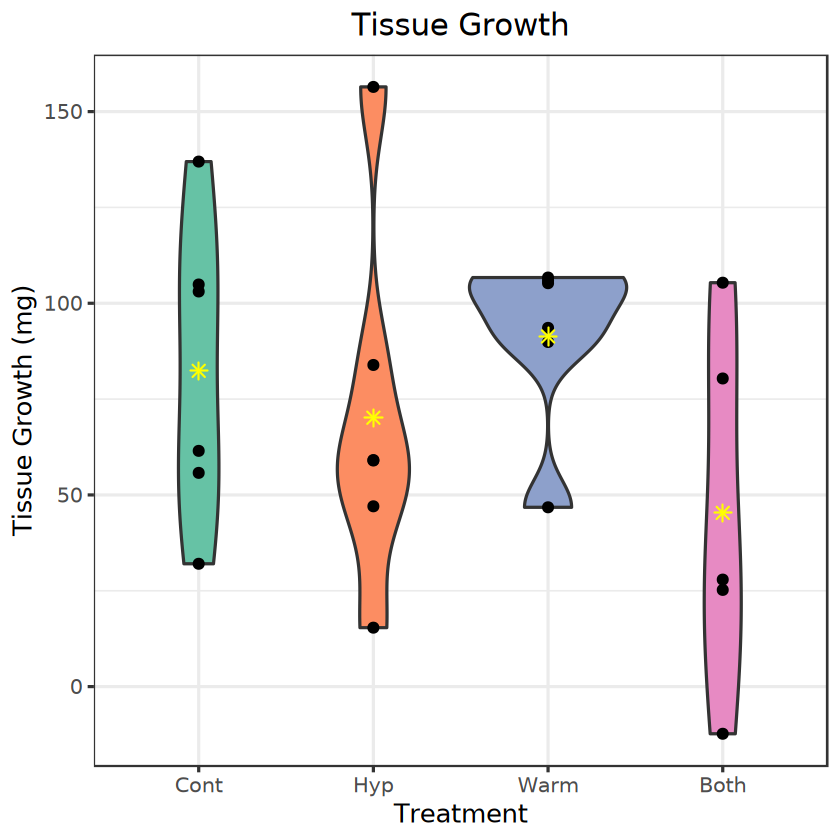

In [13]:
growth$Phase_1_treat <- factor(growth$Phase_1_treat, levels = c('Cont', 'Hyp', 'Warm', 'Both'))

tissue_growth <- ggplot(growth, aes(x = Phase_1_treat, y = Actual_tissue_growth_mg, fill = Phase_1_treat)) +
geom_violin() +
geom_point() +
stat_summary(
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
scale_fill_brewer(palette = 'Set2') +
guides(fill = 'none') +
labs(x = 'Treatment',
     y = 'Tissue Growth (mg)',
    title = 'Tissue Growth') +
theme_bw(base_size = 15) +
theme(plot.title = element_text(hjust = 0.5))

tissue_growth

the black points represent the individual sample values, the yellow asterick represents the mean tissue growth for that treatment 

In [14]:
# pull red genes
red_genes <- geneInfo %>% 
filter(ModuleColor == 'red') %>% 
pull(Gene)

length(red_genes) # 714 genes in the red module

[1] 714

In [15]:
# vst for red genes
red_vst <- vst[vst$X %in% red_genes,]

dim(red_vst)
head(red_vst)

[1] 714  24

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,LOC111115920,8.717293,8.463000,8.350118,8.954966,9.308119,8.469442,7.913170,8.149178,8.357417,⋯,7.567075,8.159515,8.690883,8.016850,7.795664,8.011123,8.435333,8.088760,8.136625,7.770861
28,LOC144621380,6.058625,5.994939,6.935630,7.208055,6.460044,7.237841,6.150863,5.806396,6.100498,⋯,6.378398,5.806396,6.507428,5.806396,5.806396,6.103320,5.806396,5.806396,6.189521,6.022544
32,LOC144621432,6.308952,6.940086,6.527167,7.398793,7.336255,6.543788,7.165230,6.965072,7.020207,⋯,6.520822,7.073280,7.195036,6.623070,7.401454,7.641880,6.964963,7.604984,6.900280,6.903925
41,LOC111103347,9.413272,7.663363,10.065039,8.618184,9.153819,8.953713,7.030178,7.969784,7.533388,⋯,7.383929,6.926428,9.049808,9.238389,8.171709,7.323465,8.229837,8.689587,7.765698,7.998517
68,LOC111113944,9.542408,9.384007,11.779428,7.858441,12.174277,7.947743,9.336927,9.194138,10.162571,⋯,7.479042,6.769405,11.308528,9.955325,11.049143,8.591347,8.721385,11.078278,9.065616,12.106679
71,LOC111104490,8.671672,8.397217,8.632301,8.709299,9.535117,9.121980,8.441319,8.497272,9.122812,⋯,8.894432,9.458515,8.555458,8.742212,8.739748,8.380591,8.168351,8.882738,8.488917,8.465623


In [16]:
# convert vst to long format
red_vst.long <- red_vst %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') %>%
rename(Gene = X)

head(red_vst.long)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC111115920,B1_Nu_O03,8.717293
LOC111115920,B2_Nu_O12,8.463000
LOC111115920,B4_Nu_O32,8.350118
LOC111115920,B5_Nu_O36,8.954966
LOC111115920,B6_Nu_O47,9.308119
LOC111115920,C1_Nu_W01,8.469442


In [17]:
# add growth info
red_vst_growth <- merge(red_vst.long, growth, by = 'Sample')
head(red_vst_growth)

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_Nu_O03,LOC111115920,8.717293,Both,Warm,Hyp,27.9134,77.5866,0.359770888
2,B1_Nu_O03,LOC111121412,11.074968,Both,Warm,Hyp,27.9134,77.5866,0.359770888
3,B1_Nu_O03,LOC111134973,8.901998,Both,Warm,Hyp,27.9134,77.5866,0.359770888
4,B1_Nu_O03,LOC111128678,6.204449,Both,Warm,Hyp,27.9134,77.5866,0.359770888
5,B1_Nu_O03,LOC144618740,7.925383,Both,Warm,Hyp,27.9134,77.5866,0.359770888
6,B1_Nu_O03,LOC111117960,7.876095,Both,Warm,Hyp,27.9134,77.5866,0.359770888


#### plot growth vs. module expression

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


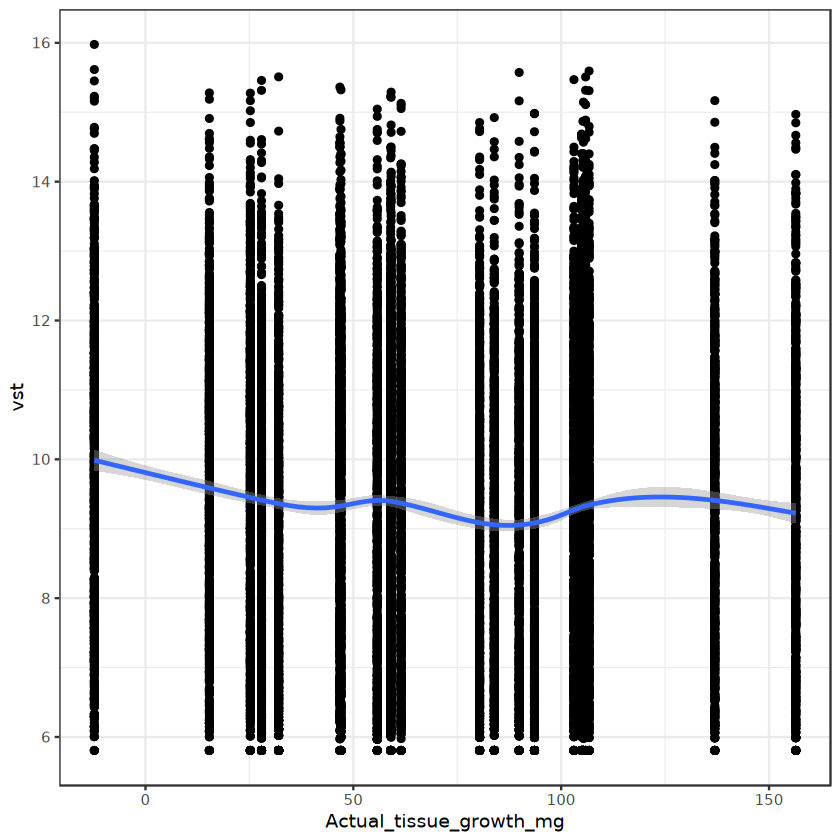

In [18]:
ggplot(red_vst_growth, aes(x = Actual_tissue_growth_mg, y = vst)) +
geom_point() +
geom_smooth() +
theme_bw()

#### hub gene: LOC111135053

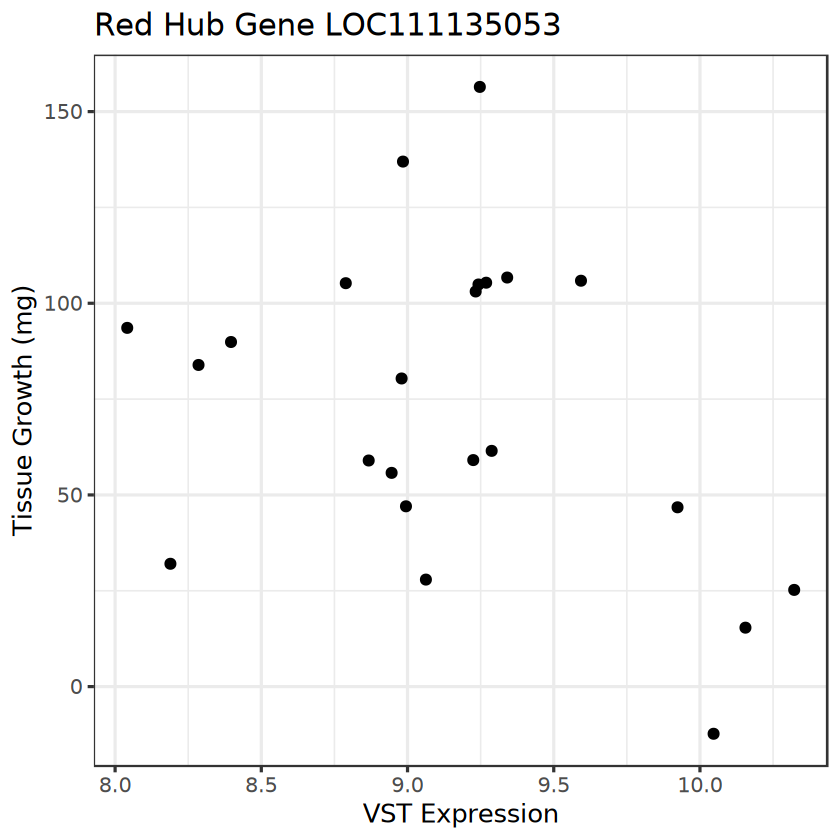

In [19]:
red_hubGene <- red_vst_growth %>% filter(Gene == 'LOC111135053')

ggplot(red_hubGene, aes(x = vst, y = Actual_tissue_growth_mg)) +
geom_point() +
labs(x = 'VST Expression',
     y = 'Tissue Growth (mg)',
     title = 'Red Hub Gene LOC111135053') +
theme_bw(base_size = 15)

#### vst vs. growth 

In [20]:
red_gs <- geneInfo %>% 
filter(ModuleColor == 'red') %>%
dplyr::select(Gene, GS.Actual_tissue_growth_mg, p.GS.GS.Actual_tissue_growth_mg)

# split by 

dim(red_gs)
head(red_gs)

[1] 714   3

,Gene,GS.Actual_tissue_growth_mg,p.GS.GS.Actual_tissue_growth_mg
,<chr>,<dbl>,<dbl>
1,LOC111099041,-0.31034805,0.1495152
2,LOC111099693,-0.21510355,0.3242933
3,LOC111099735,0.15863297,0.4697115
4,LOC111099746,-0.06459774,0.7696527
5,LOC111099748,0.17526897,0.4237652
6,LOC111099814,0.14115925,0.5205792


now want to split this group into genes that are significant (pval < 0.05) and pos/neg correlated

In [21]:
red_gs2 <- red_gs %>%
mutate(geneClass = case_when(
    p.GS.GS.Actual_tissue_growth_mg < 0.05 & GS.Actual_tissue_growth_mg > 0 ~ 'Sig Pos',
    p.GS.GS.Actual_tissue_growth_mg < 0.05 & GS.Actual_tissue_growth_mg < 0 ~ 'Sig Neg',
    TRUE ~ 'Not Sig'))

head(red_gs2)

,Gene,GS.Actual_tissue_growth_mg,p.GS.GS.Actual_tissue_growth_mg,geneClass
,<chr>,<dbl>,<dbl>,<chr>
1,LOC111099041,-0.31034805,0.1495152,Not Sig
2,LOC111099693,-0.21510355,0.3242933,Not Sig
3,LOC111099735,0.15863297,0.4697115,Not Sig
4,LOC111099746,-0.06459774,0.7696527,Not Sig
5,LOC111099748,0.17526897,0.4237652,Not Sig
6,LOC111099814,0.14115925,0.5205792,Not Sig


In [22]:
red_geneClass <- merge(red_vst_growth, red_gs2, by = 'Gene')
head(red_geneClass)

,Gene,Sample,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,GS.Actual_tissue_growth_mg,p.GS.GS.Actual_tissue_growth_mg,geneClass
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
1,LOC111099041,C3_Nu_W21,10.557433,Cont,Ambient,Norm,61.49480,123.50520,0.497912638,-0.3103481,0.1495152,Not Sig
2,LOC111099041,B4_Nu_O32,10.381036,Both,Warm,Hyp,105.36056,145.03944,0.726426964,-0.3103481,0.1495152,Not Sig
3,LOC111099041,B2_Nu_O12,10.811916,Both,Warm,Hyp,80.37700,150.42300,0.534339828,-0.3103481,0.1495152,Not Sig
4,LOC111099041,H6_Nu_B45,9.851962,Hyp,Ambient,Hyp,58.97876,108.62124,0.542976309,-0.3103481,0.1495152,Not Sig
5,LOC111099041,H1_Nu_B08,10.165842,Hyp,Ambient,Hyp,47.03080,60.16920,0.781642435,-0.3103481,0.1495152,Not Sig
6,LOC111099041,B5_Nu_O36,10.682047,Both,Warm,Hyp,25.22362,32.77638,0.769566987,-0.3103481,0.1495152,Not Sig


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


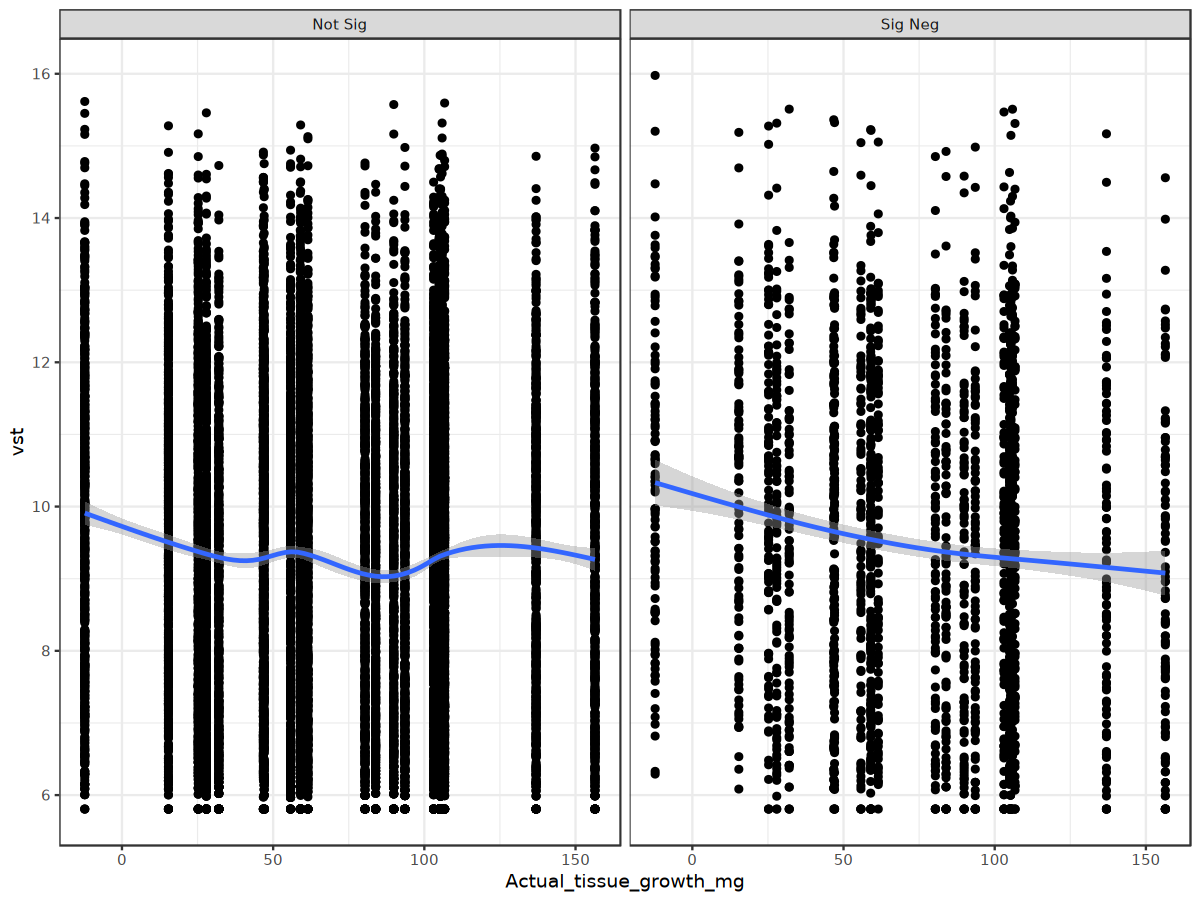

In [23]:
options(repr.plot.height = 7.5, repr.plot.width = 10)

ggplot(red_geneClass, aes(x = Actual_tissue_growth_mg, y = vst)) +
geom_point() +
geom_smooth() +
facet_wrap(~geneClass, nrow = 1) +
theme_bw()

hmm so there are no genes that have a positive correlation *and* have a significant pvalue - which makes sense since this module has a negative correlation with tissue growth

pulling out the top 20 correlated genes and plotting their expression

In [24]:
# grab only the significant negatively correlated genes
signeg_red <- red_gs2 %>% filter(geneClass == 'Sig Neg')

# order by correlation, take the top 20 genes
sig_red_top20 <- signeg_red[order(signeg_red$GS.Actual_tissue_growth_mg, decreasing = TRUE),][1:20,]

# pull vst and growth for samples for these 20 genes
red_gc_top20 <- red_geneClass[red_geneClass$Gene %in% sig_red_top20$Gene,]

# add gene annotation
colnames(red_gc_top20)[1] <- 'gene_id'
red_gc_top20 <- merge(red_gc_top20, annot, by = 'gene_id')

# check things look okay
length(unique(red_gc_top20$gene_id))
head(red_gc_top20)

[1] 20

,gene_id,Sample,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,GS.Actual_tissue_growth_mg,p.GS.GS.Actual_tissue_growth_mg,geneClass,description
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,LOC111103955,H6_Nu_B45,11.84032,Hyp,Ambient,Hyp,58.97876,108.6212,0.542976309,-0.4179917,0.04717046,Sig Neg,E3 ubiquitin-protein ligase rnf213-alpha-like
2,LOC111103955,C2_Nu_W15,11.02456,Cont,Ambient,Norm,103.06942,132.5306,0.777702927,-0.4179917,0.04717046,Sig Neg,E3 ubiquitin-protein ligase rnf213-alpha-like
3,LOC111103955,B1_Nu_O03,11.69418,Both,Warm,Hyp,27.91340,77.5866,0.359770888,-0.4179917,0.04717046,Sig Neg,E3 ubiquitin-protein ligase rnf213-alpha-like
4,LOC111103955,W2_Nu_G15,10.43664,Warm,Warm,Norm,89.89144,203.3086,0.442142918,-0.4179917,0.04717046,Sig Neg,E3 ubiquitin-protein ligase rnf213-alpha-like
5,LOC111103955,B4_Nu_O32,12.68704,Both,Warm,Hyp,105.36056,145.0394,0.726426964,-0.4179917,0.04717046,Sig Neg,E3 ubiquitin-protein ligase rnf213-alpha-like
6,LOC111103955,H2_Nu_B14,10.21580,Hyp,Ambient,Hyp,156.43526,152.1647,1.028065109,-0.4179917,0.04717046,Sig Neg,E3 ubiquitin-protein ligase rnf213-alpha-like


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


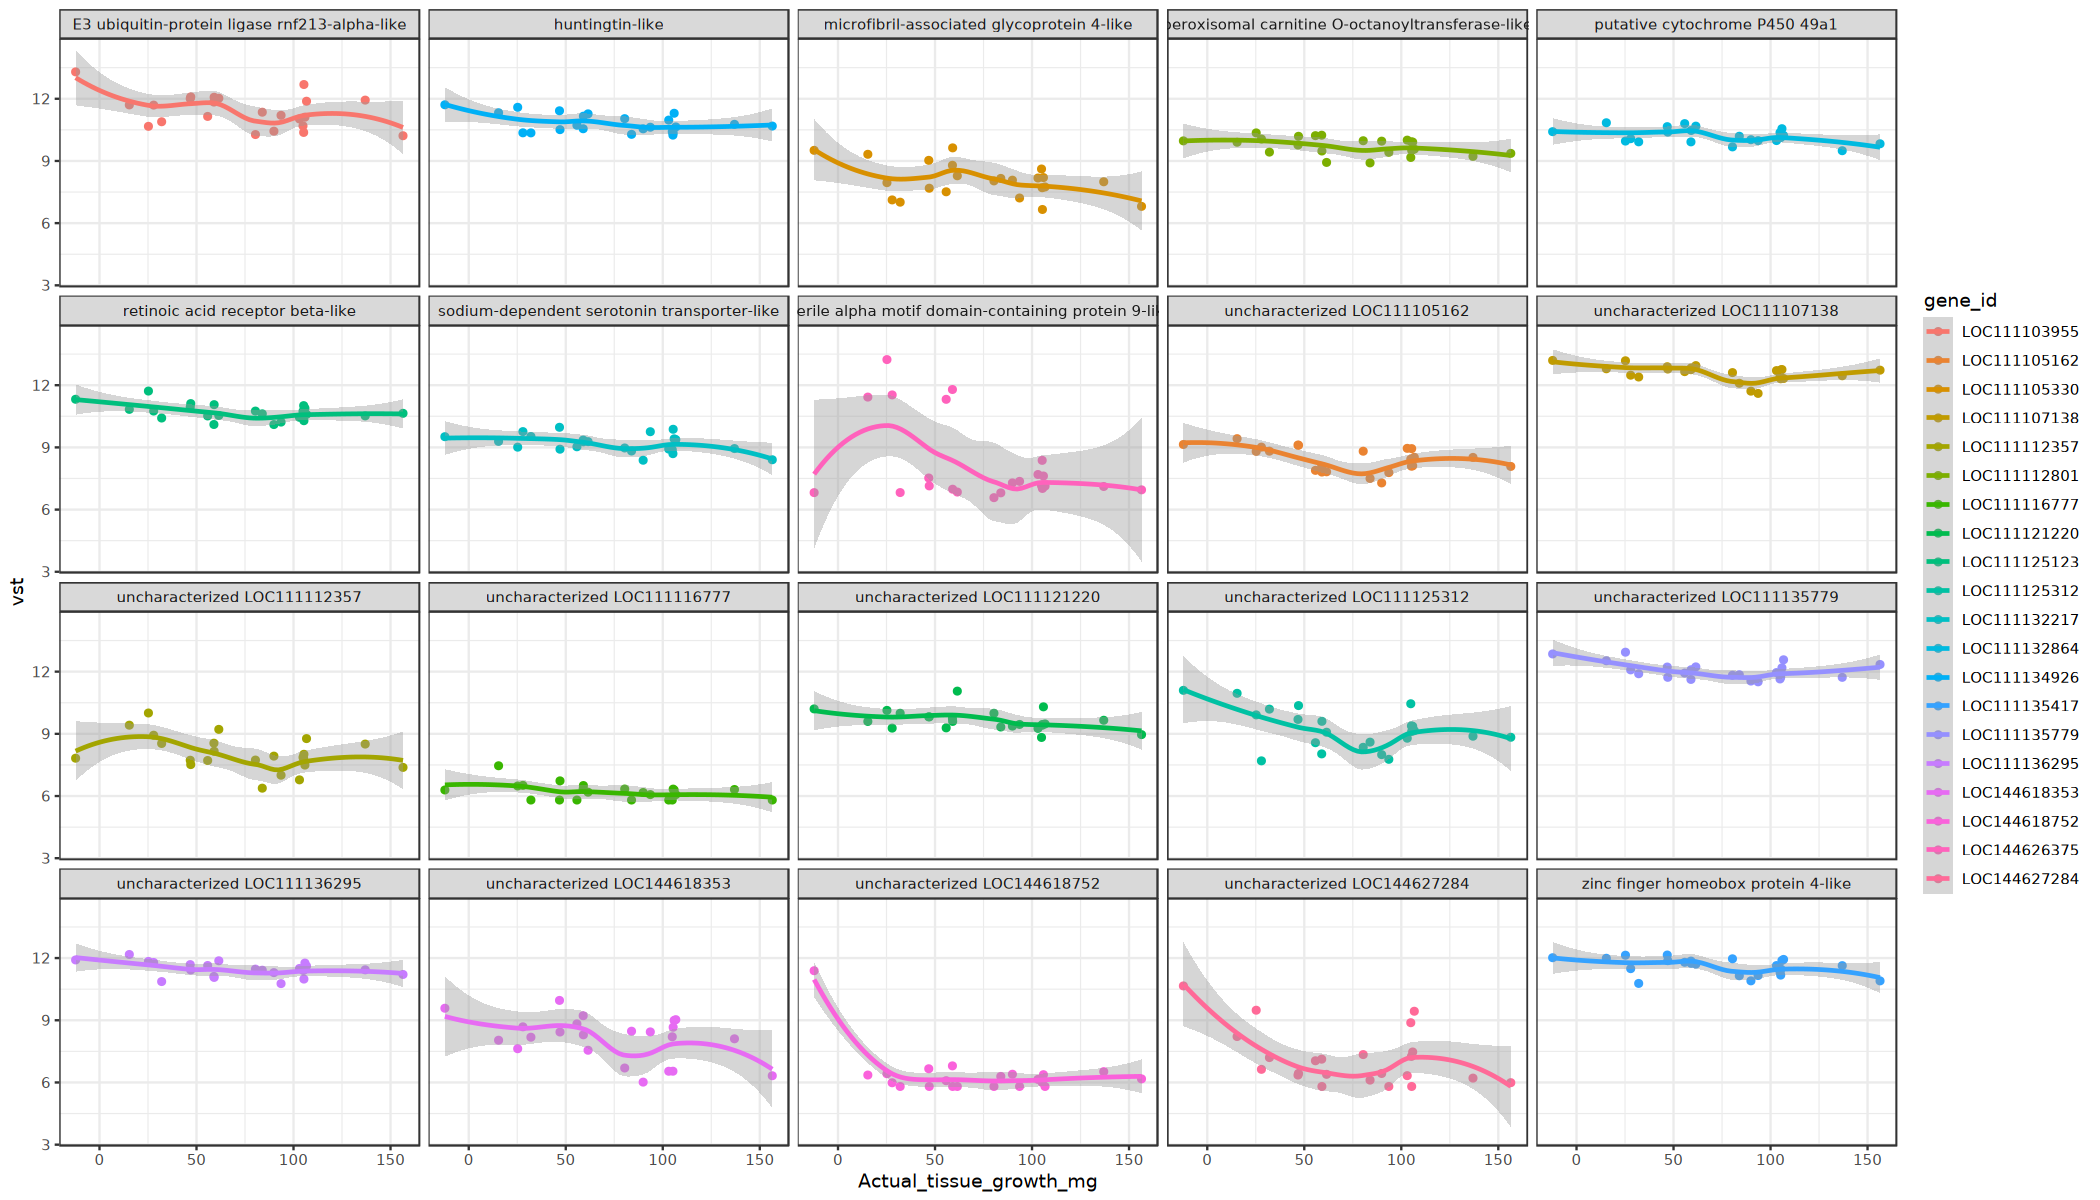

In [25]:
options(repr.plot.width = 17.5, repr.plot.height = 10)

ggplot(red_gc_top20, aes(x = Actual_tissue_growth_mg, y = vst, col = gene_id)) +
geom_point() +
geom_smooth() +
facet_wrap(~description) +
theme_bw()

seems like most of them have week trends (in terms of vst vs. growth)

In [26]:
annot[annot$gene_id %in% red_gc_top20$Gene,]

gene_id,description
<chr>,<chr>


most of the top 20 negatively correlated genes with tissue growth are uncharacterized. 

we do see a glycoprotein show up, and other transport/transferase related genes

#### vst heatmap

In [97]:
red_mat <- red_geneClass %>% 
dplyr::select(Gene, Sample, vst) %>%
pivot_wider(
    names_from = Sample,
    values_from = vst) %>%
column_to_rownames('Gene')

head(red_mat)

,C3_Nu_W21,B4_Nu_O32,B2_Nu_O12,H6_Nu_B45,H1_Nu_B08,B5_Nu_O36,H3_Nu_B18,C1_Nu_W01,H2_Nu_B14,C1_Nu_W05,⋯,W6_Nu_G41,W3_Nu_G21,H4_Nu_B28,W4_Nu_G27,C4_Nu_W29,B6_Nu_O47,C6_Nu_W42,W2_Nu_G15,W6_Nu_G45,H5_Nu_B35
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111099041,10.557433,10.381036,10.811916,9.851962,10.165842,10.682047,9.795928,10.113105,9.872112,9.929686,⋯,9.842945,9.340883,10.556628,10.397023,9.790249,10.221523,9.964988,9.613846,10.441759,11.202678
LOC111099693,12.869541,12.772555,12.512475,12.675993,12.977139,13.113847,12.141094,12.562936,13.223285,12.334081,⋯,12.562342,12.578297,12.688939,13.057697,12.809951,13.278616,12.063722,12.015347,12.976863,13.217338
LOC111099735,10.001753,10.893430,10.186109,9.922346,10.129200,10.604689,9.764464,10.823842,11.074739,11.054443,⋯,10.917733,9.324133,11.565536,10.085341,10.695111,11.088650,9.813783,9.975622,11.039747,10.202124
LOC111099746,10.241810,9.759351,10.152452,9.493045,9.730465,10.659783,9.996914,10.395609,10.899941,10.104170,⋯,9.861602,9.689883,10.459671,10.485342,10.088656,10.970561,9.463237,9.932232,10.290214,10.707537
LOC111099748,7.604578,7.316404,7.641042,7.090712,7.566409,7.672005,7.210167,8.374508,8.046228,7.238653,⋯,8.049045,6.720237,7.619278,7.725734,7.247404,8.030228,7.094670,7.207834,7.678582,7.698829
LOC111099814,6.779645,6.237460,6.132500,6.886919,6.465687,7.069263,5.806396,6.564693,6.510908,6.330934,⋯,6.274945,6.737737,6.369194,8.963421,6.601278,6.291005,5.806396,5.806396,6.632964,6.628278


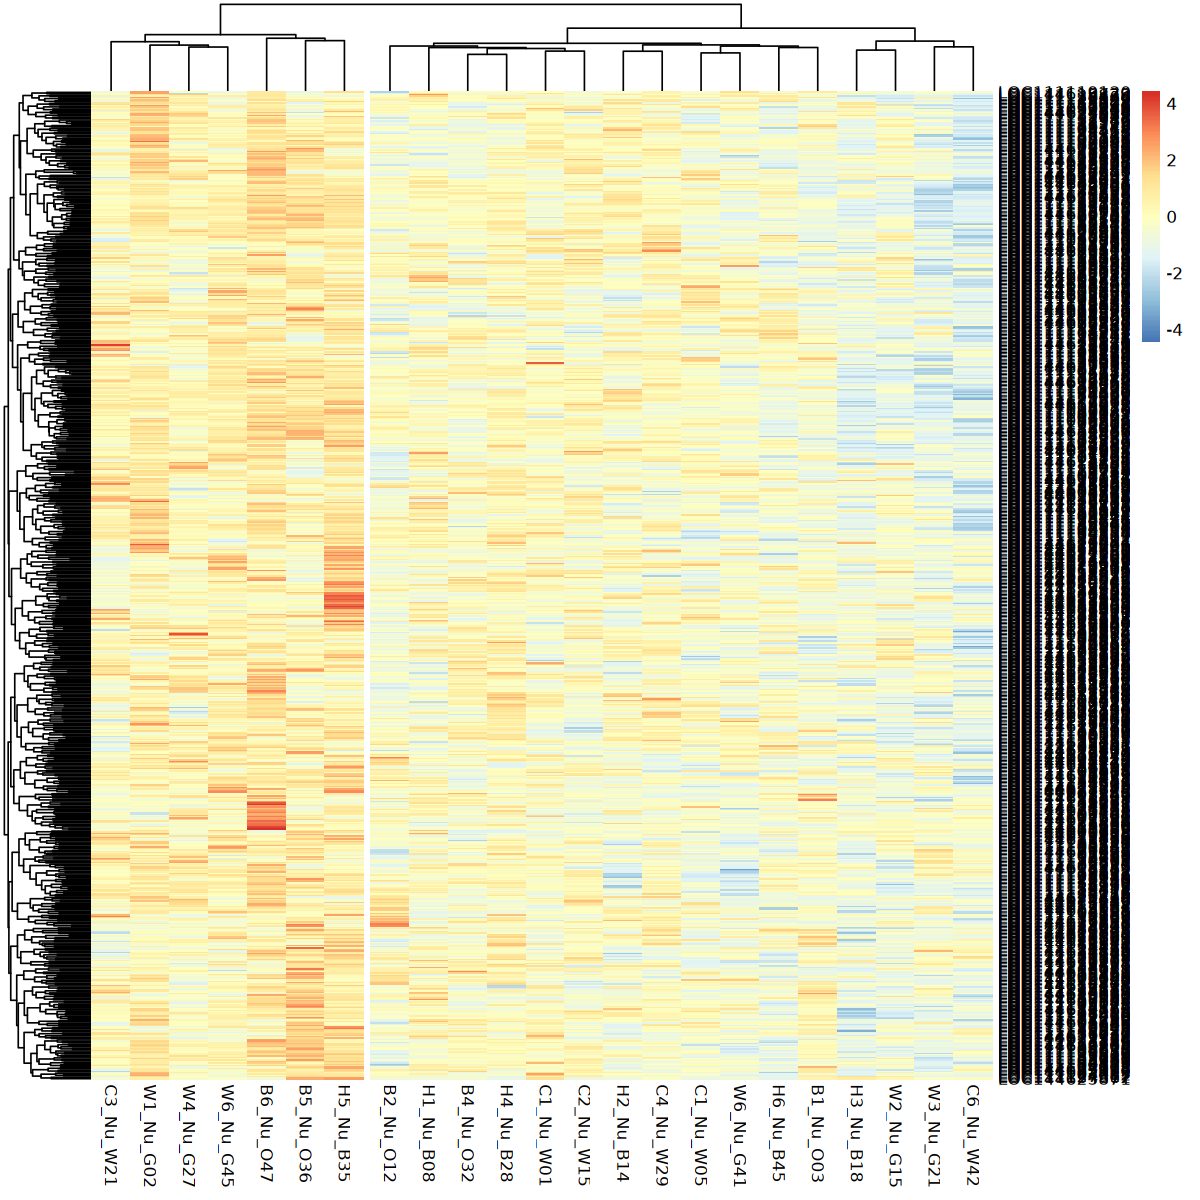

In [101]:
options(repr.plot.height = 10, repr.plot.width = 10)

pheatmap(red_mat,
         #cutree_rows = 2, 
         cutree_cols = 2,
         scale = 'row' # standardizes each gene separately across samples)
         )

now order by tissue growth

In [105]:
ordered_growth.red <- growth[order(growth$Actual_tissue_growth_mg), ]
head(ordered_growth.red)

,Sample,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,temp_binary
,<chr>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
5,B6_Nu_O47,Both,Warm,Hyp,-12.30496,117.80496,-0.104451969,0
16,H5_Nu_B35,Hyp,Ambient,Hyp,15.37302,47.02698,0.326897879,0
4,B5_Nu_O36,Both,Warm,Hyp,25.22362,32.77638,0.769566987,0
1,B1_Nu_O03,Both,Warm,Hyp,27.91340,77.58660,0.359770888,0
11,C6_Nu_W42,Cont,Ambient,Norm,32.03846,76.16154,0.420664551,0
18,W1_Nu_G02,Warm,Warm,Norm,46.77246,60.32754,0.77530859,1


In [106]:
ordered_red_vst.matrix <- red_mat[,ordered_growth.red$Sample]
head(ordered_red_vst.matrix)

,B6_Nu_O47,H5_Nu_B35,B5_Nu_O36,B1_Nu_O03,C6_Nu_W42,W1_Nu_G02,H1_Nu_B08,C4_Nu_W29,H6_Nu_B45,H4_Nu_B28,⋯,W2_Nu_G15,W3_Nu_G21,C2_Nu_W15,C1_Nu_W05,W6_Nu_G41,B4_Nu_O32,W6_Nu_G45,W4_Nu_G27,C1_Nu_W01,H2_Nu_B14
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111099041,10.221523,11.202678,10.682047,10.003319,9.964988,10.186812,10.165842,9.790249,9.851962,10.556628,⋯,9.613846,9.340883,10.253939,9.929686,9.842945,10.381036,10.441759,10.397023,10.113105,9.872112
LOC111099693,13.278616,13.217338,13.113847,12.775150,12.063722,13.297710,12.977139,12.809951,12.675993,12.688939,⋯,12.015347,12.578297,13.000346,12.334081,12.562342,12.772555,12.976863,13.057697,12.562936,13.223285
LOC111099735,11.088650,10.202124,10.604689,9.985070,9.813783,10.653349,10.129200,10.695111,9.922346,11.565536,⋯,9.975622,9.324133,10.233760,11.054443,10.917733,10.893430,11.039747,10.085341,10.823842,11.074739
LOC111099746,10.970561,10.707537,10.659783,9.985070,9.463237,10.927240,9.730465,10.088656,9.493045,10.459671,⋯,9.932232,9.689883,10.614282,10.104170,9.861602,9.759351,10.290214,10.485342,10.395609,10.899941
LOC111099748,8.030228,7.698829,7.672005,7.172246,7.094670,8.074793,7.566409,7.247404,7.090712,7.619278,⋯,7.207834,6.720237,7.924149,7.238653,8.049045,7.316404,7.678582,7.725734,8.374508,8.046228
LOC111099814,6.291005,6.628278,7.069263,6.162650,5.806396,6.645652,6.465687,6.601278,6.886919,6.369194,⋯,5.806396,6.737737,6.868619,6.330934,6.274945,6.237460,6.632964,8.963421,6.564693,6.510908


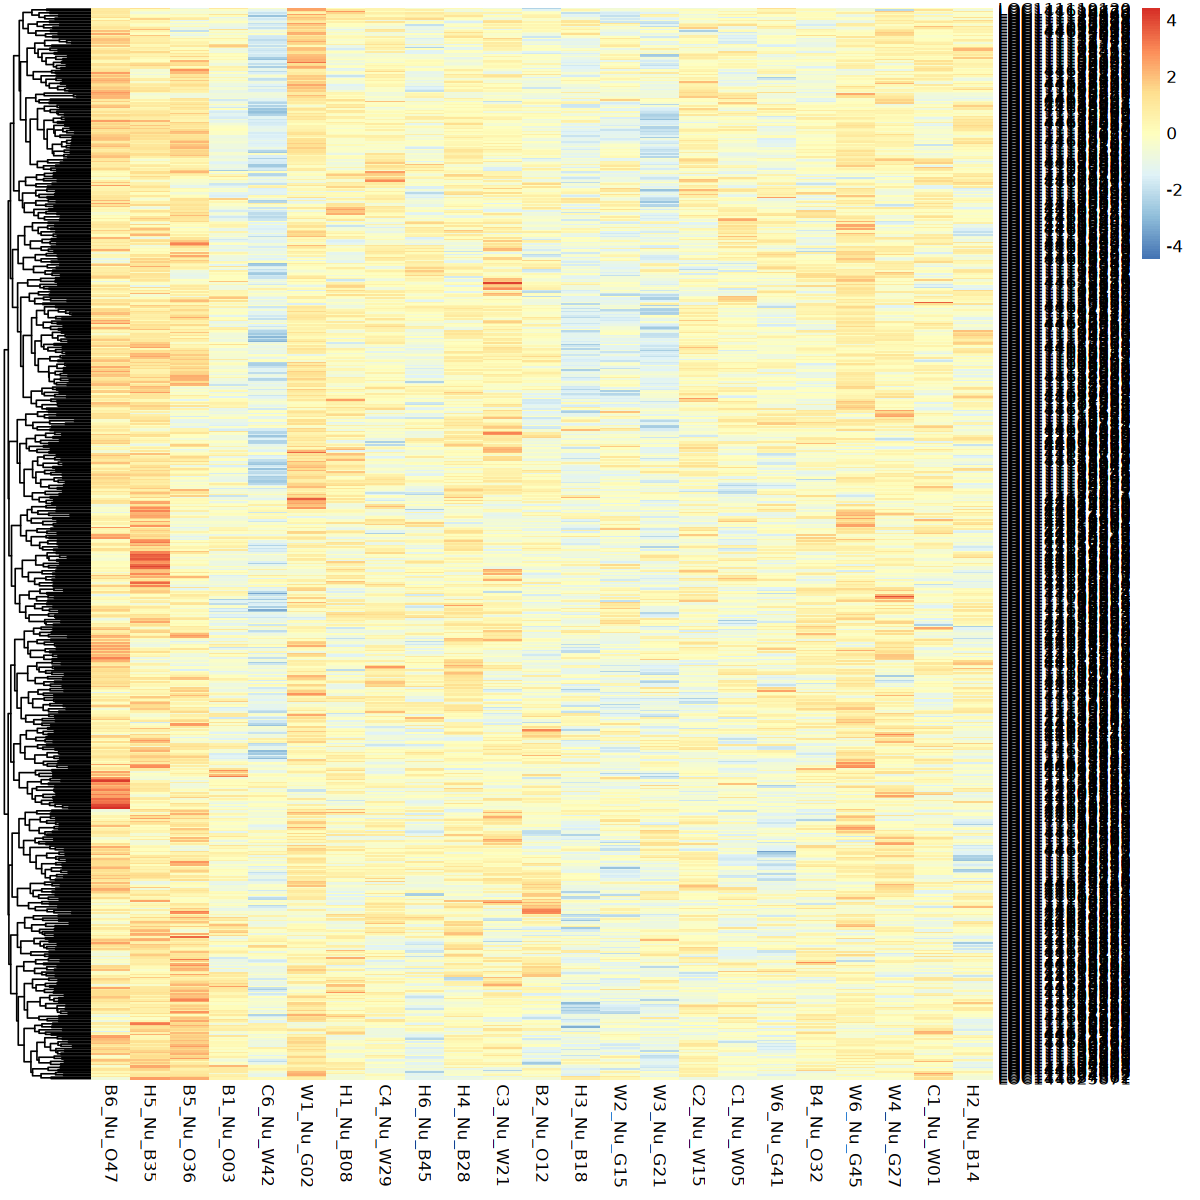

In [107]:
pheatmap(ordered_red_vst.matrix,
                 cluster_cols = FALSE,
         #cutree_rows = 2, 
         #cutree_cols = 2,
         scale = 'row' # standardizes each gene separately across samples)
         )

the red module has a negative correlation with tissue growth - so we expect to see the samples with the least amount of tissue growth (left) to have higher expression (red) than the samples with the most amount of tissue growth (right)

when I order the heatmap based on tissue growth, this isn't super convincing - looks like there's some samples with less tissue growth with a lot of dense red that might be pulling this relationship? but the middle of the pack has a lot more blue than the right side of the heatmap

### black module
negatively correlated with phase 1 temperature

In [27]:
# pull black genes
black_genes <- geneInfo %>% 
filter(ModuleColor == 'black') %>% 
pull(Gene)

length(black_genes) # 528 genes in the red module

[1] 528

In [28]:
# vst for red genes
black_vst <- vst[vst$X %in% black_genes,]

dim(black_vst)
head(black_vst)

[1] 528  24

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
43,LOC144617592,6.491575,6.182683,6.055887,6.012335,5.806396,6.660921,7.099916,7.426192,5.806396,⋯,7.020367,5.806396,5.806396,5.806396,6.580028,5.806396,5.806396,5.806396,6.900280,5.806396
50,LOC111104088,9.987517,10.954550,10.004884,10.319670,11.011257,10.475387,10.421614,11.002398,10.515052,⋯,11.435374,11.072550,10.687704,11.202202,10.759525,10.948786,11.066142,10.803188,10.576612,10.340188
55,LOC111103019,9.431422,8.450904,8.892667,8.587891,8.593957,8.330550,9.861483,9.298037,8.794545,⋯,9.291009,8.247094,9.162212,9.026840,9.449745,8.903490,8.672060,8.314012,9.413583,9.101256
95,LOC111105195,5.806396,5.994939,6.756605,6.162490,6.542135,6.778185,5.806396,6.590103,6.737210,⋯,6.828529,6.786432,6.650187,5.806396,6.042198,6.795600,6.259740,6.493428,5.806396,5.806396
151,LOC111105311,12.575185,9.758872,10.857972,9.610745,10.297930,11.753441,9.826124,12.443595,14.344903,⋯,13.021566,11.560508,11.296086,10.571166,5.806396,11.163884,8.556948,8.453537,7.278678,11.652631
241,LOC111104257,6.984570,5.806396,5.806396,6.265342,6.638148,6.118934,6.087874,6.885407,6.145801,⋯,7.020367,6.266881,6.285153,5.806396,7.675889,6.359478,6.177054,6.583375,6.346648,6.022544


In [29]:
# convert vst to long format
black_vst.long <- black_vst %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst')

colnames(black_vst.long)[1] <- 'Gene'

head(black_vst.long)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC144617592,B1_Nu_O03,6.491575
LOC144617592,B2_Nu_O12,6.182683
LOC144617592,B4_Nu_O32,6.055887
LOC144617592,B5_Nu_O36,6.012335
LOC144617592,B6_Nu_O47,5.806396
LOC144617592,C1_Nu_W01,6.660921


In [30]:
# add growth info
black_vst_growth <- merge(black_vst.long, growth, by = 'Sample')
head(black_vst_growth)

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_Nu_O03,LOC144617592,6.491575,Both,Warm,Hyp,27.9134,77.5866,0.359770888
2,B1_Nu_O03,LOC111113657,8.592140,Both,Warm,Hyp,27.9134,77.5866,0.359770888
3,B1_Nu_O03,LOC144617451,8.705273,Both,Warm,Hyp,27.9134,77.5866,0.359770888
4,B1_Nu_O03,LOC111114548,8.518158,Both,Warm,Hyp,27.9134,77.5866,0.359770888
5,B1_Nu_O03,LOC111128341,6.420371,Both,Warm,Hyp,27.9134,77.5866,0.359770888
6,B1_Nu_O03,LOC111120762,8.848556,Both,Warm,Hyp,27.9134,77.5866,0.359770888


#### plot phase 1 temp vs. module expression

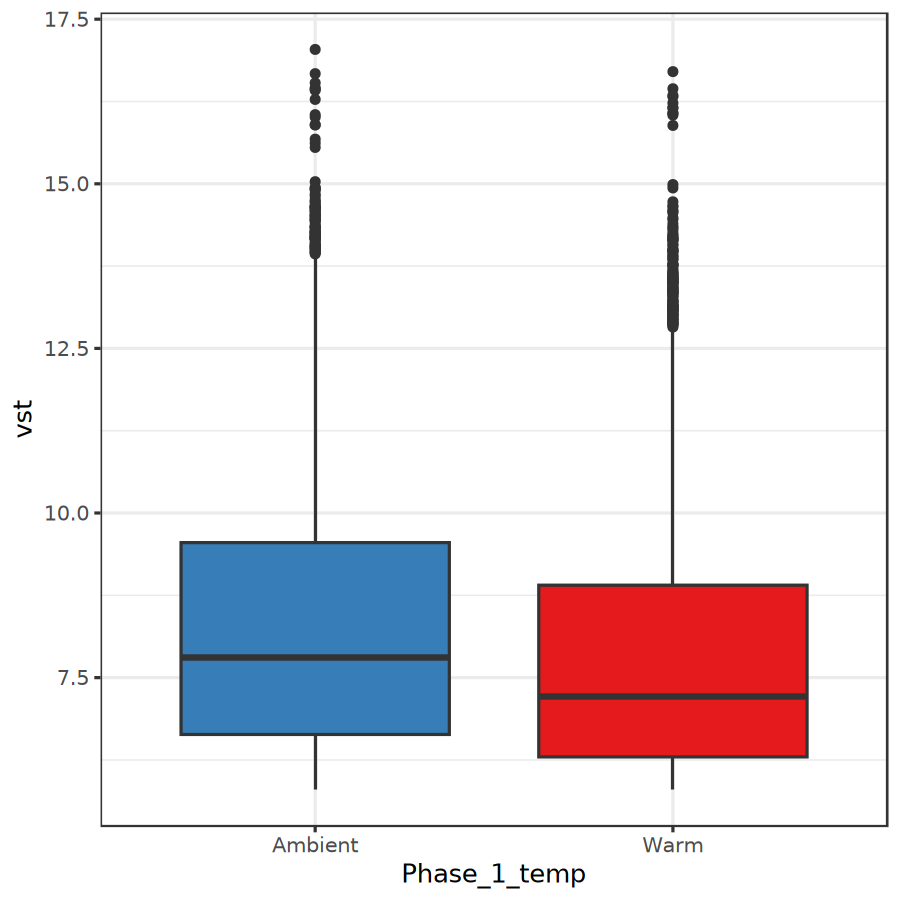

In [31]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

ggplot(black_vst_growth, aes(x = Phase_1_temp, y = vst, fill = Phase_1_temp)) +
geom_boxplot() +
scale_fill_brewer(palette = 'Set1', direction = -1) +
guides(fill = 'none') +
theme_bw(base_size = 15)

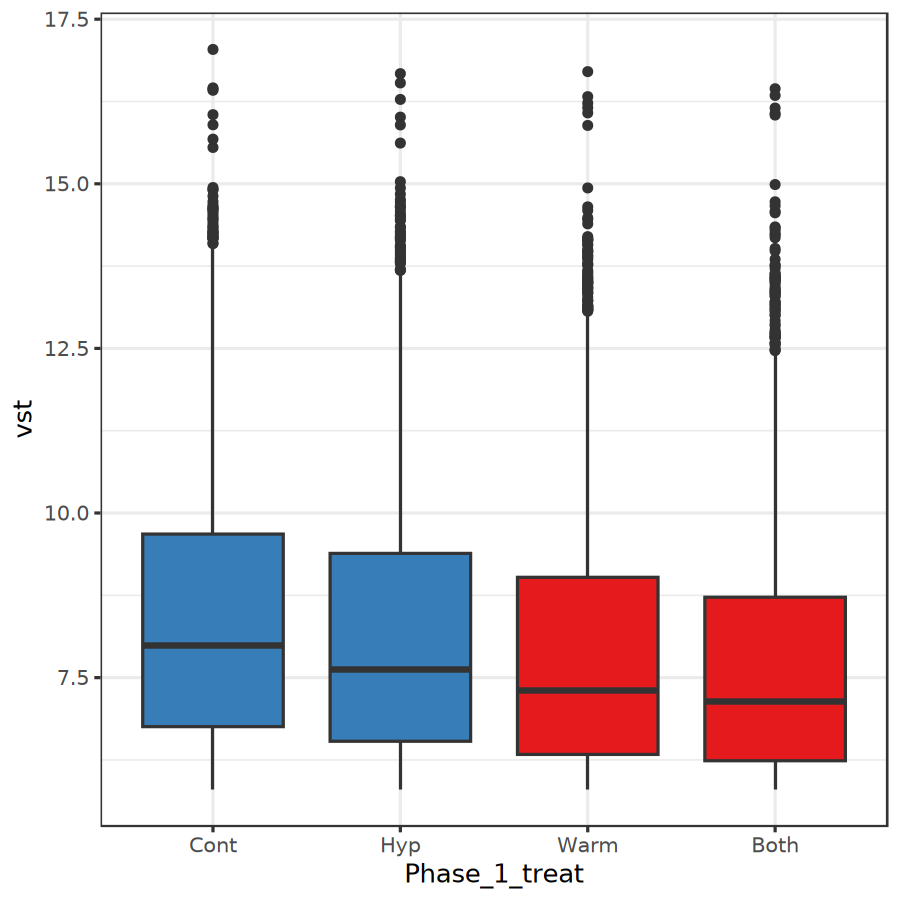

In [32]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

black_vst_growth$Phase_1_treat <- factor(black_vst_growth$Phase_1_treat, levels = c('Cont', 'Hyp', 'Warm', 'Both'))

ggplot(black_vst_growth, aes(x = Phase_1_treat, y = vst, fill = Phase_1_temp)) +
geom_boxplot() +
scale_fill_brewer(palette = 'Set1', direction = -1) +
guides(fill = 'none') +
theme_bw(base_size = 15)

#### hub gene: LOC111137329

In [33]:
geneInfo %>% filter(Gene == 'LOC111137329')

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.both,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


i do not understand how a hub gene isn't in the gene info df ... i've rerun the WGCNA and still am not getting it...

i'll deal with it later

In [34]:
rownames(black_vst) <- NULL

black.matrix <- black_vst %>%
column_to_rownames('X')

head(black.matrix)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144617592,6.491575,6.182683,6.055887,6.012335,5.806396,6.660921,7.099916,7.426192,5.806396,5.967308,⋯,7.020367,5.806396,5.806396,5.806396,6.580028,5.806396,5.806396,5.806396,6.900280,5.806396
LOC111104088,9.987517,10.954550,10.004884,10.319670,11.011257,10.475387,10.421614,11.002398,10.515052,10.430575,⋯,11.435374,11.072550,10.687704,11.202202,10.759525,10.948786,11.066142,10.803188,10.576612,10.340188
LOC111103019,9.431422,8.450904,8.892667,8.587891,8.593957,8.330550,9.861483,9.298037,8.794545,8.910036,⋯,9.291009,8.247094,9.162212,9.026840,9.449745,8.903490,8.672060,8.314012,9.413583,9.101256
LOC111105195,5.806396,5.994939,6.756605,6.162490,6.542135,6.778185,5.806396,6.590103,6.737210,5.967308,⋯,6.828529,6.786432,6.650187,5.806396,6.042198,6.795600,6.259740,6.493428,5.806396,5.806396
LOC111105311,12.575185,9.758872,10.857972,9.610745,10.297930,11.753441,9.826124,12.443595,14.344903,11.615763,⋯,13.021566,11.560508,11.296086,10.571166,5.806396,11.163884,8.556948,8.453537,7.278678,11.652631
LOC111104257,6.984570,5.806396,5.806396,6.265342,6.638148,6.118934,6.087874,6.885407,6.145801,5.806396,⋯,7.020367,6.266881,6.285153,5.806396,7.675889,6.359478,6.177054,6.583375,6.346648,6.022544


In [35]:
annotation <- growth %>%
  dplyr::select(Sample, Phase_1_temp) %>%
  column_to_rownames("Sample") 

annotation_colors <- list(
  Phase_1_treat = c(
    Ambient = "burlywood3",
    Warm = "palevioletred"
  )
)

head(annotation)
head(annotation_colors)

,Phase_1_temp
,<chr>
B1_Nu_O03,Warm
B2_Nu_O12,Warm
B4_Nu_O32,Warm
B5_Nu_O36,Warm
B6_Nu_O47,Warm
C1_Nu_W01,Ambient


$Phase_1_treat
        Ambient            Warm 
   "burlywood3" "palevioletred"

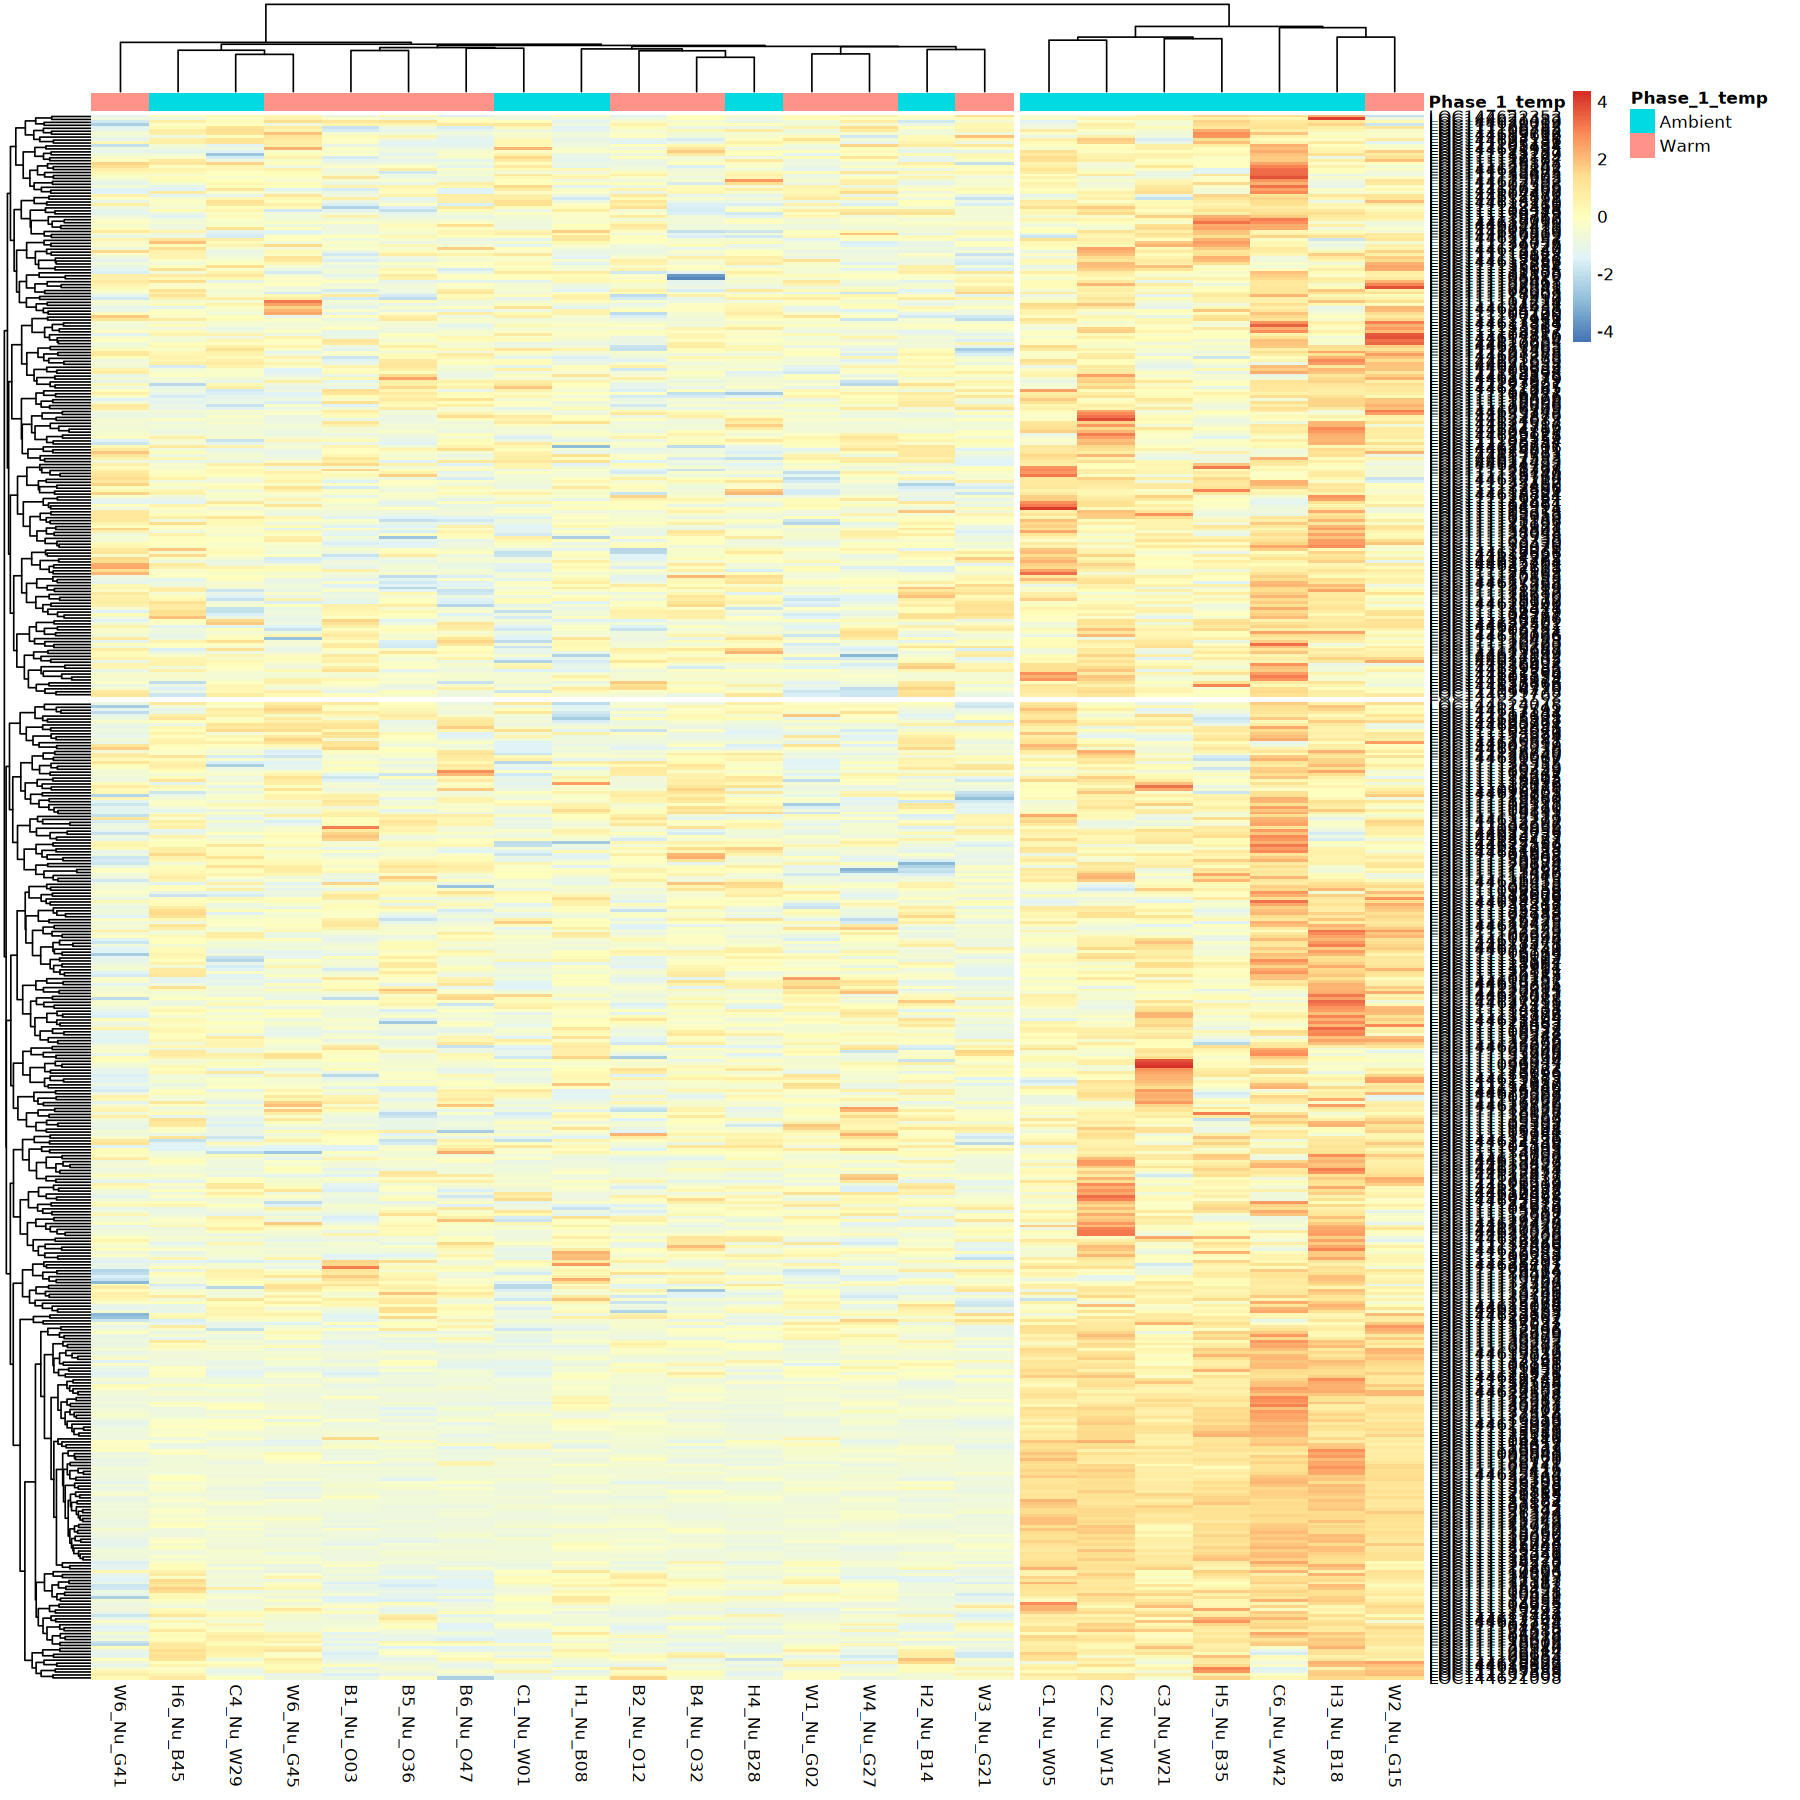

In [36]:
options(repr.plot.width = 15, repr.plot.height = 15)

pheatmap(black.matrix,
       # cluster_cols = FALSE,
        annotation_col = annotation,
        annotation_colors = annotation_colors,
         cutree_rows = 2, 
         cutree_cols = 2,
         scale = 'row' # standardizes each gene separately across samples
        ) 

so we see that there are a number of ambient samples that cluster together (mostly control oysters) that have higher expression of this group of genes - when I look back at the module-trait heatmap, I see that there is an almost significant (says 0.05 but that must be rounded) correlation of this module with control conditions - and so I can clearly see here that control oysters are driving this correlation

### blue module
positively correlated with shell growth and temperature treatment

In [37]:
# pull red genes
blue_genes <- geneInfo %>% 
filter(ModuleColor == 'blue') %>% 
pull(Gene)

length(blue_genes) # 1149 genes in the red module

[1] 1149

In [38]:
# vst for red genes
blue_vst <- vst[vst$X %in% blue_genes,]

dim(blue_vst)
head(blue_vst)

[1] 1149   24

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
42,LOC111103350,9.010443,7.060082,9.039641,8.195446,8.614067,8.272462,7.617818,6.980232,7.958207,⋯,10.565649,6.995920,7.781420,8.054730,8.179476,11.039693,8.958540,8.397802,7.278678,7.435651
48,LOC111103667,10.683765,10.159731,10.098630,9.894236,9.931693,11.179419,10.514259,9.775269,10.156670,⋯,10.240149,10.053264,10.341467,9.888592,10.469400,11.013350,10.880907,10.334288,10.804500,10.057273
53,LOC144621561,5.806396,7.189715,6.996165,6.594821,7.210938,6.762428,5.806396,5.806396,7.353748,⋯,7.280236,6.597423,6.422614,5.806396,6.734561,7.946745,6.866035,6.948629,6.611047,7.258738
67,LOC144621743,7.357536,8.691806,7.834363,7.154715,9.660346,7.920388,7.843740,7.311516,8.192720,⋯,8.776053,7.634487,8.043508,8.268182,8.363767,8.874120,7.507840,8.533109,8.014646,8.273622
146,LOC144619181,5.984862,6.834983,7.096549,6.265342,5.806396,11.116238,6.461914,5.806396,5.806396,⋯,11.749544,5.806396,9.531418,5.806396,5.806396,12.013272,6.978286,6.176098,7.224374,9.446437
148,LOC111105167,8.196331,7.189715,5.806396,7.503663,6.982631,6.660921,5.806396,5.806396,7.421640,⋯,6.849611,5.806396,7.040880,5.806396,6.888116,6.947474,8.036163,6.717943,5.998381,6.237491


In [39]:
# convert vst to long format
blue_vst.long <- blue_vst %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') %>%
dplyr::rename(Gene = X)

head(blue_vst.long)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC111103350,B1_Nu_O03,9.010443
LOC111103350,B2_Nu_O12,7.060082
LOC111103350,B4_Nu_O32,9.039641
LOC111103350,B5_Nu_O36,8.195446
LOC111103350,B6_Nu_O47,8.614067
LOC111103350,C1_Nu_W01,8.272462


In [40]:
# add growth info
blue_vst_growth <- merge(blue_vst.long, growth, by = 'Sample')
head(blue_vst_growth)

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_Nu_O03,LOC111103350,9.010443,Both,Warm,Hyp,27.9134,77.5866,0.359770888
2,B1_Nu_O03,LOC144627356,8.749823,Both,Warm,Hyp,27.9134,77.5866,0.359770888
3,B1_Nu_O03,LOC111128566,8.293409,Both,Warm,Hyp,27.9134,77.5866,0.359770888
4,B1_Nu_O03,LOC111112119,11.234507,Both,Warm,Hyp,27.9134,77.5866,0.359770888
5,B1_Nu_O03,LOC144626863,6.308952,Both,Warm,Hyp,27.9134,77.5866,0.359770888
6,B1_Nu_O03,LOC111119055,9.805289,Both,Warm,Hyp,27.9134,77.5866,0.359770888


#### plot growth vs. module expression

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


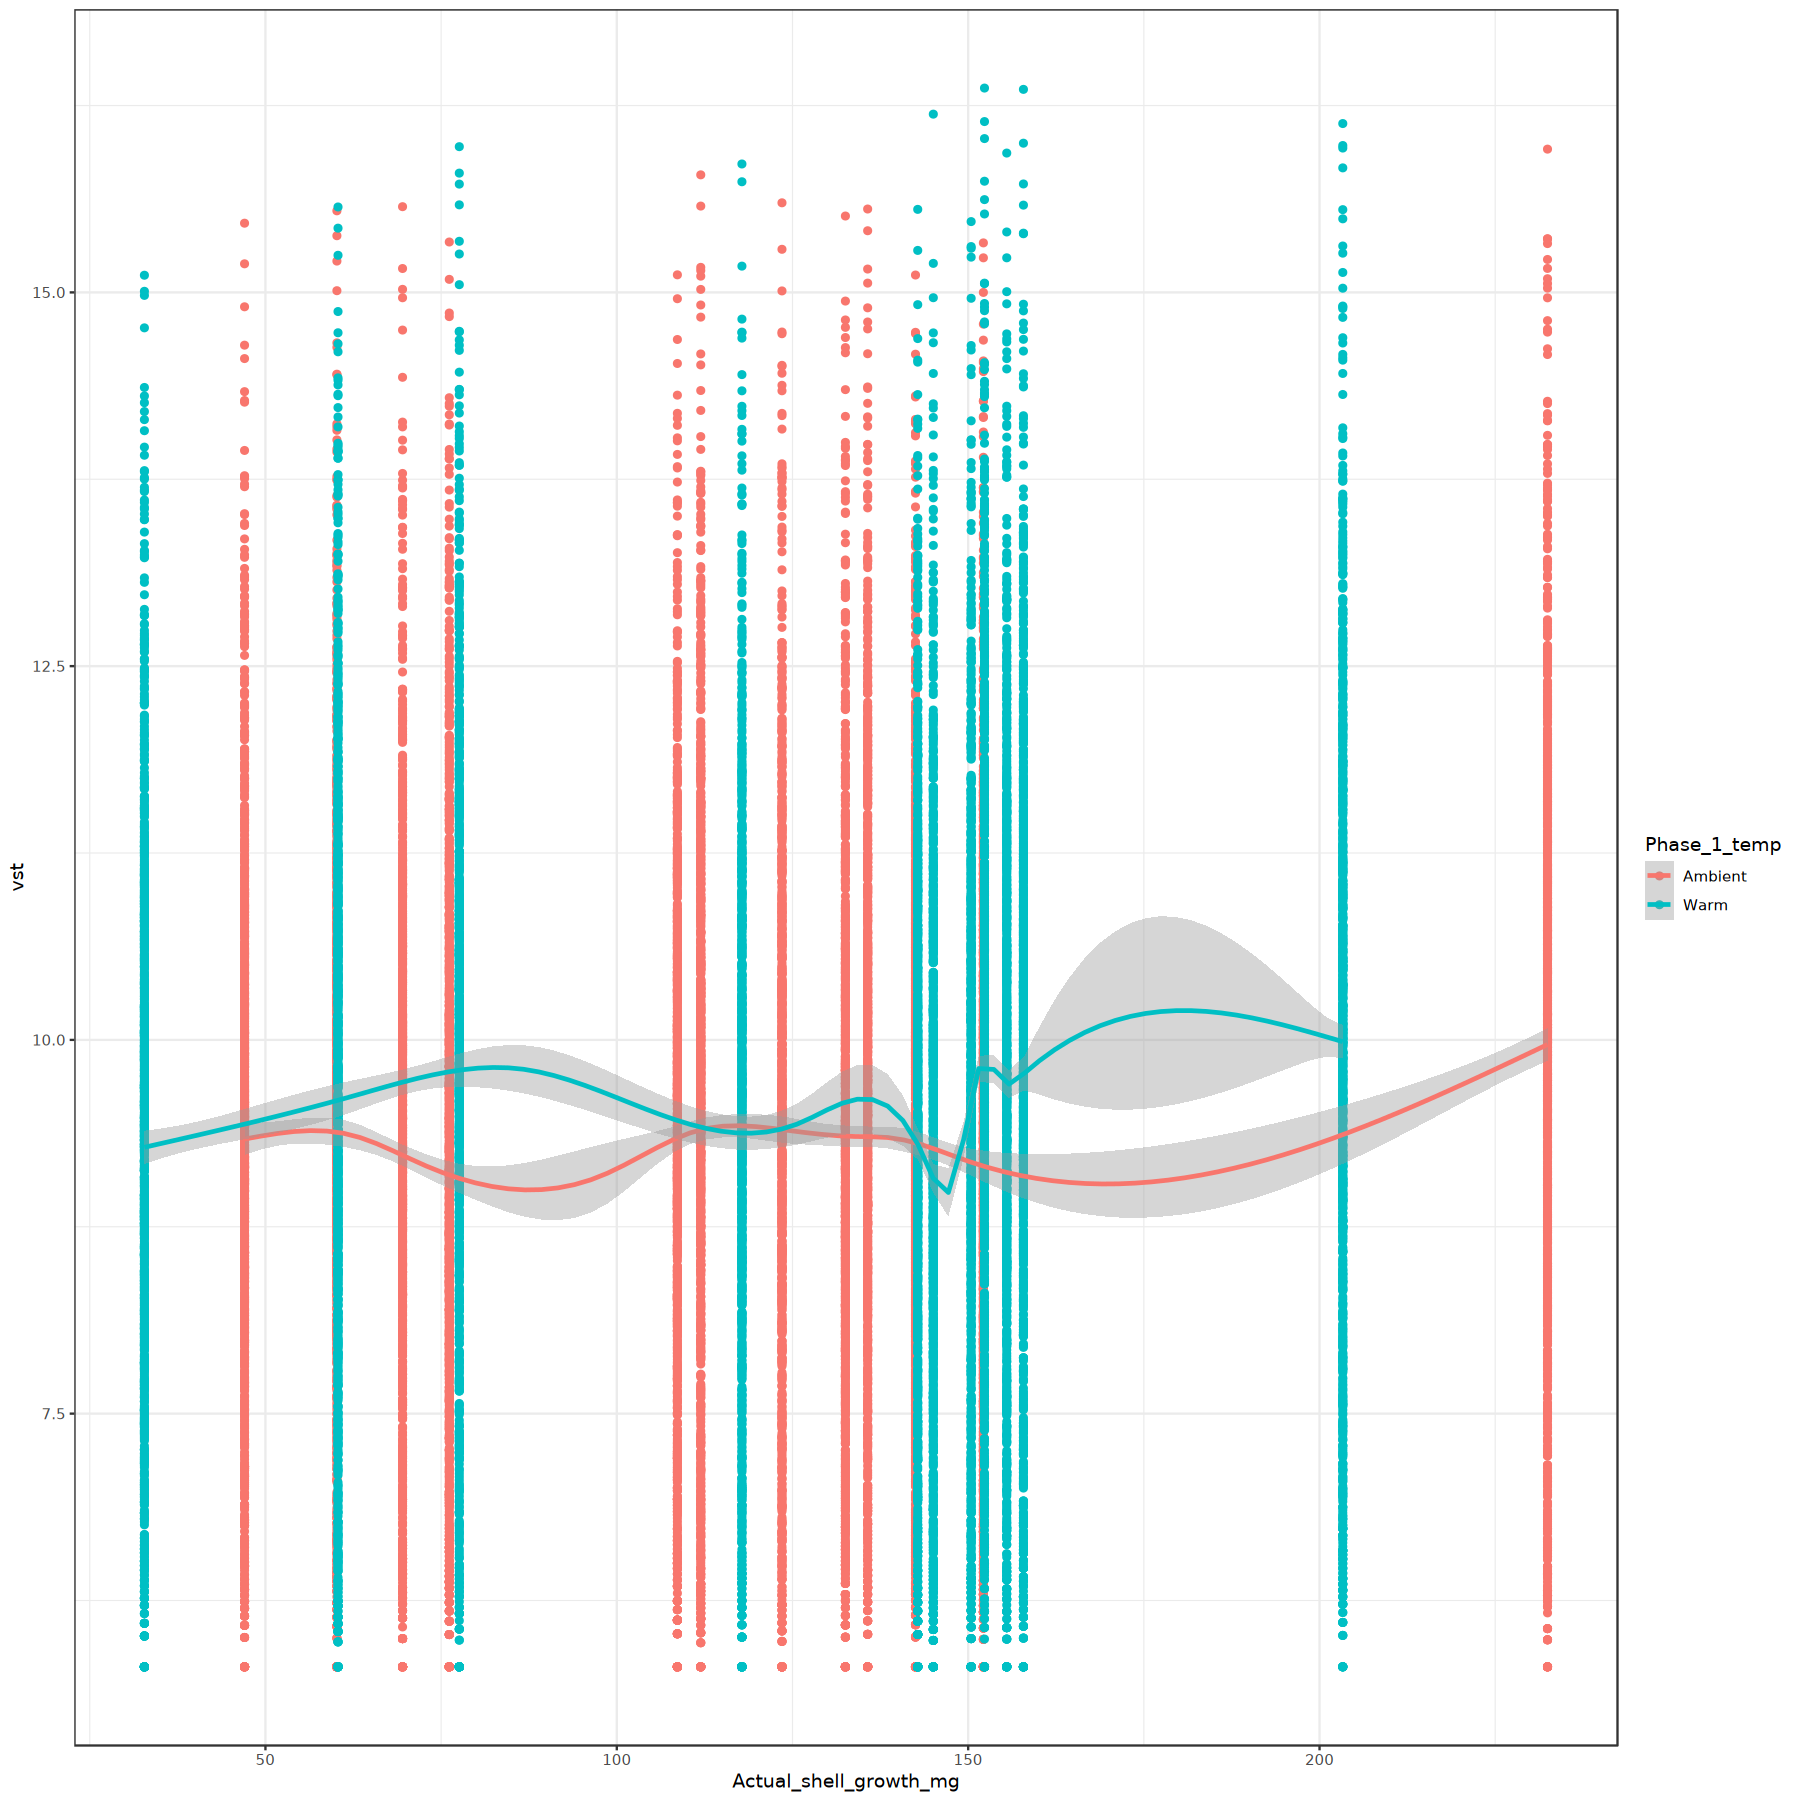

In [41]:
ggplot(blue_vst_growth, aes(x = Actual_shell_growth_mg, y = vst, col = Phase_1_temp)) +
geom_point() +
geom_smooth() +
theme_bw()

#### hub gene: LOC111118049
[LOC111118049](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111118049): eukaryotic translation initiation factor 2 subunit 1-like 
- enables RNA binding, ribosome binding, translation initiation factory activity
- involved in translational initiation

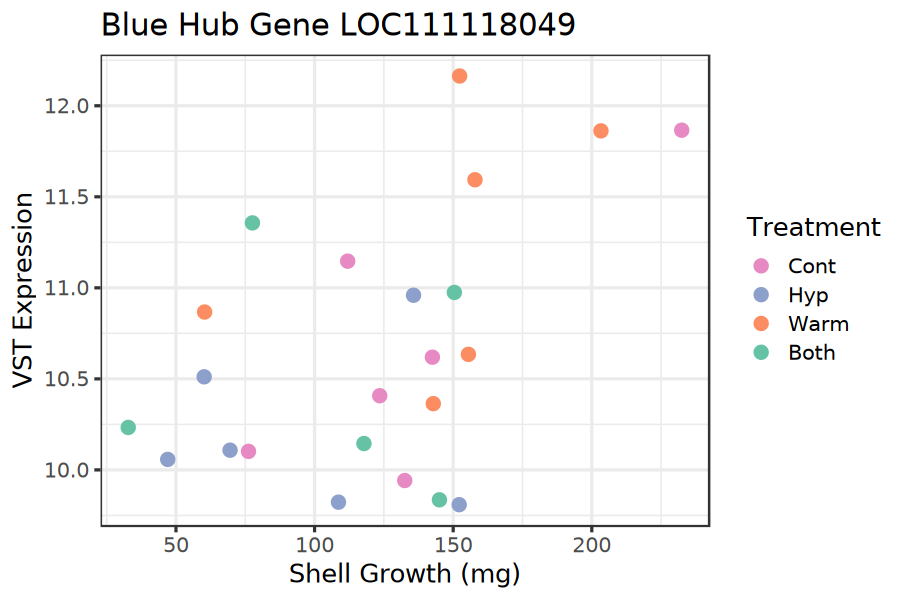

In [42]:
options(repr.plot.width = 7.5, repr.plot.height = 5)

blue_hubGene <- blue_vst_growth %>% filter(Gene == 'LOC111118049')

ggplot(blue_hubGene, aes(x = vst, y = Actual_shell_growth_mg, col = Phase_1_treat)) +
geom_point(size = 3) +
scale_color_brewer(palette = 'Set2', direction = -1) +
labs(x = 'VST Expression',
     y = 'Shell Growth (mg)',
     col = 'Treatment',
     title = 'Blue Hub Gene LOC111118049') +
coord_flip() +
theme_bw(base_size = 15)

it does appear that higher expression of this gene does correlate with increased shell growth

#### GS heatmap

but first, need to look at the correlation between treatment and shell growth - because if there is a correlation, then the traits are confounding

In [43]:
growth$temp_binary <- ifelse(growth$Phase_1_treat == "Warm", 1, 0)
cor.test(growth$Actual_shell_growth_mg, growth$temp_binary)


	Pearson's product-moment correlation

data:  growth$Actual_shell_growth_mg and growth$temp_binary
t = 1.4217, df = 21, p-value = 0.1698
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1320101  0.6313979
sample estimates:
     cor 
0.296316 


so appears that there is no significant correlation between shell growth and warm treatment

just want to check out if there is a significant effect of treatment on growth

In [44]:
summary(aov(Actual_shell_growth_mg ~ Phase_1_temp * Phase_1_DO, data = growth))

                        Df Sum Sq Mean Sq F value Pr(>F)  
Phase_1_temp             1    677     677   0.295 0.5934  
Phase_1_DO               1   9541    9541   4.154 0.0557 .
Phase_1_temp:Phase_1_DO  1      0       0   0.000 0.9931  
Residuals               19  43642    2297                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

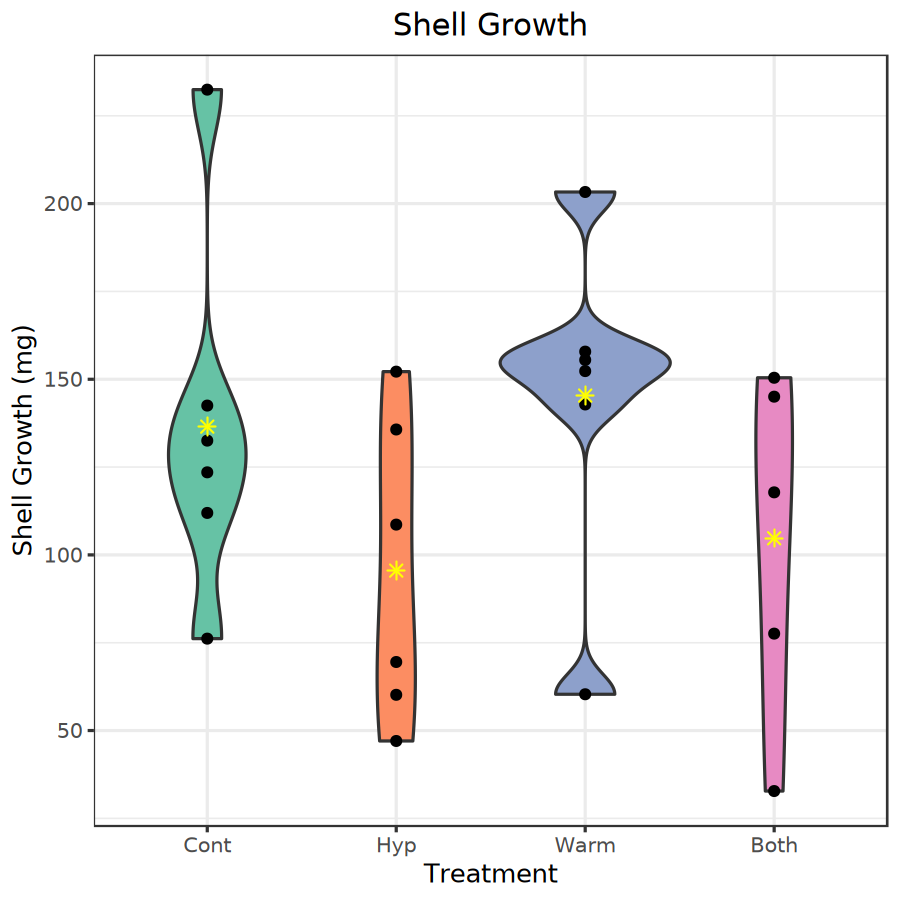

In [45]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

growth$Phase_1_treat <- factor(growth$Phase_1_treat, levels = c('Cont', 'Hyp', 'Warm', 'Both'))

shell_growth <- ggplot(growth, aes(x = Phase_1_treat, y = Actual_shell_growth_mg, fill = Phase_1_treat)) +
geom_violin() +
geom_point() +
stat_summary(
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
scale_fill_brewer(palette = 'Set2') +
guides(fill = 'none') +
labs(x = 'Treatment',
     y = 'Shell Growth (mg)',
    title = 'Shell Growth') +
theme_bw(base_size = 15) +
theme(plot.title = element_text(hjust = 0.5))

shell_growth

so it does look like the warming treatment for these oysters do have increased shell growth (more consistently/more of the replicates have higher growth) than the other treatments - but this is not a significant difference

need to pull out gene significance for shell growth and temperature treatment

In [46]:
blue_gs <- geneInfo %>% 
dplyr::select(Gene, GO.terms, ModuleColor, GS.Actual_shell_growth_mg, GS.warm, p.GS.GS.Actual_shell_growth_mg, p.GS.GS.warm) %>%
filter(ModuleColor == 'blue')

head(blue_gs)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.warm,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.warm
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,0.39966747,0.31929640,0.05882963,0.137519691
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.44340350,0.29305474,0.03407378,0.174755141
3,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.43025668,0.51665255,0.04043220,0.011597196
4,LOC111099056,GO:0003723;GO:0006396;GO:0008173,blue,0.04069859,0.05234405,0.85371948,0.812504555
5,LOC111099067,GO:0000463;GO:0005634;GO:0008650;GO:0030687;GO:0031167,blue,0.33300808,0.38777609,0.12049730,0.067505091
6,LOC111099690,GO:0009226;GO:0050577,blue,0.46954235,0.53354451,0.02378955,0.008743777


gene significance = correlation (-1:1), strength and direction, between trait and that gene

the corresponding pvalue tells you how likely you'd obverse a correlation that large by chance alone

I want to make a df that pulls genes, and determines if they're temp-associated (warm pval < 0.05), growth-associated (growth pval < 0.05), both, or neither (and therefore a module member only)

In [47]:
blue_gs2 <- blue_gs %>%
mutate(geneClass = case_when(
    p.GS.GS.Actual_shell_growth_mg < 0.05 & p.GS.GS.warm > 0.05 ~ 'Growth',
    p.GS.GS.Actual_shell_growth_mg > 0.05 & p.GS.GS.warm < 0.05 ~ 'Warm',
    p.GS.GS.Actual_shell_growth_mg > 0.05 & p.GS.GS.warm > 0.05 ~ 'Neither',
    p.GS.GS.Actual_shell_growth_mg < 0.05 & p.GS.GS.warm < 0.05 ~ 'Both'))

head(blue_gs2)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.warm,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.warm,geneClass
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,0.39966747,0.31929640,0.05882963,0.137519691,Neither
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.44340350,0.29305474,0.03407378,0.174755141,Growth
3,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,0.43025668,0.51665255,0.04043220,0.011597196,Both
4,LOC111099056,GO:0003723;GO:0006396;GO:0008173,blue,0.04069859,0.05234405,0.85371948,0.812504555,Neither
5,LOC111099067,GO:0000463;GO:0005634;GO:0008650;GO:0030687;GO:0031167,blue,0.33300808,0.38777609,0.12049730,0.067505091,Neither
6,LOC111099690,GO:0009226;GO:0050577,blue,0.46954235,0.53354451,0.02378955,0.008743777,Both


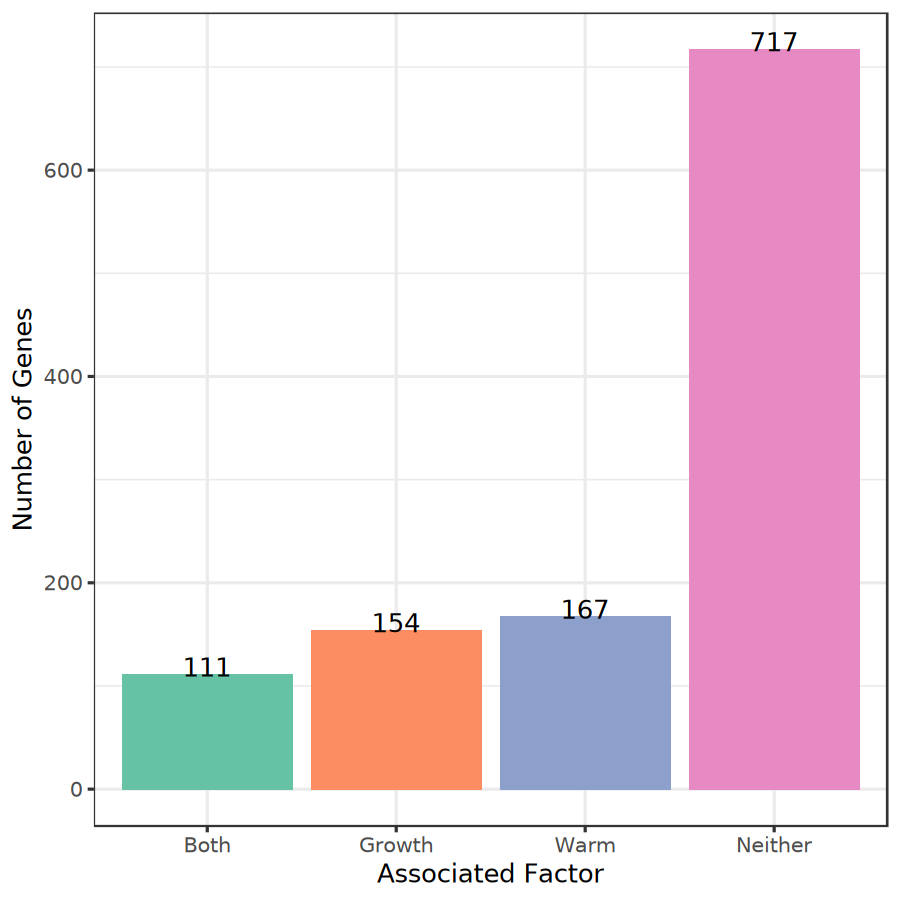

In [48]:
blue_gs2$geneClass <- factor(blue_gs2$geneClass, levels = c('Both', 'Growth', 'Warm', 'Neither'))

ggplot(blue_gs2, aes(x = geneClass, fill = geneClass)) +
geom_bar() +
geom_text(
    stat = "count", 
    aes(label = after_stat(count)),
    vjust = 0.1
  ) +
scale_fill_brewer(palette = 'Set2') +
guides(fill = 'none') +
labs(x = 'Associated Factor',
     y = 'Number of Genes') +
theme_bw(base_size = 15)

interesting - so the majority of the genes in the blue module are not significantly correlated with the temperature treatment/shell growth, but are instead just members of the module (not sure how that works? it's just that they're connected in the network? and so they're not drivers of the module relationship?)

but we see genes separate into those that are associated with only the warm treatment, only shell growth, and those associated with both shell growth and the warm treatment

should plot heatmap of GS correlations for these and pull out each of the gene classes and look at what they're enriched for 

In [49]:
blue.matrix <- blue_gs2 %>% dplyr::select(Gene, GS.Actual_shell_growth_mg, GS.warm) %>% column_to_rownames('Gene')
head(blue.matrix)

,GS.Actual_shell_growth_mg,GS.warm
,<dbl>,<dbl>
LOC111099029,0.39966747,0.31929640
LOC111099039,0.44340350,0.29305474
LOC111099053,0.43025668,0.51665255
LOC111099056,0.04069859,0.05234405
LOC111099067,0.33300808,0.38777609
LOC111099690,0.46954235,0.53354451


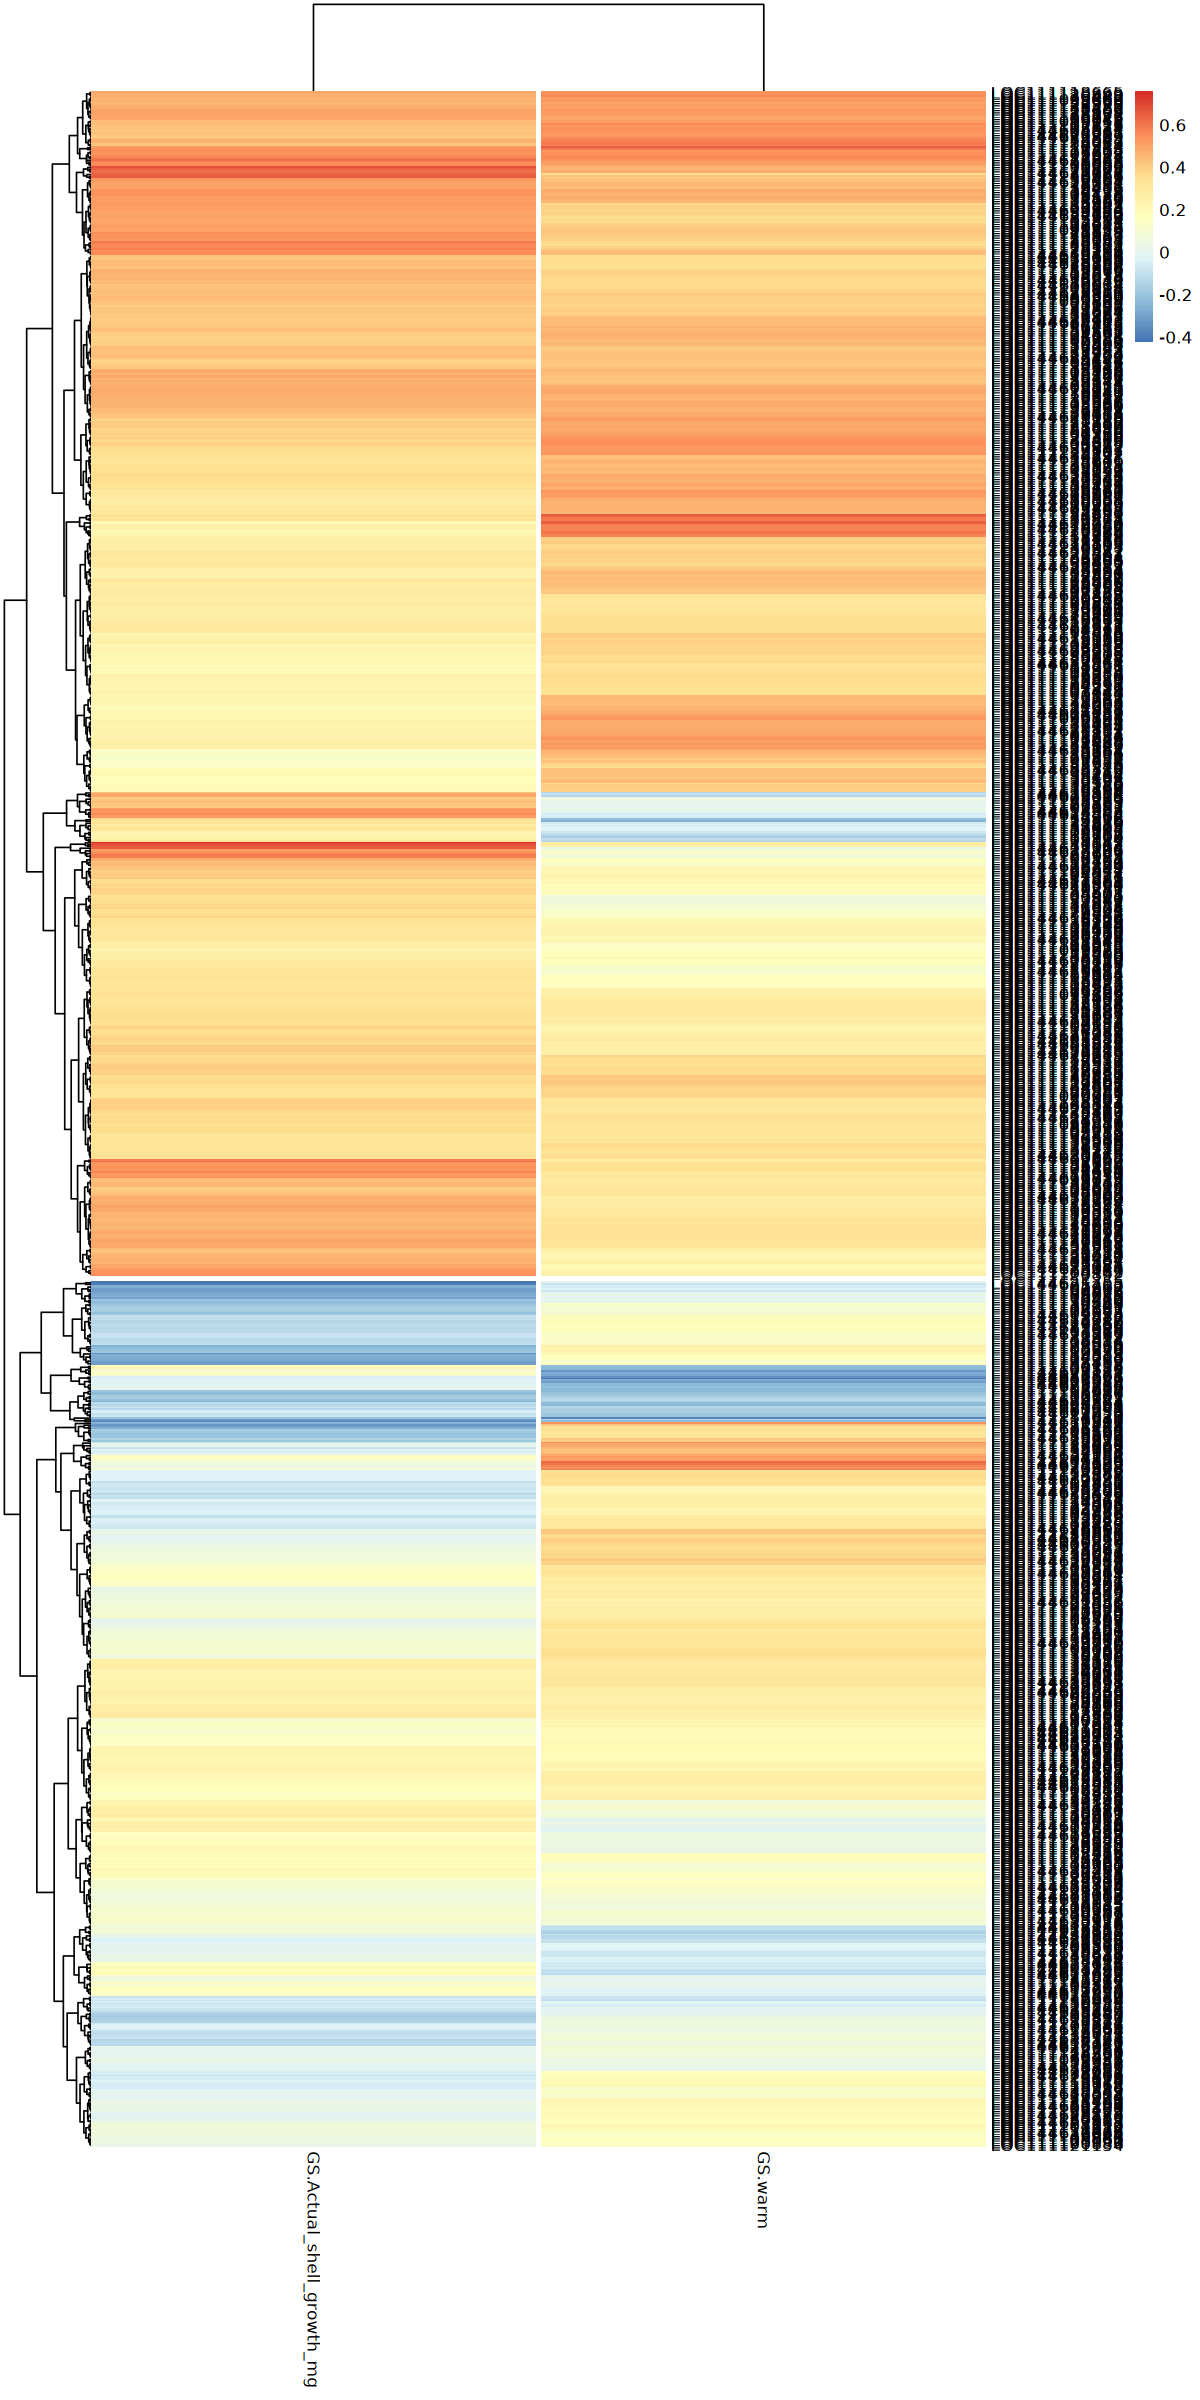

In [50]:
options(repr.plot.height = 20, repr.plot.width = 10)

pheatmap(blue.matrix,
         cutree_rows = 2, 
         cutree_cols = 2
        )

would probably be interesting to pull the genes that have opposing patterns for shell growth and warm treatment - those that are dark blue for one factor and dark red for another

looks like there's a similar group of genes that drive the positive correlation between the module and the traits (especially the top portion with red genes)

but then there's a group of genes that have lower expression with increased shell growth, but continue to have higher expression in the warm treatments - what could this mean???? maybe that's why we don't see a correlation between warm and increased shell growth, bc the continued expression of these genes offsets effects of warming? 

Sarah and Teresa want to see a heatmap of expression specifically - so instead of the gene significance correlation, they want to see the correlation of gene expression with shell growth and warm treatment

although thinking this through, I still don't think you can show raw GE for shell at least, because the samples are the same for shell growth and treatment - so you would be asking what the correlation between shell growth and GE is and therefore not plotting raw GE again

#### vst heatmap
plotting heatmap of raw GE of the blue module genes in each sample

In [51]:
rownames(blue_vst) <- NULL

In [52]:
# vst matrix
# rows = samples
# genes = columns
blue_vst.matrix <- blue_vst %>%
column_to_rownames('X') 

dim(blue_vst.matrix)
head(blue_vst.matrix)

[1] 1149   23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111103350,9.010443,7.060082,9.039641,8.195446,8.614067,8.272462,7.617818,6.980232,7.958207,7.998809,⋯,10.565649,6.995920,7.781420,8.054730,8.179476,11.039693,8.958540,8.397802,7.278678,7.435651
LOC111103667,10.683765,10.159731,10.098630,9.894236,9.931693,11.179419,10.514259,9.775269,10.156670,10.821178,⋯,10.240149,10.053264,10.341467,9.888592,10.469400,11.013350,10.880907,10.334288,10.804500,10.057273
LOC144621561,5.806396,7.189715,6.996165,6.594821,7.210938,6.762428,5.806396,5.806396,7.353748,6.804587,⋯,7.280236,6.597423,6.422614,5.806396,6.734561,7.946745,6.866035,6.948629,6.611047,7.258738
LOC144621743,7.357536,8.691806,7.834363,7.154715,9.660346,7.920388,7.843740,7.311516,8.192720,8.781426,⋯,8.776053,7.634487,8.043508,8.268182,8.363767,8.874120,7.507840,8.533109,8.014646,8.273622
LOC144619181,5.984862,6.834983,7.096549,6.265342,5.806396,11.116238,6.461914,5.806396,5.806396,6.127722,⋯,11.749544,5.806396,9.531418,5.806396,5.806396,12.013272,6.978286,6.176098,7.224374,9.446437
LOC111105167,8.196331,7.189715,5.806396,7.503663,6.982631,6.660921,5.806396,5.806396,7.421640,6.978656,⋯,6.849611,5.806396,7.040880,5.806396,6.888116,6.947474,8.036163,6.717943,5.998381,6.237491


In [53]:
annotation <- growth %>%
  dplyr::select(Sample, Phase_1_treat) %>%
  column_to_rownames("Sample") 

annotation_colors <- list(
  Phase_1_treat = c(
    Cont = "burlywood3",
    Warm = "palevioletred",
      Hyp = 'steelblue3',
      Both = 'plum3'
  )
)

head(annotation)
head(annotation_colors)

,Phase_1_treat
,<fct>
B1_Nu_O03,Both
B2_Nu_O12,Both
B4_Nu_O32,Both
B5_Nu_O36,Both
B6_Nu_O47,Both
C1_Nu_W01,Cont


$Phase_1_treat
           Cont            Warm             Hyp            Both 
   "burlywood3" "palevioletred"    "steelblue3"         "plum3"

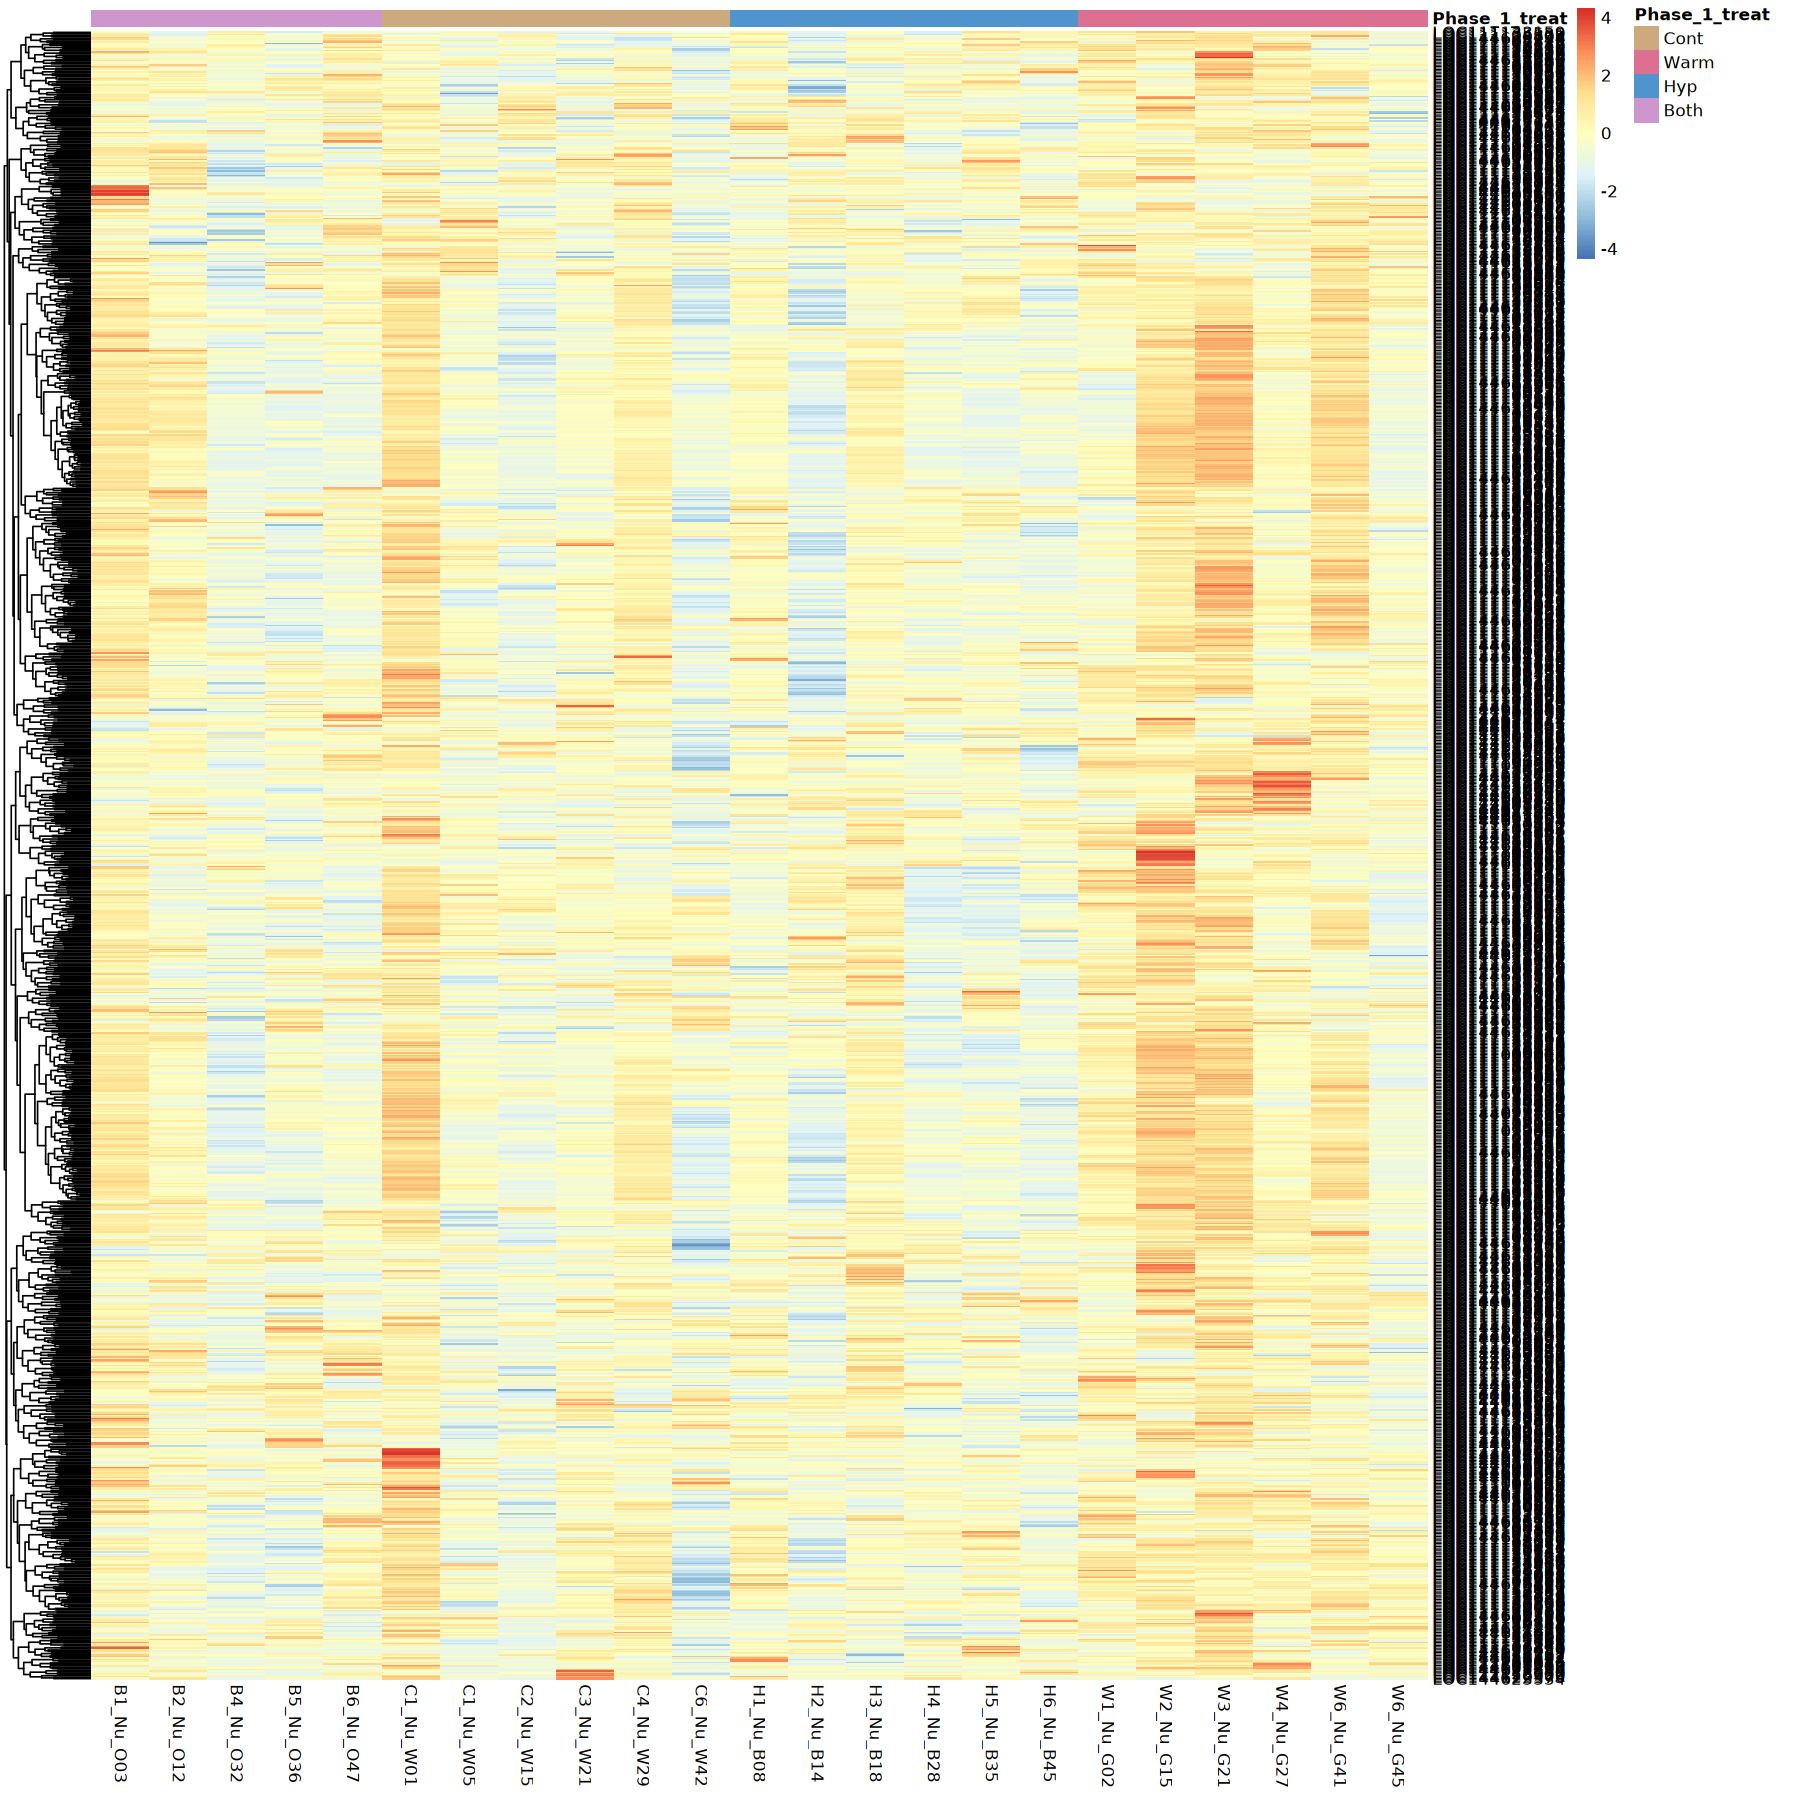

In [54]:
options(repr.plot.width = 15, repr.plot.height = 15)

pheatmap(blue_vst.matrix,
        cluster_cols = FALSE,
        annotation_col = annotation,
        annotation_colors = annotation_colors,
        # cutree_rows = 5, 
         #cutree_cols = 4,
         scale = 'row' # standardizes each gene separately across samples
        ) 

it looks like the warm treatment oysters have consistently higher expression of this set of genes compared to the other treatments

below: let the heatmap cluster similar samples

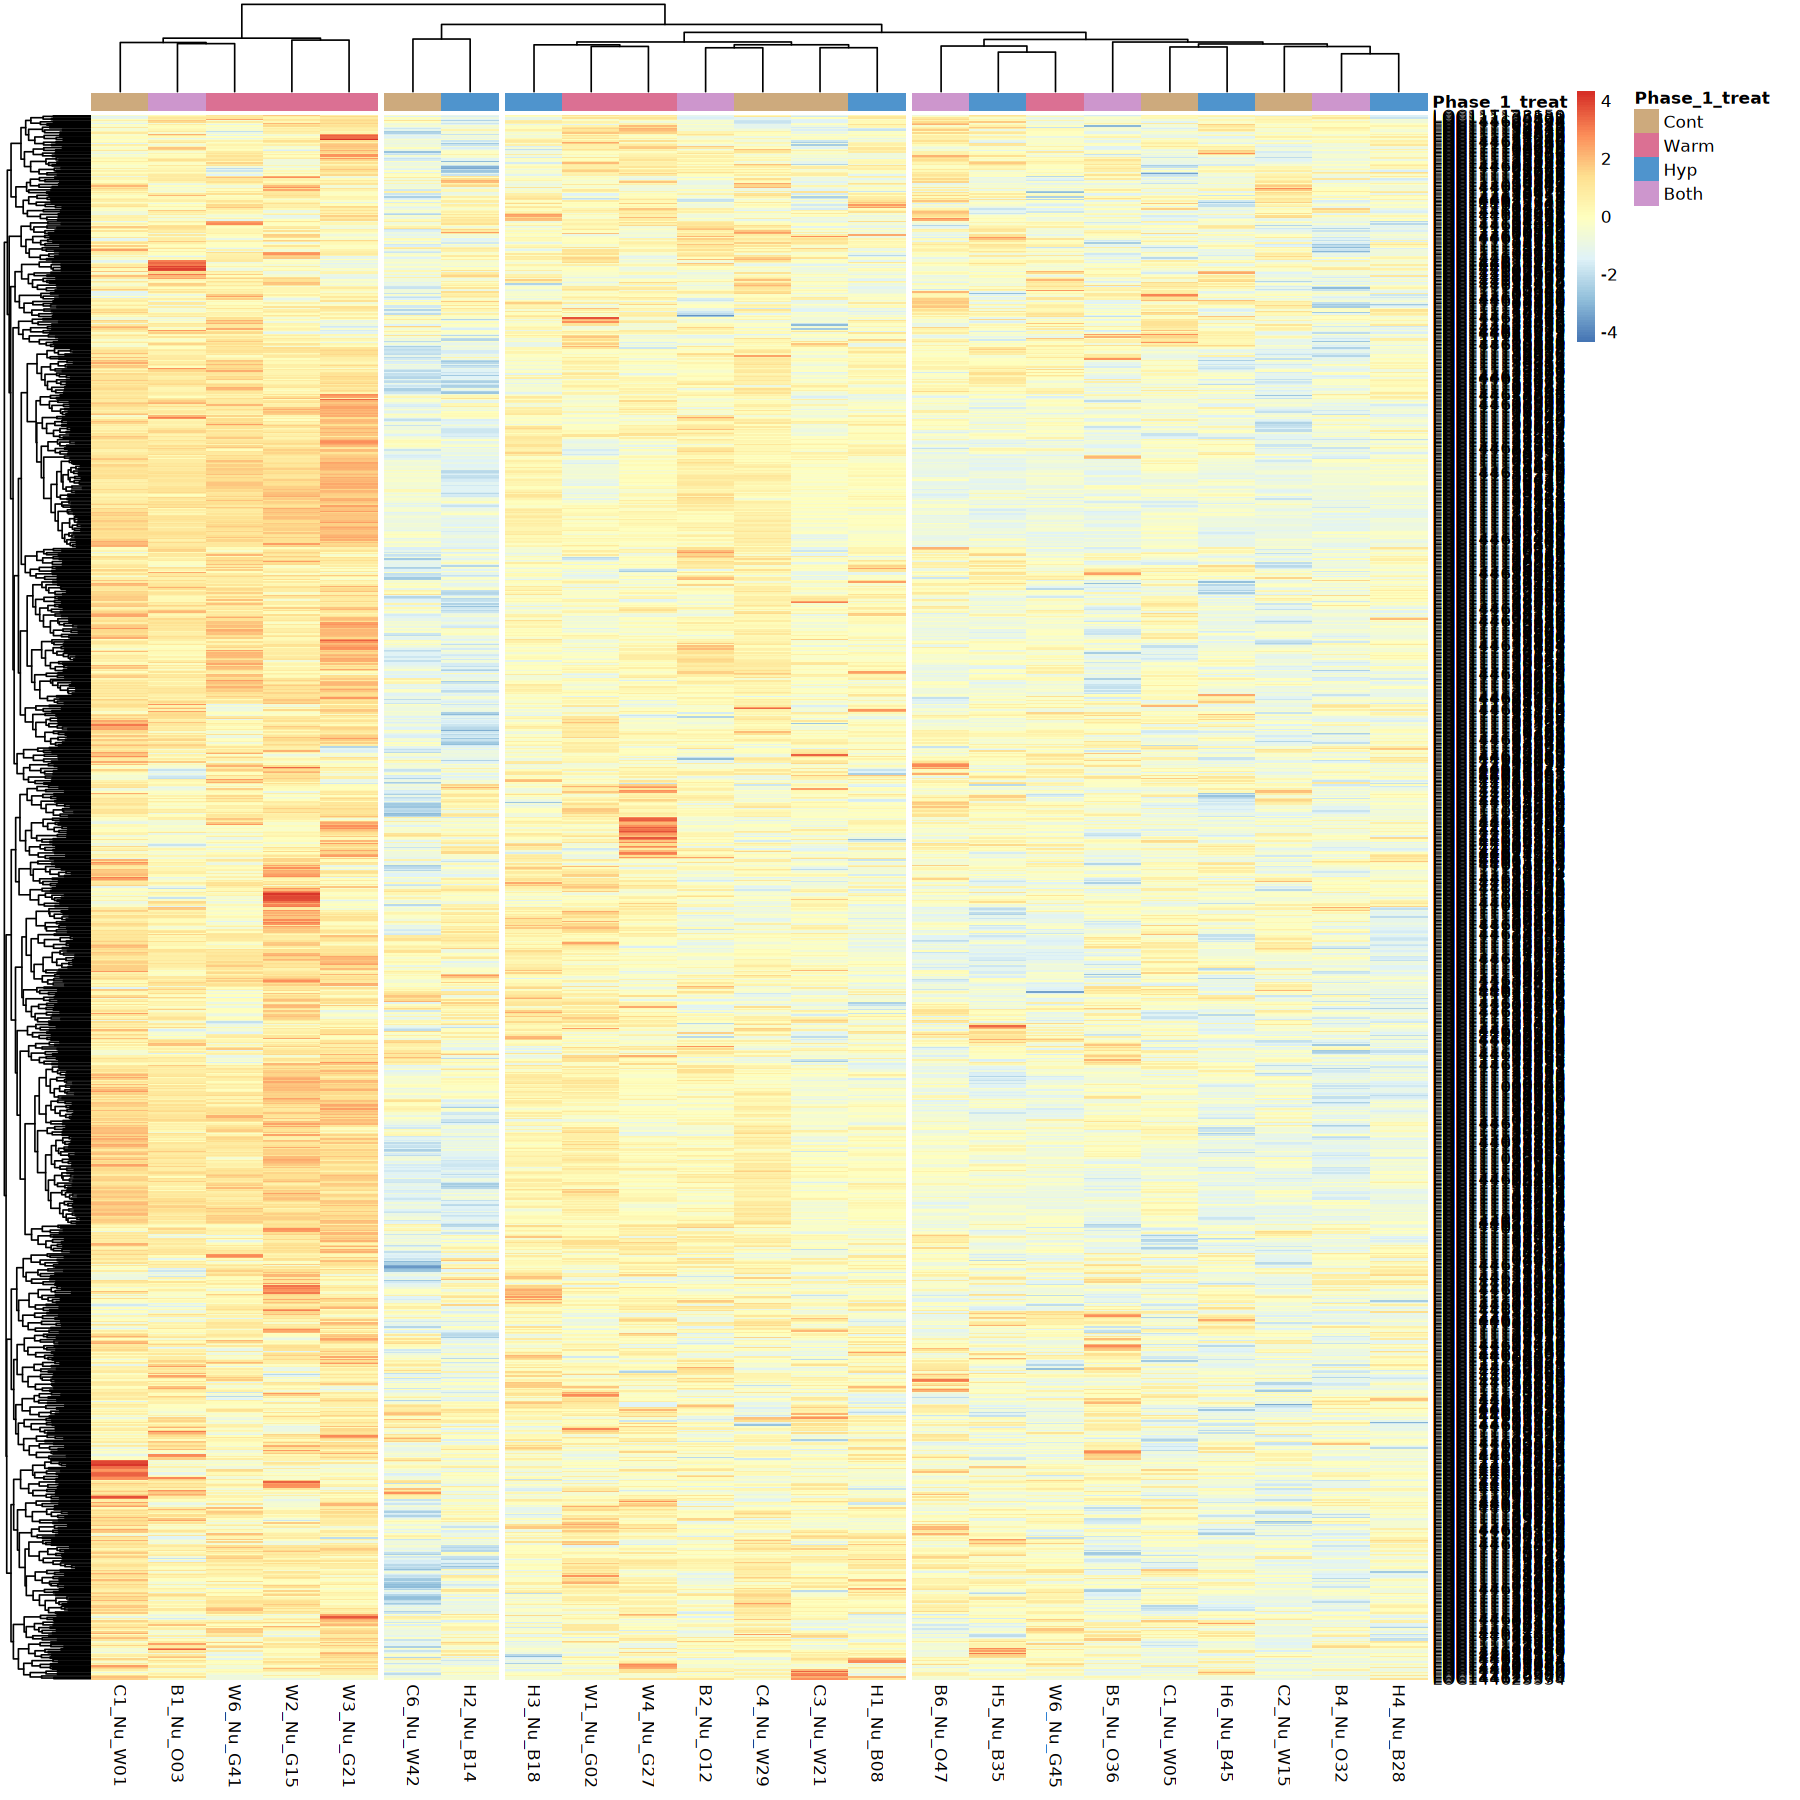

In [55]:
options(repr.plot.width = 15, repr.plot.height = 15)

pheatmap(blue_vst.matrix,
        #cluster_cols = FALSE,
        annotation_col = annotation,
        annotation_colors = annotation_colors,
        # cutree_rows = 5, 
        cutree_cols = 4,
        scale = 'row' # standardizes each gene separately across samples
        ) 

now plotting this for growth - sorting the samples by growth and then showing expression for individuals

In [56]:
ordered_growth <- growth[order(growth$Actual_shell_growth_mg), ]
head(ordered_growth)

,Sample,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,temp_binary
,<chr>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
4,B5_Nu_O36,Both,Warm,Hyp,25.22362,32.77638,0.769566987,0
16,H5_Nu_B35,Hyp,Ambient,Hyp,15.37302,47.02698,0.326897879,0
12,H1_Nu_B08,Hyp,Ambient,Hyp,47.03080,60.16920,0.781642435,0
18,W1_Nu_G02,Warm,Warm,Norm,46.77246,60.32754,0.77530859,1
15,H4_Nu_B28,Hyp,Ambient,Hyp,59.08874,69.51126,0.850059976,0
11,C6_Nu_W42,Cont,Ambient,Norm,32.03846,76.16154,0.420664551,0


In [57]:
ordered_blue_vst.matrix <- blue_vst.matrix[,ordered_growth$Sample]
head(ordered_blue_vst.matrix)

,B5_Nu_O36,H5_Nu_B35,H1_Nu_B08,W1_Nu_G02,H4_Nu_B28,C6_Nu_W42,B1_Nu_O03,H6_Nu_B45,C4_Nu_W29,B6_Nu_O47,⋯,C1_Nu_W05,W6_Nu_G45,B4_Nu_O32,B2_Nu_O12,H2_Nu_B14,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W2_Nu_G15,C1_Nu_W01
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111103350,8.195446,7.781420,7.995713,8.179476,6.995920,8.182735,9.010443,8.054730,7.998809,8.614067,⋯,7.617818,7.435651,9.039641,7.060082,7.239293,8.958540,8.397802,7.278678,11.039693,8.272462
LOC111103667,9.894236,10.341467,10.343953,10.469400,10.053264,9.930053,10.683765,9.888592,10.821178,9.931693,⋯,10.514259,10.057273,10.098630,10.159731,9.782433,10.880907,10.334288,10.804500,11.013350,11.179419
LOC144621561,6.594821,6.422614,5.806396,6.734561,6.597423,6.236796,5.806396,5.806396,6.804587,7.210938,⋯,5.806396,7.258738,6.996165,7.189715,6.323257,6.866035,6.948629,6.611047,7.946745,6.762428
LOC144621743,7.154715,8.043508,6.311743,8.363767,7.634487,7.853997,7.357536,8.268182,8.781426,9.660346,⋯,7.843740,8.273622,7.834363,8.691806,7.041188,7.507840,8.533109,8.014646,8.874120,7.920388
LOC144619181,6.265342,9.531418,6.077500,5.806396,5.806396,5.806396,5.984862,5.806396,6.127722,5.806396,⋯,6.461914,9.446437,7.096549,6.834983,6.437760,6.978286,6.176098,7.224374,12.013272,11.116238
LOC111105167,7.503663,7.040880,5.806396,6.888116,5.806396,7.335674,8.196331,5.806396,6.978656,6.982631,⋯,5.806396,6.237491,5.806396,7.189715,5.806396,8.036163,6.717943,5.998381,6.947474,6.660921


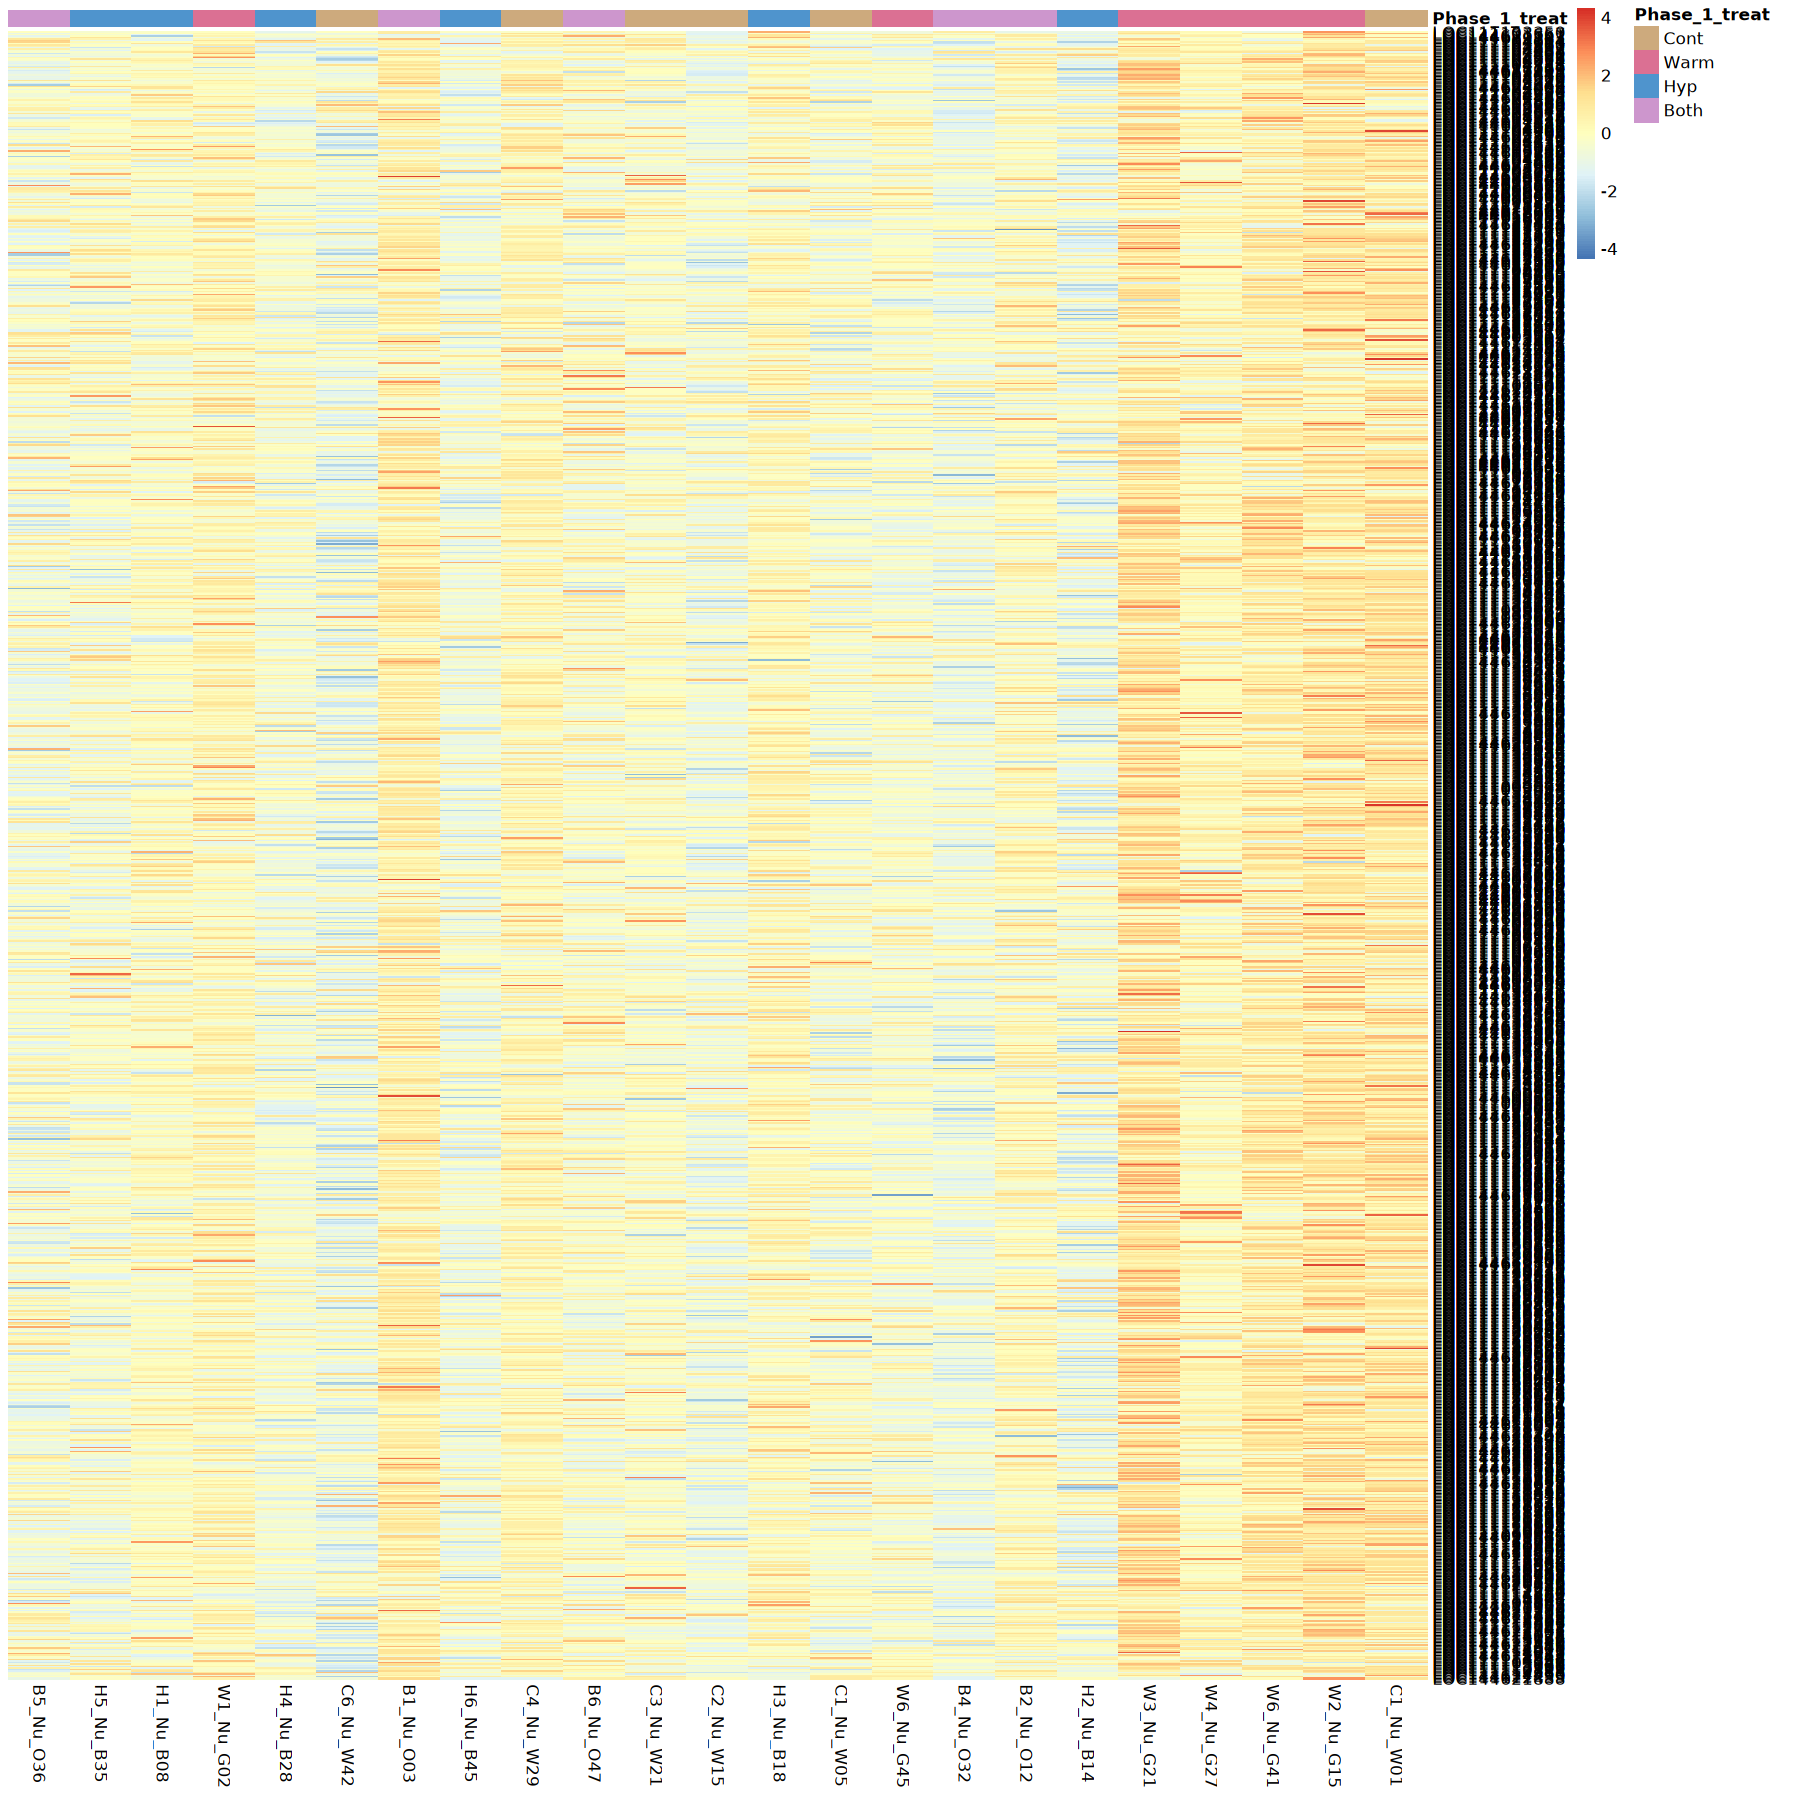

In [58]:
options(repr.plot.width = 15, repr.plot.height = 15)

pheatmap(ordered_blue_vst.matrix, 
          annotation_col = annotation,
        annotation_colors = annotation_colors,
         cluster_rows = FALSE, 
         cluster_cols = FALSE,
         scale = 'row' # standardizes each gene separately across samples
)

the left of the heatmap have lower shell growth, the right of the heatmap have higher shell growth

we do see that the majority of the samples with higher shell growth are the warm samples - so again, suggests possible confounding relationship here (but this is interesting because I thought control oysters have the most shell growth out of all of the treatments - altough I plotted it like Sophie where the point is the average and the bars is the standard error)

#### growth associated genes

based on the plots above, pulling out the genes associated with growth and plotting the VST expression against growth

In [59]:
growth_blue <- blue_gs2 %>%
filter(geneClass == 'Growth')

dim(growth_blue)
head(growth_blue)

[1] 154   8

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.warm,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.warm,geneClass
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,0.4434035,0.293054735,0.03407378,0.17475514,Growth
2,LOC111099808,GO:0005730;GO:0005737;GO:0006364;GO:0030515;GO:0030688,blue,0.4388059,0.404216738,0.03620038,0.05574759,Growth
3,LOC111100042,GO:0003746;GO:0003924;GO:0005525;GO:0005739;GO:0070125,blue,0.5140391,0.409536199,0.01210021,0.05230340,Growth
4,LOC111100187,GO:0016791,blue,0.4885881,0.177150056,0.01799983,0.41872843,Growth
5,LOC111103461,GO:0005737;GO:0006446;GO:0140469,blue,0.4262199,0.006394372,0.04256076,0.97689940,Growth
6,LOC111103502,GO:0030336;GO:0070822,blue,0.4654024,0.255183780,0.02522692,0.23993393,Growth


In [60]:
write.csv(growth_blue, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/moduleGenes/blueModGenes_shellGrowth.csv')

In [61]:
# vst for red genes
growth_blue.vst <- vst[vst$X %in% growth_blue$Gene,]

dim(growth_blue.vst)
head(growth_blue.vst)

[1] 154  24

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
48,LOC111103667,10.683765,10.159731,10.098630,9.894236,9.931693,11.179419,10.514259,9.775269,10.156670,⋯,10.240149,10.053264,10.341467,9.888592,10.469400,11.013350,10.880907,10.334288,10.804500,10.057273
53,LOC144621561,5.806396,7.189715,6.996165,6.594821,7.210938,6.762428,5.806396,5.806396,7.353748,⋯,7.280236,6.597423,6.422614,5.806396,6.734561,7.946745,6.866035,6.948629,6.611047,7.258738
146,LOC144619181,5.984862,6.834983,7.096549,6.265342,5.806396,11.116238,6.461914,5.806396,5.806396,⋯,11.749544,5.806396,9.531418,5.806396,5.806396,12.013272,6.978286,6.176098,7.224374,9.446437
225,LOC111103502,11.700147,10.736952,11.110010,10.695043,11.265381,12.256850,12.478580,11.452670,11.855261,⋯,12.725921,10.708294,10.325209,11.224593,12.331046,11.996568,11.668517,11.456402,11.555032,11.190396
262,LOC111104038,10.509486,9.920636,9.222650,9.830271,10.190310,11.050758,9.686566,9.821720,10.125787,⋯,10.402606,9.597827,9.342614,9.709018,10.510050,11.027405,10.692797,10.327030,10.379714,9.438557
333,LOC111104074,9.912238,9.590930,9.707956,9.676980,9.567977,10.598422,9.968794,9.712721,10.201305,⋯,9.654284,9.839797,9.432538,9.163552,9.748946,10.347101,10.305544,9.964795,10.458273,9.046769


In [62]:
# convert vst to long format
growth_blue.vst.long <- growth_blue.vst %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') %>%
rename(Gene = X)

head(growth_blue.vst.long)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC111103667,B1_Nu_O03,10.683765
LOC111103667,B2_Nu_O12,10.159731
LOC111103667,B4_Nu_O32,10.098630
LOC111103667,B5_Nu_O36,9.894236
LOC111103667,B6_Nu_O47,9.931693
LOC111103667,C1_Nu_W01,11.179419


In [63]:
# add growth info
growth_blue_meta <- merge(growth_blue.vst.long, growth, by = 'Sample')
head(growth_blue_meta)

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,temp_binary
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
1,B1_Nu_O03,LOC111103667,10.68377,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
2,B1_Nu_O03,LOC144620634,9.34786,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
3,B1_Nu_O03,LOC111137965,13.41999,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
4,B1_Nu_O03,LOC111130550,10.10030,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
5,B1_Nu_O03,LOC144622290,10.27758,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
6,B1_Nu_O03,LOC111138014,13.52437,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


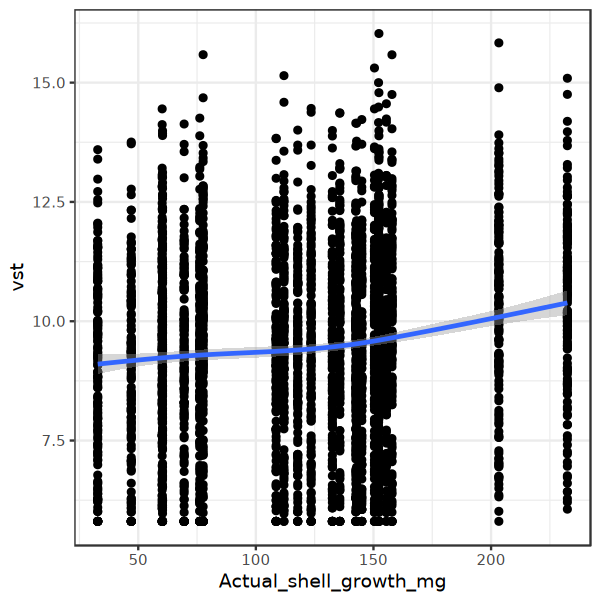

In [64]:
options(repr.plot.height = 5, repr.plot.width = 5)

ggplot(growth_blue_meta, aes(x = Actual_shell_growth_mg, y = vst)) +
geom_point() +
geom_smooth() +
theme_bw()

when considering all of the genes associated with growth in this module, we see a general increase in expression with an increase in shell growth (but it's not super strong)

what if i pull out the top 20 genes with the strongest correlations with growth?

In [65]:
blue_growth.top20 <- growth_blue[order(growth_blue$GS.Actual_shell_growth_mg, decreasing = TRUE),][1:20,]
head(blue_growth.top20)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.warm,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.warm,geneClass
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
24,LOC111111645,GO:0005515;GO:0008270,blue,0.7579268,0.28472201,2.798334e-05,0.18791154,Growth
84,LOC111130112,GO:0000070;GO:0005737;GO:0005828;GO:0007094;GO:0031267;GO:1903394;GO:1990423,blue,0.6957640,0.30876756,2.274619e-04,0.15170835,Growth
109,LOC111135064,GO:0005509;GO:0005874;GO:0010975,blue,0.6687309,0.25801921,4.857048e-04,0.23456999,Growth
154,LOC144627594,GO:0000209;GO:0005515;GO:0043161;GO:0061630,blue,0.6616751,0.03646948,5.848271e-04,0.86878477,Growth
89,LOC111130439,GO:0005814;GO:0060271;GO:0097730,blue,0.6557038,0.40287001,6.818569e-04,0.05664669,Growth
92,LOC111130667,GO:0004333;GO:0005739;GO:0006099;GO:0006106;GO:0006108,blue,0.6462309,0.36544745,8.641299e-04,0.08638590,Growth


In [66]:
# vst for red genes
growth_blue.vst20 <- vst[vst$X %in% blue_growth.top20$Gene,]

# convert vst to long format
growth_blue.vst20.long <- growth_blue.vst20 %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') %>%
rename(Gene = X)

# add growth info
growth_blue_meta.top20 <- merge(growth_blue.vst20.long, growth, by = 'Sample')
head(growth_blue_meta.top20)

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,temp_binary
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
1,B1_Nu_O03,LOC111104993,5.806396,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
2,B1_Nu_O03,LOC111135064,14.682139,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
3,B1_Nu_O03,LOC111120649,10.760729,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
4,B1_Nu_O03,LOC111113171,12.641162,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
5,B1_Nu_O03,LOC111107727,11.070946,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
6,B1_Nu_O03,LOC111118971,12.015847,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


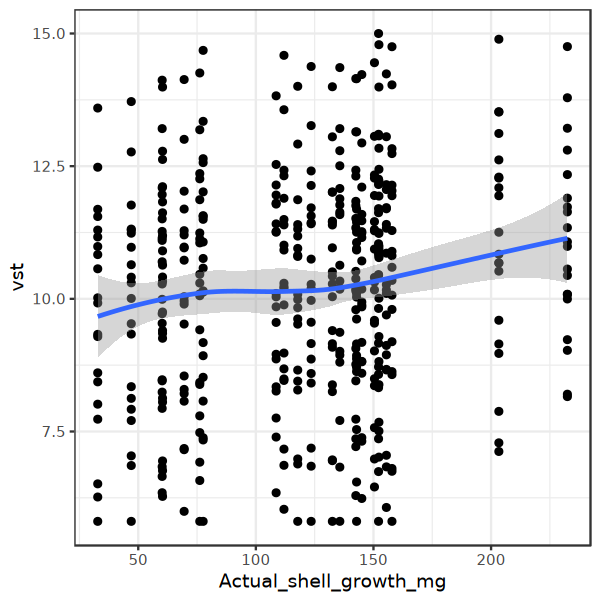

In [67]:
ggplot(growth_blue_meta.top20, aes(x = Actual_shell_growth_mg, y = vst)) +
geom_point() +
geom_smooth() +
theme_bw()

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


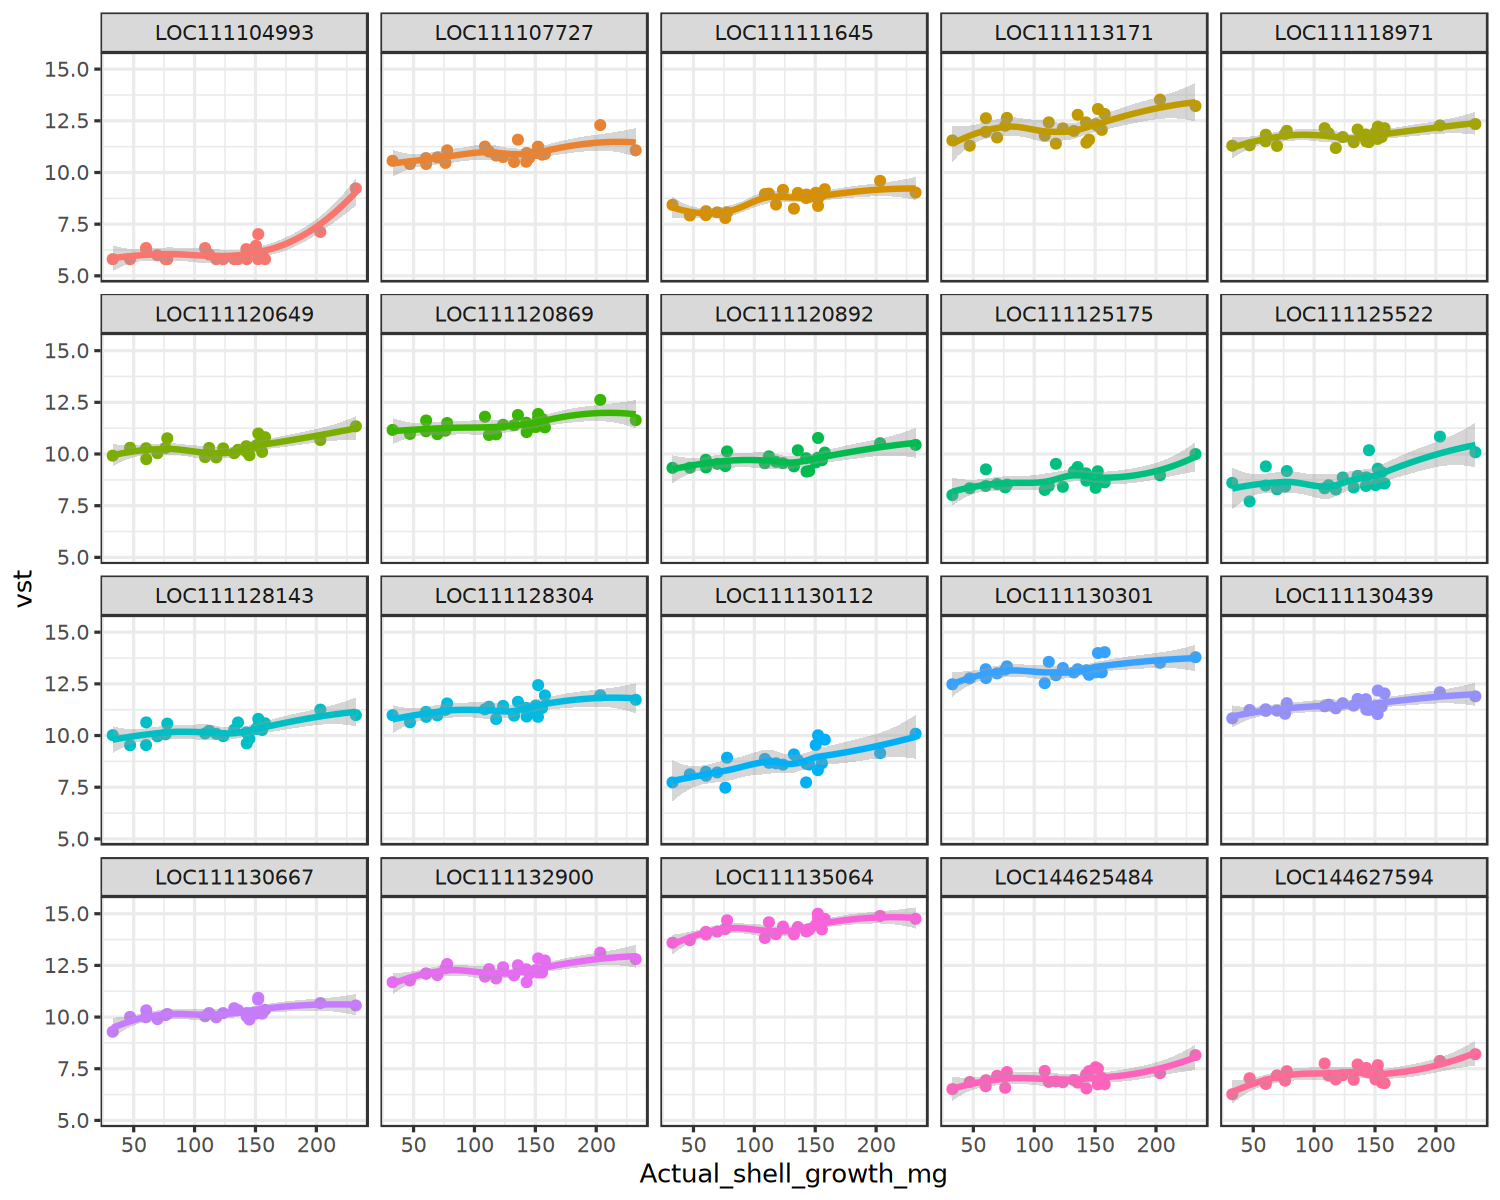

In [68]:
options(repr.plot.height = 10, repr.plot.width = 12.5)

ggplot(growth_blue_meta.top20, aes(x = Actual_shell_growth_mg, y = vst, color = Gene)) +
geom_point() +
geom_smooth() +
guides(color = 'none') +
facet_wrap(~Gene) +
theme_bw(base_size = 15)

so this shows the top 20 genes with the highest gene significance (GS) with pvals only significant (p < 0.05) for shell growth (and not the warm treatment)

there doesn't appear to be a super strong correlation between GE and shell growth, although it is positive and linear. It does appear that the outlier growth point tends to have slightly higher expression in some genes - I should probe what these 20 genes are

In [69]:
annot[annot$gene_id %in% growth_blue_meta.top20$Gene, ]

,gene_id,description
,<chr>,<chr>
51078,LOC111104993,uncharacterized LOC111104993
175192,LOC111125522,spliceosome RNA helicase DDX39B-like
490921,LOC144625484,uncharacterized LOC144625484
560519,LOC111113171,protein arginine N-methyltransferase 1-like
632917,LOC111132900,phosphatidylinositol transfer protein alpha isoform-like
826571,LOC144627594,uncharacterized LOC144627594
909122,LOC111107727,"6-phosphofructo-2-kinase/fructose-2,6-bisphosphatase-like"
1000544,LOC111135064,EF-hand domain-containing family member C2-like
1045704,LOC111130301,adenylate kinase 7-like


cool! so not seeing as many uncharacterized genes as I normally do when I pull out gene names

seeing some genes involved in epigenetic changes (methyltransferase) and spliceosome, also growth factor and biogenesis related genes - which would make sense as being involved in growth

#### warm associated genes

based on the plots above, pulling out the genes associated with growth and plotting the VST expression against growth

In [70]:
warm_blue <- blue_gs2 %>%
filter(geneClass == 'Warm')

dim(warm_blue)
head(warm_blue)

[1] 167   8

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.warm,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.warm,geneClass
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,LOC111099696,GO:0000030;GO:0005515;GO:0005783;GO:0035269,blue,0.2148333,0.5257393,0.3249161,0.009980027,Warm
2,LOC111100090,GO:0004366;GO:0006072;GO:0006631;GO:0008654;GO:0019432;GO:0031966,blue,0.2717788,0.4748703,0.2096623,0.022037283,Warm
3,LOC111103234,GO:0005737;GO:0005743;GO:0006744;GO:0008289;GO:0055105,blue,0.2891452,0.4321220,0.1808460,0.039477320,Warm
4,LOC111103394,GO:0005524;GO:0005858;GO:0007018;GO:0008569;GO:0016887;GO:0045505;GO:0051959,blue,0.2582991,0.4509006,0.2340447,0.030819208,Warm
5,LOC111103594,GO:0005515;GO:0005929;GO:0060271,blue,0.3041689,0.5176305,0.1582185,0.011413442,Warm
6,LOC111103620,GO:0000027;GO:0000463;GO:0005730;GO:0019843,blue,0.3127458,0.4508741,0.1462310,0.030830273,Warm


In [71]:
write.csv(warm_blue, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/moduleGenes/blueModGenes_warmTreat.csv')

In [72]:
# vst for red genes
warm_blue.vst <- vst[vst$X %in% warm_blue$Gene,]

dim(warm_blue.vst)
head(warm_blue.vst)

[1] 167  24

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
317,LOC111104691,9.318878,8.940433,9.292434,8.502152,9.204522,9.707178,8.908272,8.601408,8.693372,⋯,9.870705,8.964422,8.672328,9.600203,9.999434,9.905553,9.578074,9.324144,9.754179,8.719894
399,LOC111104713,10.633193,11.368186,10.161424,9.589400,10.089565,10.329031,10.978491,9.529777,9.835468,⋯,9.512301,10.073991,10.066095,10.868091,10.680636,9.984145,11.468343,11.348050,10.519148,10.684248
502,LOC144622103,10.540592,10.602921,9.567546,8.098679,10.879861,10.451098,10.220119,8.457767,9.904079,⋯,8.771786,8.648180,9.219035,9.266630,9.098615,11.837301,12.007740,10.926881,10.948515,9.702310
529,LOC111103620,9.899298,9.311418,8.804755,9.187034,9.806741,9.728353,9.174238,8.826844,9.409090,⋯,9.830771,9.306289,9.246615,9.282080,9.300643,10.180770,10.479175,9.637001,9.925052,9.395780
699,LOC111104256,10.152448,10.125442,9.572349,9.691068,9.873862,10.285924,9.987193,9.406217,9.638839,⋯,10.002313,10.232147,9.517119,9.485073,9.694959,10.189634,10.602511,9.894888,10.736399,9.877259
803,LOC144619626,6.735227,9.049967,8.488113,7.731720,6.952011,6.642652,7.556513,6.086458,7.572736,⋯,9.619504,7.722008,9.221565,7.685802,11.430371,10.671806,11.415842,9.913034,9.442873,7.697590


In [73]:
colnames(warm_blue.vst)

[1] "X"         "B1_Nu_O03" "B2_Nu_O12" "B4_Nu_O32" "B5_Nu_O36" "B6_Nu_O47"
 [7] "C1_Nu_W01" "C1_Nu_W05" "C2_Nu_W15" "C3_Nu_W21" "C4_Nu_W29" "C6_Nu_W42"
[13] "H1_Nu_B08" "H2_Nu_B14" "H3_Nu_B18" "H4_Nu_B28" "H5_Nu_B35" "H6_Nu_B45"
[19] "W1_Nu_G02" "W2_Nu_G15" "W3_Nu_G21" "W4_Nu_G27" "W6_Nu_G41" "W6_Nu_G45"

In [74]:
# convert vst to long format
warm_blue.vst.long <- warm_blue.vst %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') 

colnames(warm_blue.vst.long)[1] <- 'Gene'

head(warm_blue.vst.long)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC111104691,B1_Nu_O03,9.318878
LOC111104691,B2_Nu_O12,8.940433
LOC111104691,B4_Nu_O32,9.292434
LOC111104691,B5_Nu_O36,8.502152
LOC111104691,B6_Nu_O47,9.204522
LOC111104691,C1_Nu_W01,9.707178


In [75]:
# add growth info
warm_blue_meta <- merge(warm_blue.vst.long, growth, by = 'Sample')
head(warm_blue_meta)

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,temp_binary
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
1,B1_Nu_O03,LOC111104691,9.318878,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
2,B1_Nu_O03,LOC111129329,8.935674,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
3,B1_Nu_O03,LOC111104564,5.806396,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
4,B1_Nu_O03,LOC111129951,11.913721,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
5,B1_Nu_O03,LOC144626318,6.685625,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
6,B1_Nu_O03,LOC111117581,8.425266,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0


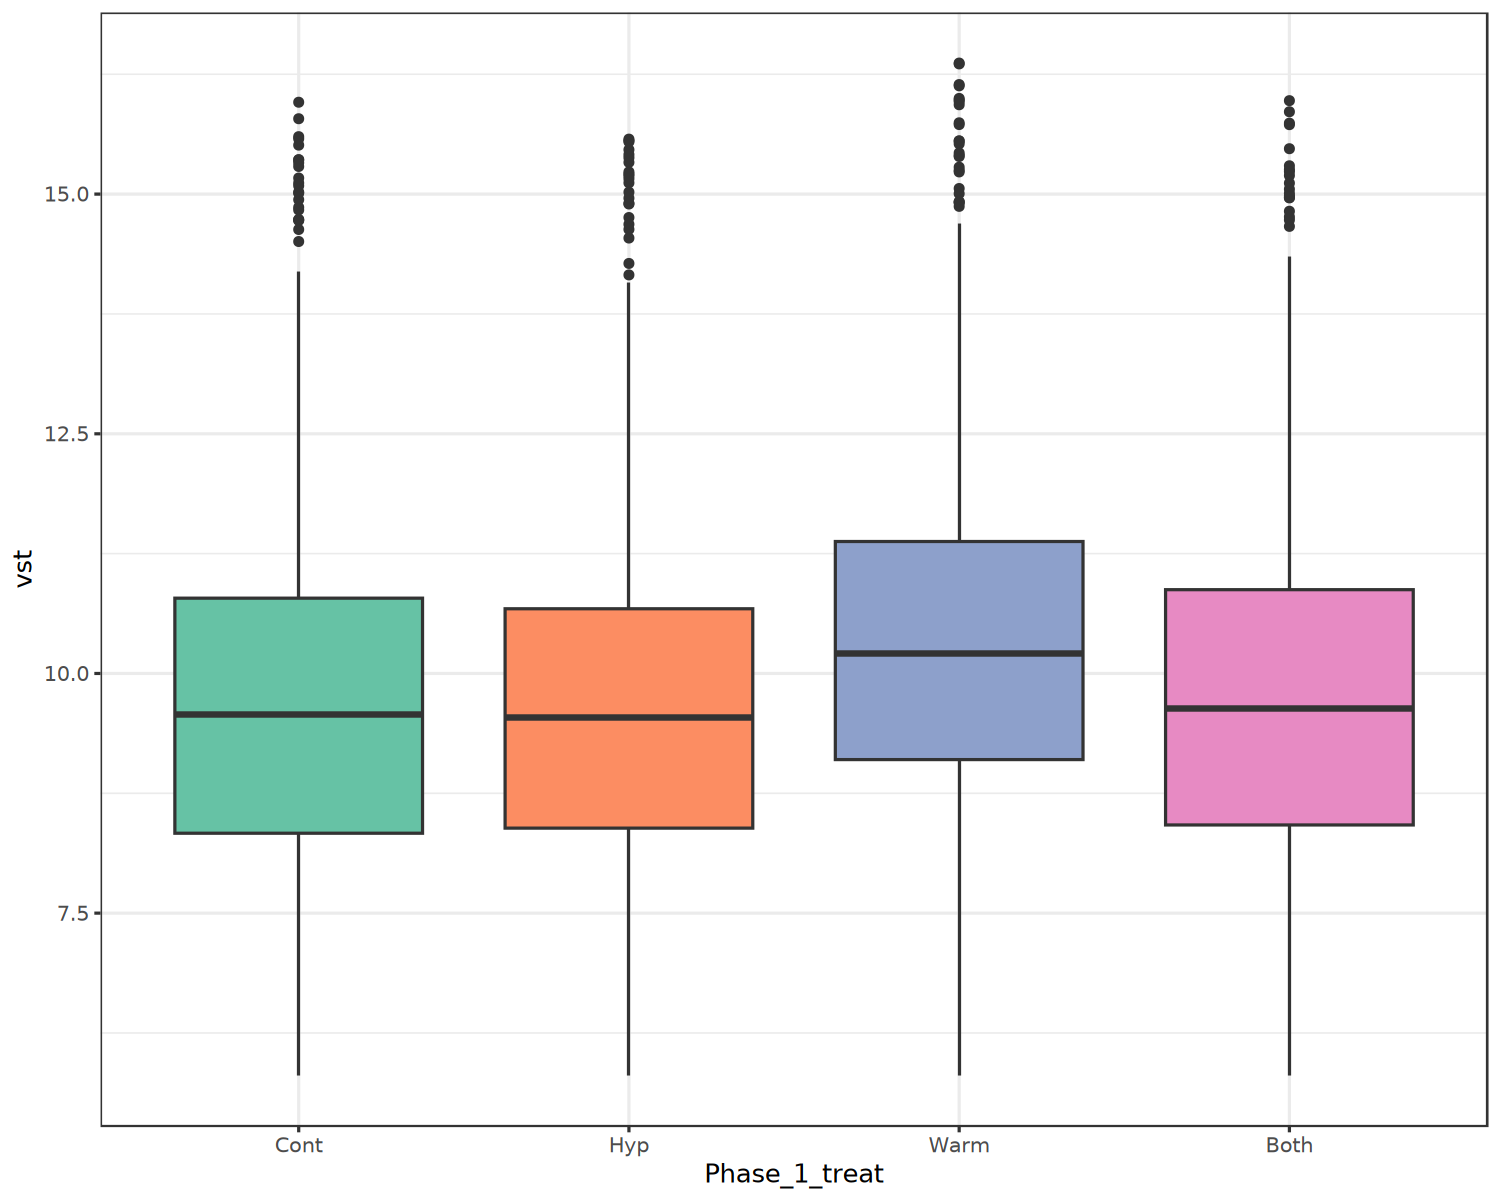

In [76]:
ggplot(warm_blue_meta, aes(x = Phase_1_treat, y = vst, fill = Phase_1_treat)) +
geom_boxplot() +
scale_fill_brewer(palette = 'Set2') +
guides(fill = 'none') +
theme_bw(base_size = 15)

when considering all of the genes associated with growth in this module, we see the average expression of these genes are higher in the warm treatment compared to the other treatments

what if i pull out the top 20 genes with the strongest correlations with the warm treatment?

In [77]:
warm_growth.top20 <- warm_blue[order(warm_blue$GS.warm, decreasing = TRUE),][1:20,]
head(warm_growth.top20)

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.warm,p.GS.GS.Actual_shell_growth_mg,p.GS.GS.warm,geneClass
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
62,LOC111127491,GO:0004044;GO:0009113,blue,0.33045568,0.6713238,0.1235440,0.0004531100,Warm
154,LOC144619780,GO:0004197;GO:0006508,blue,0.19776056,0.6586027,0.3657224,0.0006331522,Warm
120,LOC111134275,GO:0005829;GO:0006417;GO:0019887;GO:0034198,blue,0.34150020,0.6463339,0.1107528,0.0008619436,Warm
61,LOC111127452,GO:0005515,blue,0.18349605,0.6432649,0.4019794,0.0009291661,Warm
153,LOC144619626,GO:0005615;GO:0062023,blue,0.05823092,0.6336556,0.7918449,0.0011694740,Warm
27,LOC111112864,GO:0000978;GO:0001228;GO:0005634;GO:0006357,blue,0.20981756,0.6083744,0.3366083,0.0020689976,Warm


In [78]:
warm_blue_meta.top20 <- warm_blue_meta[warm_blue_meta$Gene %in% warm_growth.top20$Gene, ]

length(unique(warm_blue_meta.top20$Gene))
head(warm_blue_meta.top20)

[1] 20

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,temp_binary
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
12,B1_Nu_O03,LOC144624942,6.420371,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
15,B1_Nu_O03,LOC111118040,8.990890,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
36,B1_Nu_O03,LOC144619626,6.735227,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
66,B1_Nu_O03,LOC111135329,10.708400,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
69,B1_Nu_O03,LOC144618879,7.967676,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
74,B1_Nu_O03,LOC111120886,10.665581,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0


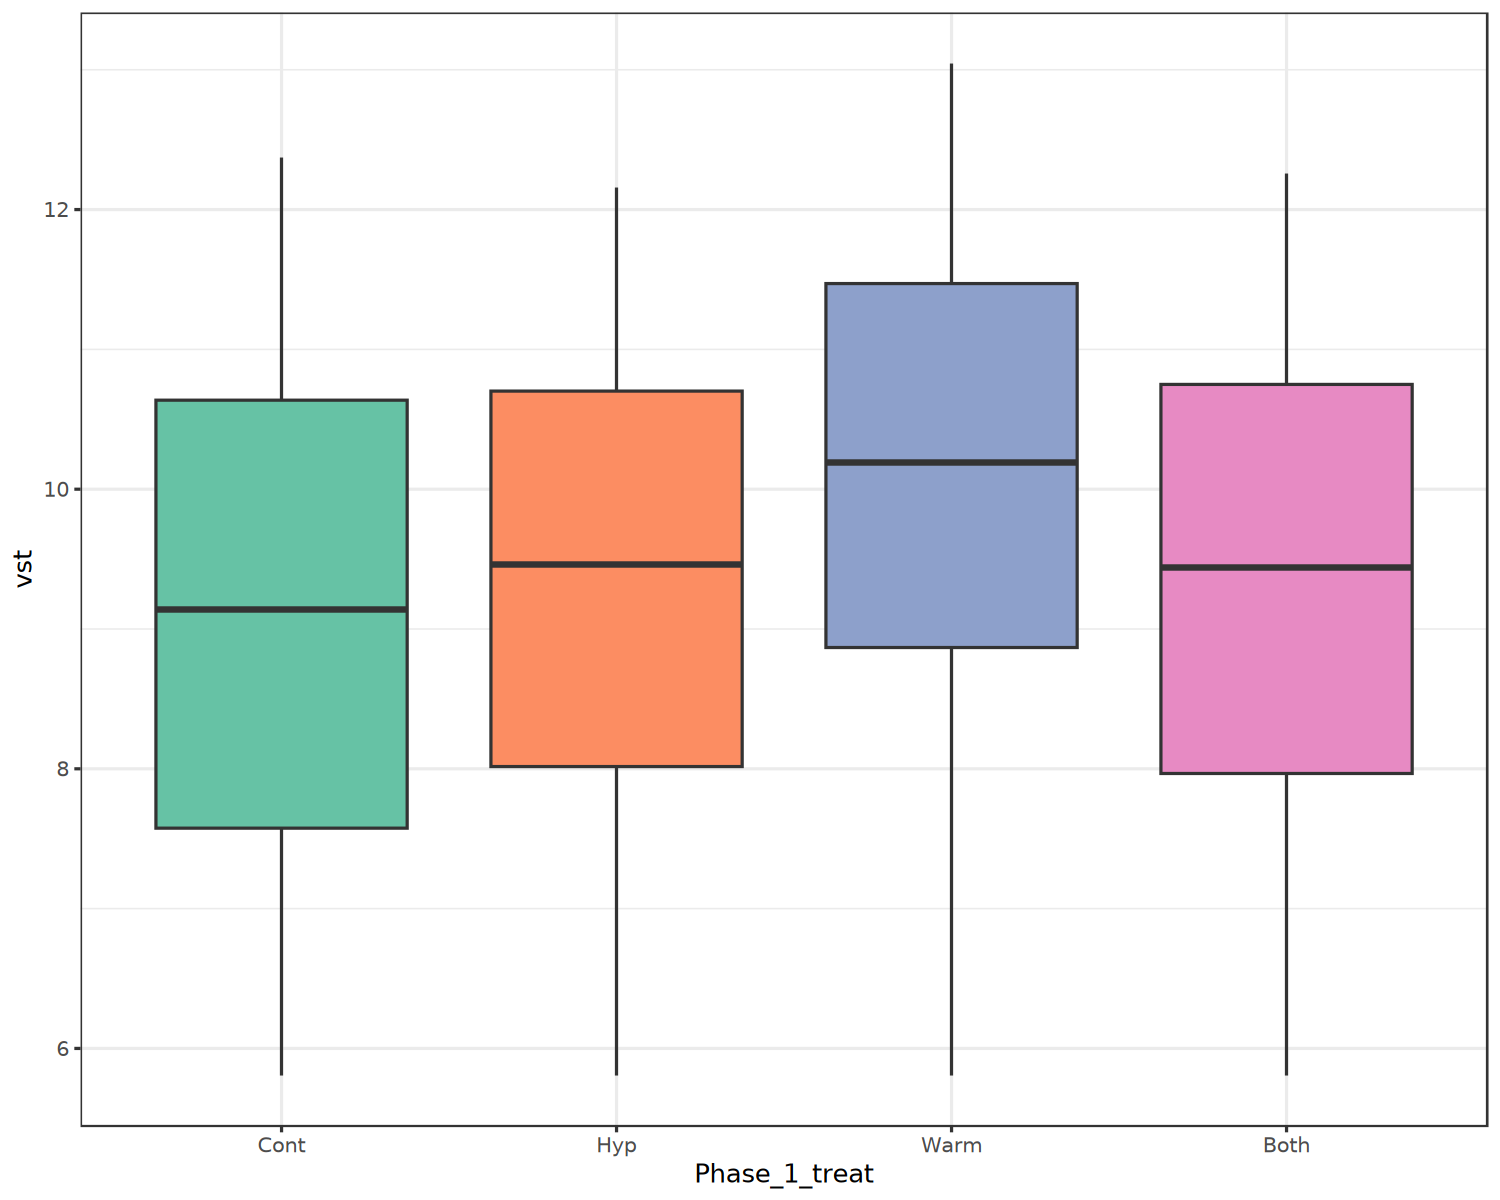

In [79]:
warm_blue_meta.top20$Phase_1_treat <- factor(warm_blue_meta.top20$Phase_1_treat, levels = c('Cont', 'Hyp', 'Warm', 'Both'))

ggplot(warm_blue_meta.top20, aes(x = Phase_1_treat, y = vst, fill = Phase_1_treat)) +
geom_boxplot() +
scale_fill_brewer(palette = 'Set2') +
guides(fill = 'none') +
theme_bw(base_size = 15)

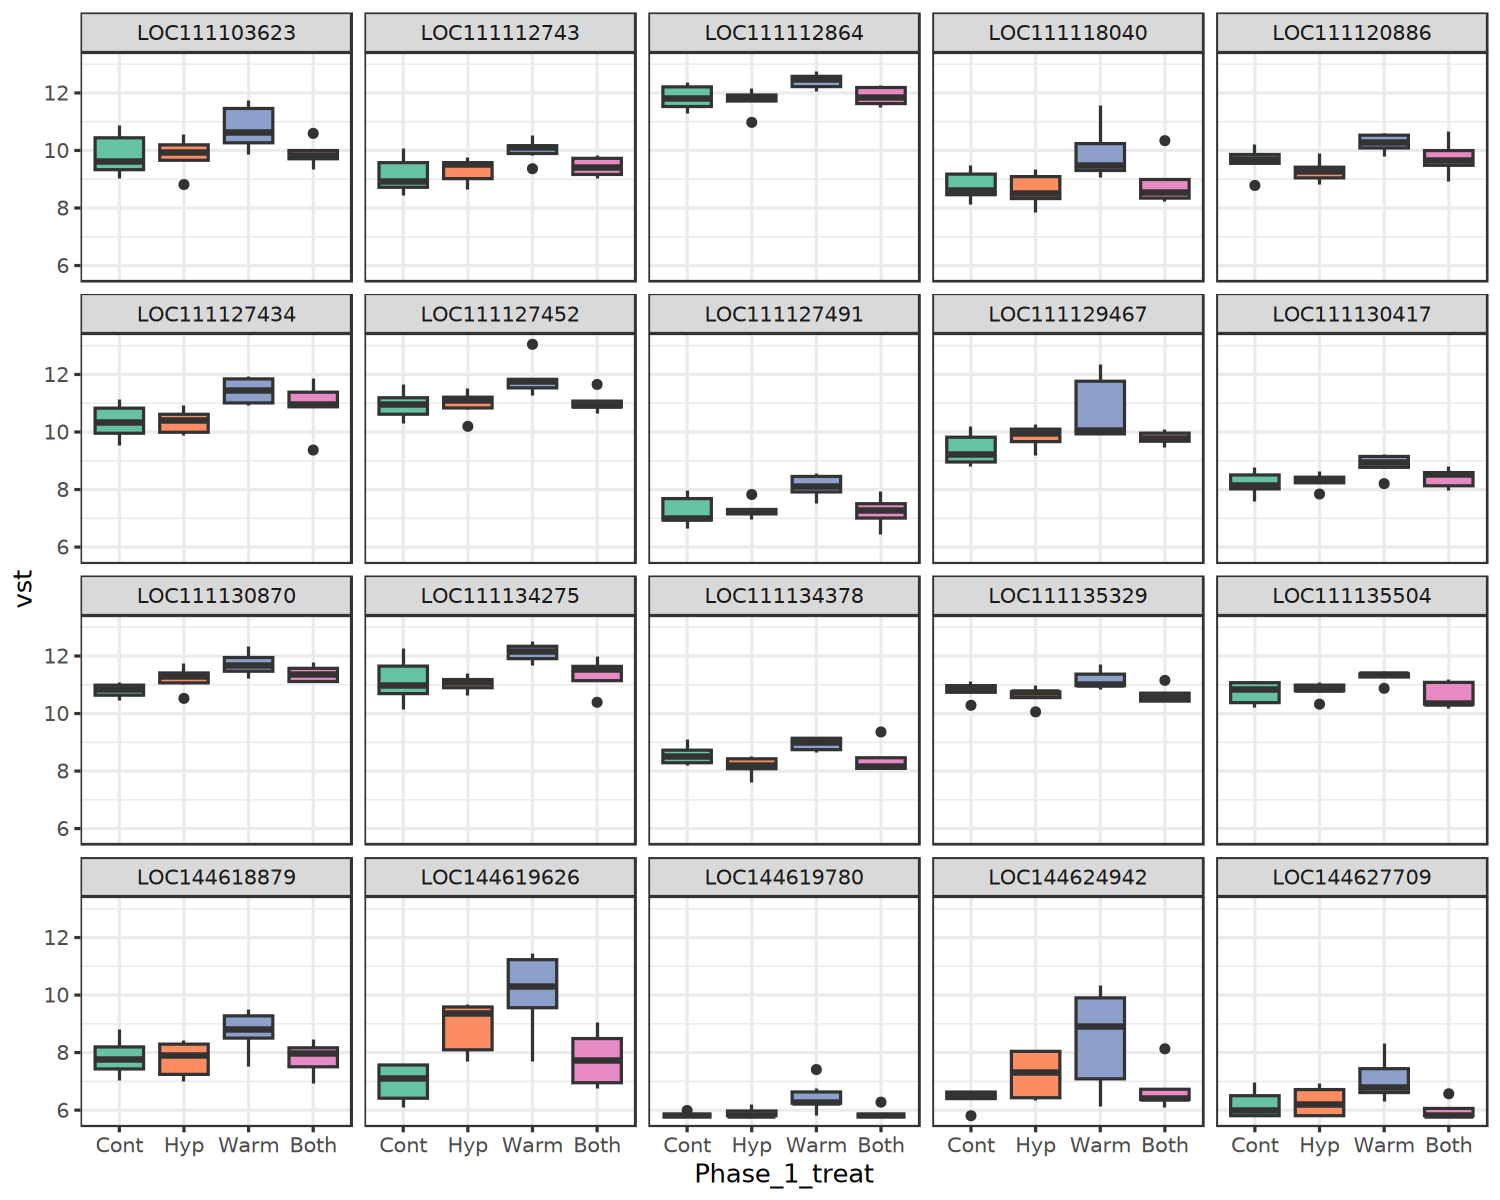

In [80]:
options(repr.plot.height = 10, repr.plot.width = 12.5)

ggplot(warm_blue_meta.top20, aes(x = Phase_1_treat, y = vst, fill = Phase_1_treat)) +
geom_boxplot() +
scale_fill_brewer(palette = 'Set2') +
guides(fill = 'none') +
facet_wrap(~Gene) +
theme_bw(base_size = 15)

so this shows the top 20 genes with the highest gene significance (GS) with pvals only significant (p < 0.05) for warm treatment only (and not shell growth)

so some of the genes look like there's small differences in relative expression across treatments, while others are more distinct

In [81]:
annot[annot$gene_id %in% warm_blue_meta.top20$Gene, ]

,gene_id,description
,<chr>,<chr>
45019,LOC144619626,microfibril-associated glycoprotein 4-like
70171,LOC144619780,caspase-7-like
124332,LOC111120886,midasin-like
139760,LOC111127434,ribonucleoside-diphosphate reductase large subunit-like
230860,LOC111127452,uncharacterized LOC111127452
235737,LOC111127491,amidophosphoribosyltransferase-like
304124,LOC111112864,uncharacterized LOC111112864
533694,LOC111135504,extracellular sulfatase Sulf-1-like
542023,LOC111103623,zygotic DNA replication licensing factor mcm6-like


looks like a lot of genes related to cell cycle (anaphase promoting complex, zygotic DNA replication licensing factor

are these top warm associated genes driven by only a few replicates, or are they consistenly highly expressed across all warm replicates?

In [82]:
# pull out only warm associated genes in the blue module VST matrix
blue_warm_VSTmatrix <- blue_vst.matrix[rownames(blue_vst.matrix) %in% warm_blue_meta$Gene,]

dim(blue_warm_VSTmatrix)
head(blue_warm_VSTmatrix)

[1] 167  23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111104691,9.318878,8.940433,9.292434,8.502152,9.204522,9.707178,8.908272,8.601408,8.693372,9.177468,⋯,9.870705,8.964422,8.672328,9.600203,9.999434,9.905553,9.578074,9.324144,9.754179,8.719894
LOC111104713,10.633193,11.368186,10.161424,9.589400,10.089565,10.329031,10.978491,9.529777,9.835468,10.527223,⋯,9.512301,10.073991,10.066095,10.868091,10.680636,9.984145,11.468343,11.348050,10.519148,10.684248
LOC144622103,10.540592,10.602921,9.567546,8.098679,10.879861,10.451098,10.220119,8.457767,9.904079,9.929211,⋯,8.771786,8.648180,9.219035,9.266630,9.098615,11.837301,12.007740,10.926881,10.948515,9.702310
LOC111103620,9.899298,9.311418,8.804755,9.187034,9.806741,9.728353,9.174238,8.826844,9.409090,9.999866,⋯,9.830771,9.306289,9.246615,9.282080,9.300643,10.180770,10.479175,9.637001,9.925052,9.395780
LOC111104256,10.152448,10.125442,9.572349,9.691068,9.873862,10.285924,9.987193,9.406217,9.638839,10.062497,⋯,10.002313,10.232147,9.517119,9.485073,9.694959,10.189634,10.602511,9.894888,10.736399,9.877259
LOC144619626,6.735227,9.049967,8.488113,7.731720,6.952011,6.642652,7.556513,6.086458,7.572736,6.337354,⋯,9.619504,7.722008,9.221565,7.685802,11.430371,10.671806,11.415842,9.913034,9.442873,7.697590


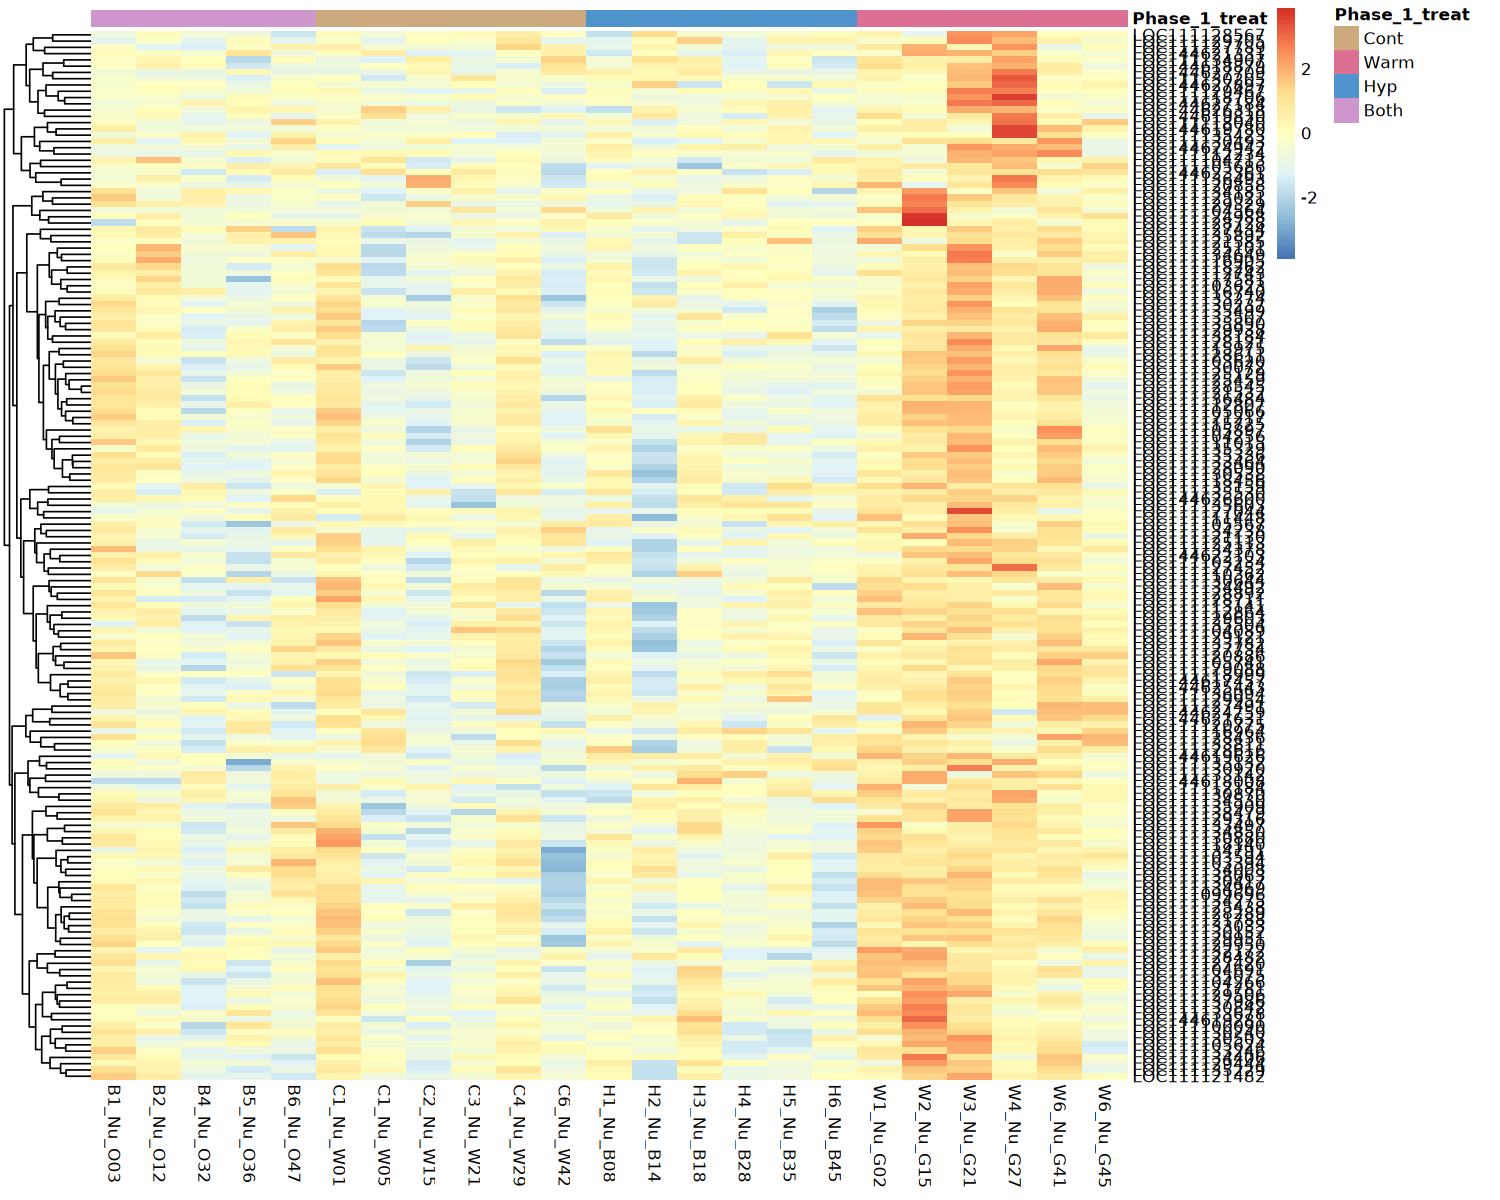

In [83]:
options(repr.plot.height = 10, repr.plot.width = 12.5)

pheatmap(blue_warm_VSTmatrix,
        cluster_cols = FALSE,
        annotation_col = annotation,
        annotation_colors = annotation_colors,
         scale = 'row' # standardizes each gene separately across samples
        ) 

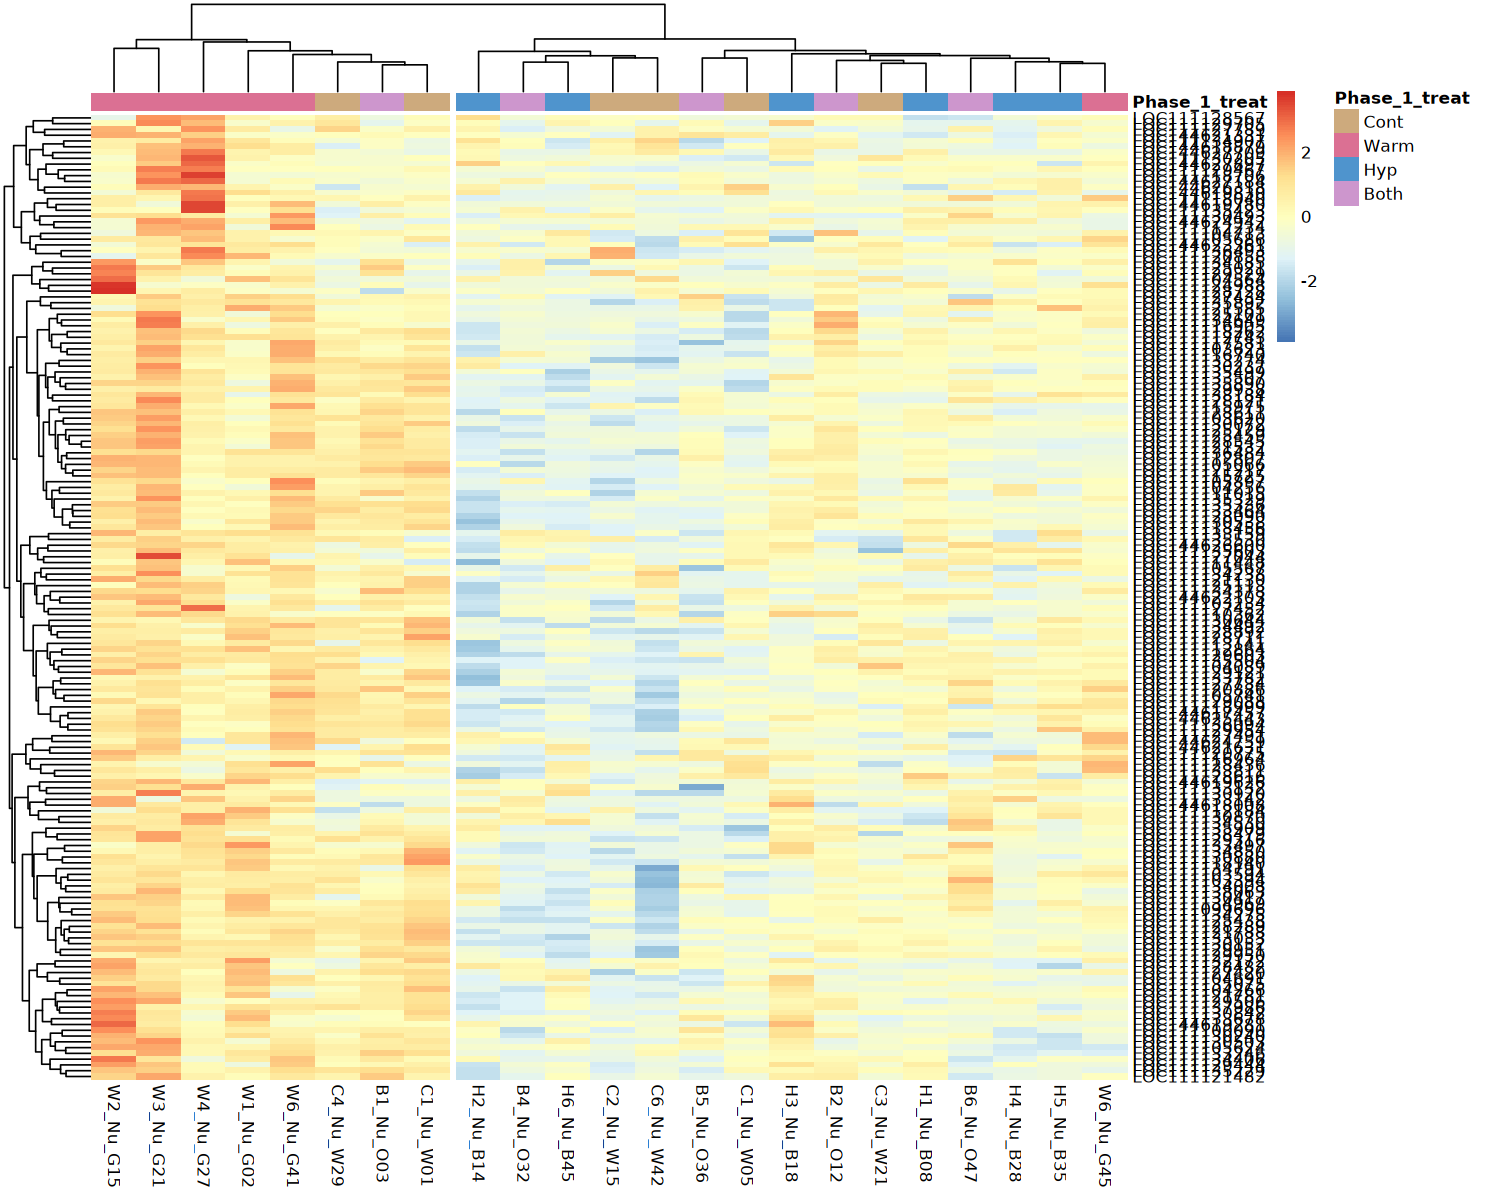

In [84]:
options(repr.plot.height = 10, repr.plot.width = 12.5)

pheatmap(blue_warm_VSTmatrix,
        #cluster_cols = FALSE,
        annotation_col = annotation,
        annotation_colors = annotation_colors,
         cutree_cols = 2,
         scale = 'row' # standardizes each gene separately across samples
        ) 

okay! so the warm associated genes are consistently highly expressed in the warm treatment oysters!!

and what's interesting is that the other replicates/treatments seem to be quite variable in their expression - so these genes are a directed response to experiencing JUST warming

it would be interested to take this gene set and look at the expression/heatmap of expression in phase 2 oysters 

#### growth AND warm associated genes

based on the plots above, pulling out the genes associated with growth and plotting the VST expression against growth/treatment

In [85]:
both_blue <- blue_gs2 %>%
filter(geneClass == 'Both')

# pull vst expr.
both_blue.vst <- vst[vst$X %in% both_blue$Gene,]

# convert vst to long format
both_blue.vst.long <- both_blue.vst %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') 

# rename gene column
colnames(both_blue.vst.long)[1] <- 'Gene'

# add growth info
both_blue_meta <- merge(both_blue.vst.long, growth, by = 'Sample')

# check
length(unique(both_blue_meta$Gene))
head(both_blue_meta)

[1] 111

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,temp_binary
,<chr>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
1,B1_Nu_O03,LOC144619411,7.72202,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
2,B1_Nu_O03,LOC111118291,10.42639,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
3,B1_Nu_O03,LOC111135316,11.01282,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
4,B1_Nu_O03,LOC111130467,8.82105,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
5,B1_Nu_O03,LOC111126731,11.48346,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0
6,B1_Nu_O03,LOC111128976,12.22103,Both,Warm,Hyp,27.9134,77.5866,0.359770888,0


In [86]:
write.csv(both_blue, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/moduleGenes/blueModGenes_shellwarmTreat.csv')

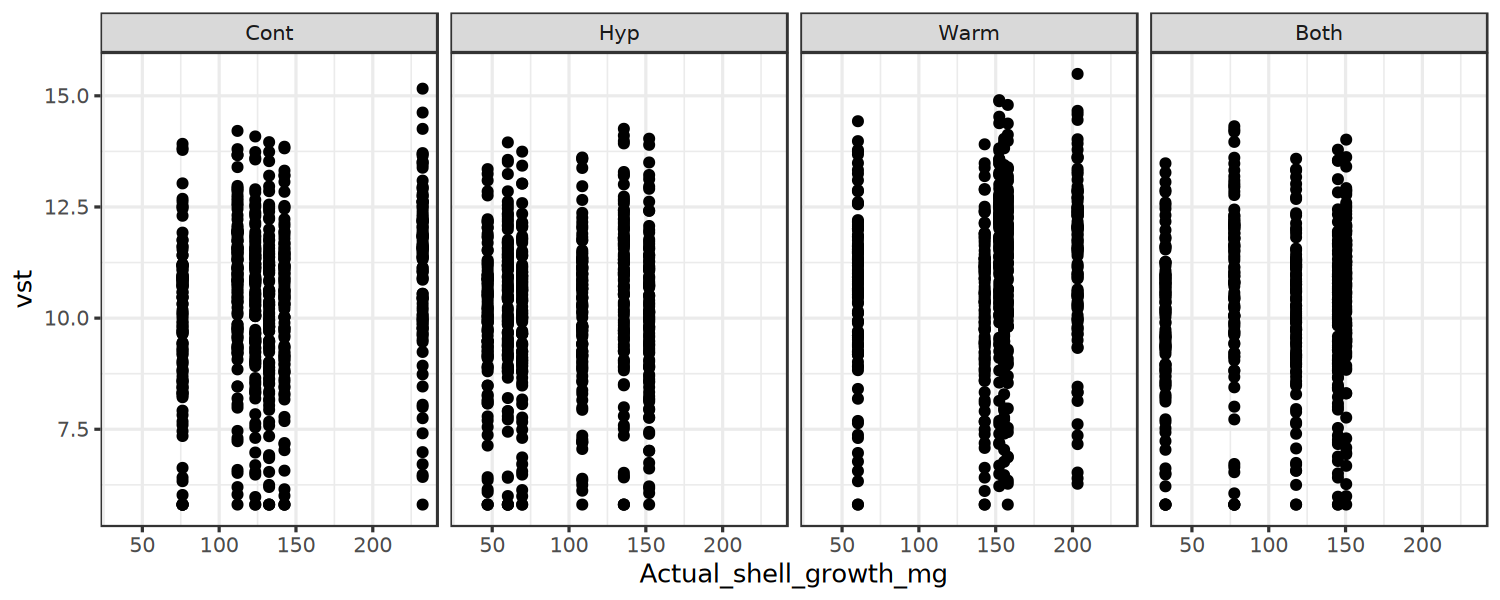

In [87]:
options(repr.plot.height = 5, repr.plot.width = 12.5)

ggplot(both_blue_meta, aes(x = Actual_shell_growth_mg, y = vst)) +
geom_point() +
facet_wrap(~Phase_1_treat, nrow = 1) +
theme_bw(base_size = 15)

hm okay so there appears to be confounding factor - looks like the warm treatment has higher growth than the other treatments

#### GO for gene subsets

**GROWTH** associated genes in the blue module

In [88]:
blue_growth.go <- enricher(gene = growth_blue$Gene,
                       universe = geneInfo$Gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

as.data.frame(blue_growth.go)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0006364,GO:0006364,rRNA processing,4/154,12/7634,6.950293e-05,0.004515453,0.003926481,LOC111099808/LOC111118739/LOC111120892/LOC111128896,4
GO:0000398,GO:0000398,"mRNA splicing, via spliceosome",5/154,23/7634,7.852962e-05,0.004515453,0.003926481,LOC111104149/LOC111118194/LOC111121238/LOC111138391/LOC144622290,5
GO:0005743,GO:0005743,mitochondrial inner membrane,5/154,32/7634,4.059488e-04,0.012006982,0.010440854,LOC111121226/LOC111128167/LOC111133136/LOC111133425/LOC111136376,5
GO:0005730,GO:0005730,nucleolus,6/154,49/7634,4.176341e-04,0.012006982,0.010440854,LOC111099808/LOC111118739/LOC111120892/LOC111134754/LOC111136414/LOC144626880,6
GO:0043022,GO:0043022,ribosome binding,3/154,10/7634,8.706041e-04,0.020023894,0.017412082,LOC111135297/LOC111136254/LOC111136376,3
GO:0000027,GO:0000027,ribosomal large subunit assembly,3/154,11/7634,1.179428e-03,0.022605711,0.019657140,LOC111118739/LOC111120892/LOC111136414,3


growth genes are enriched for rRNA processing, splicing, and ribosomal processes

**WARM TREATMENT** associated genes in the blue module

In [89]:
blue_warm.go <- enricher(gene = warm_blue$Gene,
                       universe = geneInfo$Gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

as.data.frame(blue_warm.go)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0005524,GO:0005524,ATP binding,30/167,431/7634,1.125427e-08,1.631870e-06,1.421593e-06,LOC111103394/LOC111103623/LOC111104713/LOC111105066/LOC111112807/LOC111115725/LOC111117581/LOC111118262/LOC111120886/LOC111121781/LOC111124988/LOC111125113/LOC111125129/LOC111127420/LOC111127434/LOC111128121/LOC111128711/LOC111128728/LOC111130072/LOC111130240/LOC111130417/LOC111130870/LOC111133142/LOC111133159/LOC111134530/LOC111134649/LOC111134850/LOC111135075/LOC111138063/LOC144619281,30
GO:0005730,GO:0005730,nucleolus,9/167,49/7634,8.967458e-07,6.501407e-05,5.663657e-05,LOC111103620/LOC111104266/LOC111105066/LOC111120775/LOC111121130/LOC111125438/LOC111127734/LOC111130503/LOC111135336,9
GO:0042254,GO:0042254,ribosome biogenesis,4/167,15/7634,2.497621e-04,9.372425e-03,8.164726e-03,LOC111118140/LOC111120775/LOC111121217/LOC111135336,4
GO:0005783,GO:0005783,endoplasmic reticulum,8/167,77/7634,2.585497e-04,9.372425e-03,8.164726e-03,LOC111099696/LOC111104256/LOC111121482/LOC111121532/LOC111125459/LOC111128545/LOC111130644/LOC111133811,8
GO:0006457,GO:0006457,protein folding,5/167,30/7634,4.316357e-04,1.251744e-02,1.090448e-02,LOC111121532/LOC111125459/LOC111128545/LOC111128611/LOC111130072,5
GO:0016887,GO:0016887,ATP hydrolysis activity,9/167,117/7634,1.011802e-03,2.032440e-02,1.770547e-02,LOC111103394/LOC111112807/LOC111118262/LOC111120886/LOC111127420/LOC111128121/LOC111135075/LOC111138063/LOC144619281,9
GO:0042761,GO:0042761,very long-chain fatty acid biosynthetic process,3/167,10/7634,1.101926e-03,2.032440e-02,1.770547e-02,LOC111118456/LOC111121788/LOC111134492,3
GO:0003723,GO:0003723,RNA binding,10/167,143/7634,1.121346e-03,2.032440e-02,1.770547e-02,LOC111105686/LOC111105897/LOC111118140/LOC111127420/LOC111128711/LOC111129950/LOC111130503/LOC111133159/LOC111135336/LOC144625443,10
GO:0006338,GO:0006338,chromatin remodeling,3/167,11/7634,1.490897e-03,2.402001e-02,2.092487e-02,LOC111130152/LOC111135329/LOC144617457,3


warm treatment genes are enriched for binding (RNA binding, NAD binding, DNA binding, ATP binding), ATP processes, epigenetic processes (chromatin remodeling), biogenesis (ribosome biogenesis, chain fatty acid biosynthetic process)

**BOTH GROWTH AND WARM TREATMENT** associated genes in the blue module

In [90]:
blue_both.go <- enricher(gene = both_blue_meta$Gene,
                       universe = geneInfo$Gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

as.data.frame(blue_both.go)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0003743,GO:0003743,translation initiation factor activity,8/111,14/7634,4.326523e-12,3.244893e-10,2.459287e-10,LOC111128159/LOC111099053/LOC111121263/LOC111103926/LOC111134482/LOC111119023/LOC111135733/LOC111118049,8
GO:0003723,GO:0003723,RNA binding,17/111,143/7634,1.680939e-11,6.303522e-10,4.777406e-10,LOC111120863/LOC111129496/LOC111119055/LOC111120899/LOC111123381/LOC111118963/LOC111118852/LOC111118069/LOC111134482/LOC111116966/LOC111119023/LOC111138363/LOC111136413/LOC111118049/LOC111133148/LOC111134942/LOC144625869,17
GO:0005829,GO:0005829,cytosol,15/111,200/7634,1.654537e-07,3.290940e-06,2.494186e-06,LOC111126731/LOC144626843/LOC111120899/LOC111118665/LOC111127492/LOC111121772/LOC111118247/LOC111121134/LOC111118963/LOC111106068/LOC144621008/LOC111103926/LOC111112622/LOC144618030/LOC144625422,15
GO:0003729,GO:0003729,mRNA binding,7/111,30/7634,1.755168e-07,3.290940e-06,2.494186e-06,LOC111126731/LOC111118318/LOC111134728/LOC111121303/LOC111099053/LOC111136440/LOC111128793,7
GO:0005524,GO:0005524,ATP binding,21/111,431/7634,7.704883e-07,1.155733e-05,8.759236e-06,LOC111130467/LOC111128976/LOC111120863/LOC111138440/LOC111120899/LOC111136222/LOC111118665/LOC111121772/LOC111136042/LOC111121134/LOC111118963/LOC111130020/LOC111130295/LOC111111505/LOC111135545/LOC111134482/LOC111105866/LOC111135733/LOC111110313/LOC111133148/LOC111106408,21
GO:0005739,GO:0005739,mitochondrion,13/111,177/7634,1.494348e-06,1.867935e-05,1.415698e-05,LOC111105692/LOC111114229/LOC111127947/LOC111103813/LOC111120899/LOC111138406/LOC111117758/LOC144622927/LOC111105866/LOC111135733/LOC144622705/LOC111128042/LOC111107126,13
GO:0016887,GO:0016887,ATP hydrolysis activity,8/111,117/7634,2.841306e-04,3.044256e-03,2.307226e-03,LOC111130467/LOC111138440/LOC111136222/LOC111136042/LOC111121134/LOC111130295/LOC111111505/LOC111135545,8


both growth and warm treatment genes are enriched for binding (RNA binding, mRNA binding, ATP binding) and translational processes

#### summary

There are 1149 genes in the blue module - meaning, there are 1149 genes that are co-expressed. The module eigengene (first principal component; representative gene expression) is significantly correlated with shell growth and the warm treatment (both positive). This means that increases in growth is correlated with higher expression of these genes, and the warm treatment sees higher expression of these genes compared to other treatments.

When I look at the relationship between these oysters and growth, I see that the warm treatment has decreased growth compared to control oysters, but increased compared to both oysters (and roughly the same amount of growth as hypoxic oysters)

When we break this module down further, we see:
1. the raw expression of these genes is consistently higher in the warm treatment compared to the other treatments (which tend to be more inconsistent in their expression of these genes)
2. 111 genes are correlated with **both growth and the warm treatment** (determined by the calculated Gene Significance (GS) value which correlates each gene with the trait, similar to how the WGCNA heatmaps are made but for each individual gene instead of the group. I pulled genes with a significant GS pvalue for both the warm treatment and growth)
    - with ORA, I wanted to know if this subset of genes were enriched for specific functions compared to the entire WGCNA gene set - for blue module genes specifically correlated with *both* warm treatment and growth, we see enrichment for various binding (RNA binding, mRNA binding, ATP binding), translation, and ATP hydrolysis activity.
    - could be that these genes are "compensation genes" (and compenstation only in that they allow some level of growth, despite being stressed by temperature)
3. 154 **growth associated genes** (GS pval is significant for shell growth only, not for warm treatment)
   - these genes are enriched for ribosomal processes and splicing
   - these genes contribute to increased shell growth, but not in a specific treatment (just generic growth genes?)
4. 167 **warm associated genes**
   - these genes are enriched for binding (RNA binding, NAD binding, DNA binding, ATP binding) and biogenesis
5. there are also 717 genes that are not significantly correlated with either factor - so they just belong to the module but don't have a significant relationship with either growth or warm treatment which is interesting ...
    

## 3. Plot growth
adding the shell and tissue plots from above into one plot

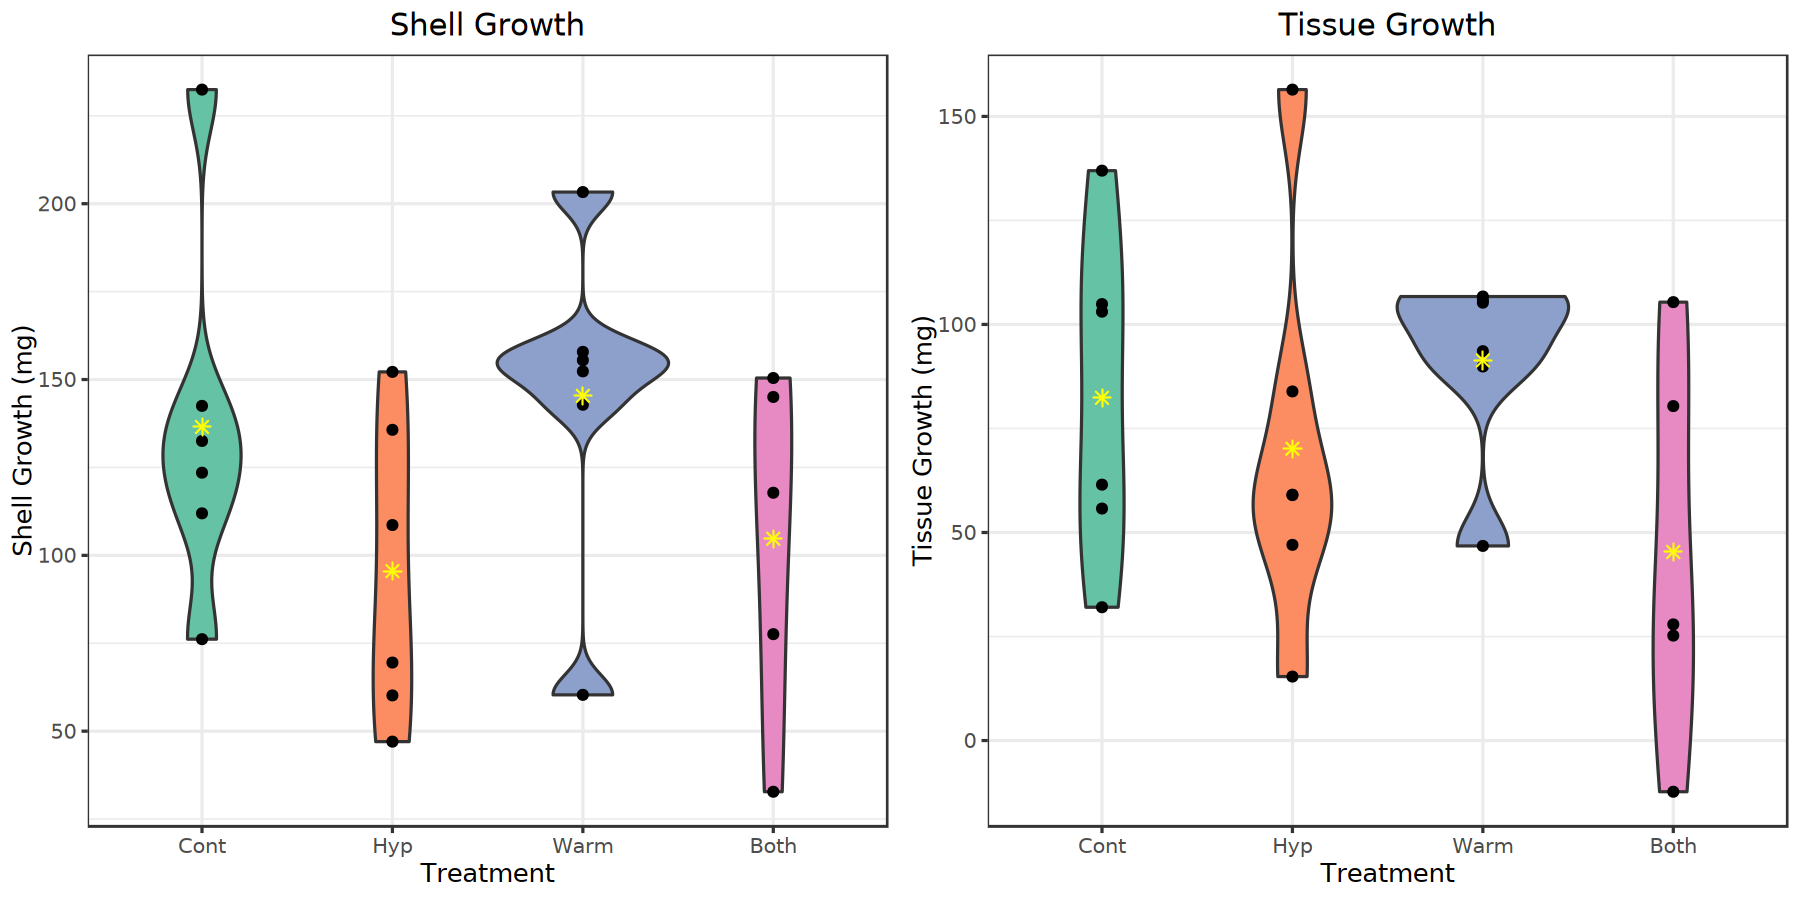

In [88]:
options(repr.plot.width = 15, repr.plot.height = 7.5)

plot_grid(shell_growth, tissue_growth)

trying to identify that one warm sample that has really low shell growth

In [91]:
growth[order(growth$Actual_shell_growth_mg, decreasing = TRUE), ] %>% filter(Phase_1_treat == 'Warm')

Sample,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg,temp_binary
<chr>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
W2_Nu_G15,Warm,Warm,Norm,89.89144,203.30856,0.442142918,1
W6_Nu_G41,Warm,Warm,Norm,105.23502,157.86498,0.66661409,1
W4_Nu_G27,Warm,Warm,Norm,106.71012,155.48988,0.686283377,1
W3_Nu_G21,Warm,Warm,Norm,93.57692,152.32308,0.614331853,1
W6_Nu_G45,Warm,Warm,Norm,105.87732,142.82268,0.741320076,1
W1_Nu_G02,Warm,Warm,Norm,46.77246,60.32754,0.77530859,1
